<a href="https://colab.research.google.com/github/kingdragonlord/PyTorch-5-in-1-Deep-Learning-NLP-Showcase/blob/main/PyTorch-5-in-1-Deep-Learning-NLP-Showcase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Decathlon: Part 1 of 2

## General Training Code (from lecture)

Below I've imported the functions for training and evaluating neural networks that we've developed in class so far. We will use them and modify them throughout the exercises below.

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def train_step(model, X_batch, y_batch, loss_fn, optimizer):
  model.train() # place model into training mode

  # forward pass
  logits = model(X_batch) # step 1: get the output predictions from the model on the current input batch
  loss = loss_fn(logits, y_batch) # step 2: calcualte the loss for the current batch

  # backward pass
  loss.backward() # Step 3: compute gradients
  optimizer.step() # Step 4: take a gradient descent step (updates all parameters of the model)
  optimizer.zero_grad() # clear gradients on each cycle so that they don't accumulate between iterations

  with torch.no_grad():
    acc = (logits.argmax(dim=-1)==y_batch).float().mean()
  return loss.item(), acc.item()

def test_step(model, X_batch, y_batch, loss_fn):
  model.eval() # place model into evaluation mode

  with torch.no_grad(): # disable gradient tracking during evalutation
    # forward pass
    logits = model(X_batch) # step 1: get the output predictions from the model on the current input batch
    loss = loss_fn(logits, y_batch) # step 2: calcualte the loss for the current batch
    acc = (logits.argmax(dim=-1)==y_batch).float().mean()
  return loss.item(), acc.item()

def train_model(model, device, loss_fn, optimizer, train_dl, val_dl, n_epochs, scheduler=None):
  model.to(device) # send model to gpu or cpu
  losses, val_losses = [], []
  accuracy, val_accuracy = [], []

  for epoch in range(n_epochs):
    epoch_loss, epoch_val_loss = 0.0, 0.0
    epoch_acc, epoch_val_acc = 0.0, 0.0

    for X_batch, y_batch in tqdm(train_dl): # iterate over all batches in the training set
      X_batch, y_batch = X_batch.to(device), y_batch.to(device) # send data batches to gpu or cpu
      loss, acc = train_step(model, X_batch, y_batch, loss_fn, optimizer)
      epoch_loss += loss
      epoch_acc += acc

    losses.append(epoch_loss/len(train_dl))
    accuracy.append(epoch_acc/len(train_dl))

    for X_batch, y_batch in tqdm(val_dl): # iterate over all batches in the test set
      X_batch, y_batch = X_batch.to(device), y_batch.to(device) # send data batches to gpu or cpu
      loss, acc = test_step(model, X_batch, y_batch, loss_fn)
      epoch_val_loss += loss
      epoch_val_acc += acc

    if scheduler is not None:
      scheduler.step()
    val_losses.append(epoch_val_loss/len(val_dl))
    val_accuracy.append(epoch_val_acc/len(val_dl))

    print(f"Epoch {epoch} | train_loss={losses[-1]} | train_acc={accuracy[-1]} | val_loss={val_losses[-1]} | val_acc={val_accuracy[-1]}")
  return losses, val_losses, accuracy, val_accuracy

def plot_loss_curves(loss, val_loss, acc, val_acc):
  def create_plot(train_data, val_data):
    plt.figure()
    plt.plot(train_data, marker='o', markeredgecolor='k', ms=3, label='train')
    plt.plot(val_data, marker='o', markeredgecolor='k', ms=3, label='val')
    plt.grid(True)
    plt.xlabel('Epoch #')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()

  create_plot(loss, val_loss)
  create_plot(acc, val_acc)

def evaluate(model, eval_dl, device, class_names=None):
  predictions = []
  groundtruth = []

  with torch.inference_mode():
    for X_batch, y_batch in tqdm(eval_dl):
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      pred_labels = model(X_batch).argmax(dim=-1)
      predictions.extend(pred_labels.float().cpu().numpy())
      groundtruth.extend(y_batch.cpu().numpy())

  print(classification_report(groundtruth, predictions))
  cm = confusion_matrix(groundtruth, predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  fig, ax = plt.subplots(figsize=(16,8))
  disp.plot(ax=ax, xticks_rotation='vertical')

# Task 1: Train a neural network on the 20 newsgroups dataset

In this task you will train a neural network on the 20 newsgroups dataset from the previous lab. To get us started, the following cell will download the dataset for select newsgroup topics:

## Download the dataset

In [ ]:
from sklearn.datasets import fetch_20newsgroups

categories = ["comp.graphics", "sci.electronics", "sci.space", 'misc.forsale', 'rec.sport.baseball']
newsgroups = fetch_20newsgroups(
    remove=("headers", "footers", "quotes"),
    subset='all',
    categories=categories,
    shuffle=True,
    random_state=42
)

documents = newsgroups.data
labels = newsgroups.target

## Sklearn transformers for data pipeline

As we saw in the previous lab, different preprocessing schemes can have an impact on overall performance of our model for a given task and dataset. We always need to think through and be selective of which preprocessing techniques we use for a given problem. Often, a problem will require custom preprocessing code depending on what you are doing. Below, some preprocessing transforms are copied over from the previous lab. Feel free to use these or create your own!

In [ ]:
import re
import string
from sklearn.base import BaseEstimator, TransformerMixin

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('stopwords')

class TextCleaner(BaseEstimator, TransformerMixin):
  def __init__(self, remove_punct=True, lowercase=True):
    self.remove_punct = remove_punct
    self.lowercase = lowercase

  def fit(self, X, y=None): # nothing to do for this case
    return self

  def transform(self, X, y=None): # apply transformations to remove punctuation and lowercase
    cleaned_text = []
    for text in X:
      if self.lowercase:
        text = text.lower()
      if self.remove_punct:
        text = text.translate(str.maketrans('', '', string.punctuation))
      cleaned_text.append(text)
    return cleaned_text

class PunctRemover(BaseEstimator, TransformerMixin):
  def __init__(self):
    pass

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    return [text.translate(str.maketrans('', '', string.punctuation)) for text in X]

class Lemmatizer(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.lemmatizer = WordNetLemmatizer()

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    lemmatized_text = []
    for text in X:
      tokens = word_tokenize(text)
      lemmatized_tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
      lemmatized_text.append(' '.join(lemmatized_tokens))
    return lemmatized_text

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Form the dataset

Use a pipeline to combine one or more preprocessing techniques with a TfidfVectorizer. Prepare your dataset for modeling by: using your pipeline to transform the raw dataset downloaded above, forming your dataset splits, and creating PyTorch dataloaders for your datasets. Try out different ngram ranges in the TfidfVectorizer (via the `ngram_range` parameter of `TfidfVectorizer`).

In [ ]:
# Custom Stopword Remover transformer
class StopwordRemover(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        processed = []
        for text in X:
            tokens = text.split()
            filtered = [token for token in tokens if token not in self.stop_words]
            processed.append(' '.join(filtered))
        return processed

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Pipeline creation function with configurable ngram_range
def preprocessing_pipeline(ngram_range=(1,1)):
    return Pipeline([
        ('cleaner', TextCleaner(remove_punct=True, lowercase=True)),
        ('lemmatizer', Lemmatizer()),
        ('stopword_remover', StopwordRemover()),
        ('tfidf', TfidfVectorizer(ngram_range=ngram_range, max_features=25000, dtype=np.float32))  # Limits maximum features & Uses 32-bit floats instead of 64-bit
    ])

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Dataset preparation and DataLoader creation
def prepare_datasets(ngram_range=(1,1), batch_size=32):
    # Split dataset
    X_train, X_temp, y_train, y_temp = train_test_split(
        documents, labels, test_size=0.3, stratify=labels, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    # Create and fit pipeline
    pipeline = preprocessing_pipeline(ngram_range)
    pipeline.fit(X_train)

    # Transform datasets
    X_train_tfidf = pipeline.transform(X_train)
    X_val_tfidf = pipeline.transform(X_val)
    X_test_tfidf = pipeline.transform(X_test)

    # Convert to tensors and create DataLoaders
    train_dataset = TensorDataset(
        torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val_tfidf.toarray(), dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )

    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size),
        DataLoader(test_dataset, batch_size=batch_size),
        pipeline
    )

Describe your preprocessing and vectorization approach in the cell provided below. How does the number of features from the vectorization step impact neural network training?


**Text Cleaning**: Remove punctuation, convert text to lowercase
**Lemmatization**: Reduce words to their base/dictionary form
**Stopword Removal**: Remove common non-informative words
**TF-IDF Vectorization**: Convert text to numerical features using Term Frequency-Inverse Document Frequency. Configurable ngram_range parameter creates combinations of word sequences


---

More features means larger weight matrices in neural networks
Increasing memory usage and training time
Batch processing becomes more resource-intensive


## Modeling

Create and train a neural network to predict newsgroup topics given a vectorized document. As a goal, aim for somewhere around 90% accuracy (or more 😃).

In [ ]:
## Define the model
class TextClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# Train the model
def run_training(ngram_range=(1,2)):
    # Prepare data
    train_dl, val_dl, test_dl, pipeline = prepare_datasets(ngram_range)

    # Initialize model
    model = TextClassifier(
        input_size=len(pipeline.named_steps['tfidf'].get_feature_names_out()),
        num_classes=len(categories)

    )

    # Training configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Execute training
    losses, val_losses, accuracy, val_accuracy = train_model(
        model, device, loss_fn, optimizer,
        train_dl, val_dl, n_epochs=20
    )

    # Generate evaluation metrics
    plot_loss_curves(losses, val_losses, accuracy, val_accuracy)
    evaluate(model, test_dl, device, class_names=categories)

    return model, (losses, val_losses, accuracy, val_accuracy)


Training with ngram_range=(1, 1)


100%|██████████| 24/24 [00:00<00:00, 412.38it/s]


Epoch 0 | train_loss=1.3163099311016224 | train_acc=0.5476658956872092 | val_loss=0.6441609362761179 | val_acc=0.81640625


100%|██████████| 24/24 [00:00<00:00, 391.07it/s]


Epoch 1 | train_loss=0.36206765941999575 | train_acc=0.900713735156589 | val_loss=0.32159900354842347 | val_acc=0.9049479166666666


100%|██████████| 24/24 [00:00<00:00, 374.14it/s]


Epoch 2 | train_loss=0.13636797588939467 | train_acc=0.9556905870084409 | val_loss=0.31283706954369944 | val_acc=0.9010416666666666


100%|██████████| 24/24 [00:00<00:00, 505.32it/s]


Epoch 3 | train_loss=0.08751365914078499 | train_acc=0.969290124045478 | val_loss=0.3161977057655652 | val_acc=0.8984375


100%|██████████| 24/24 [00:00<00:00, 123.71it/s]


Epoch 4 | train_loss=0.0662960724223888 | train_acc=0.9776813277491817 | val_loss=0.3086390309035778 | val_acc=0.90234375


100%|██████████| 24/24 [00:00<00:00, 215.14it/s]


Epoch 5 | train_loss=0.06464791775754376 | train_acc=0.975077161082515 | val_loss=0.30950973896930617 | val_acc=0.9049479166666666


100%|██████████| 24/24 [00:00<00:00, 496.58it/s]


Epoch 6 | train_loss=0.06089448670779044 | train_acc=0.9744984573788114 | val_loss=0.3199738450348377 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 397.54it/s]


Epoch 7 | train_loss=0.06036186391645094 | train_acc=0.9748263888888888 | val_loss=0.32963882728169364 | val_acc=0.8958333333333334


100%|██████████| 24/24 [00:00<00:00, 482.90it/s]


Epoch 8 | train_loss=0.05796119345608598 | train_acc=0.9756558647862187 | val_loss=0.3380817628155152 | val_acc=0.90234375


100%|██████████| 24/24 [00:00<00:00, 491.90it/s]


Epoch 9 | train_loss=0.05935111682251941 | train_acc=0.9748263888888888 | val_loss=0.32629922529061633 | val_acc=0.9049479166666666


100%|██████████| 24/24 [00:00<00:00, 491.81it/s]


Epoch 10 | train_loss=0.05705590668690598 | train_acc=0.9742091055269595 | val_loss=0.3189379231383403 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 489.06it/s]


Epoch 11 | train_loss=0.05572630050301086 | train_acc=0.9762731481481481 | val_loss=0.3255630551526944 | val_acc=0.8984375


100%|██████████| 24/24 [00:00<00:00, 490.51it/s]


Epoch 12 | train_loss=0.05591340101279827 | train_acc=0.9745370370370371 | val_loss=0.3311920544753472 | val_acc=0.90234375


100%|██████████| 24/24 [00:00<00:00, 460.60it/s]


Epoch 13 | train_loss=0.05419213097748407 | train_acc=0.9765625 | val_loss=0.33344330328206223 | val_acc=0.90234375


100%|██████████| 24/24 [00:00<00:00, 469.07it/s]


Epoch 14 | train_loss=0.055479483768943245 | train_acc=0.9768518518518519 | val_loss=0.35254594838867587 | val_acc=0.9049479166666666


100%|██████████| 24/24 [00:00<00:00, 429.13it/s]


Epoch 15 | train_loss=0.05591353230071642 | train_acc=0.9751157407407407 | val_loss=0.3362479542071621 | val_acc=0.9036458333333334


100%|██████████| 24/24 [00:00<00:00, 389.40it/s]


Epoch 16 | train_loss=0.055038326318296 | train_acc=0.9768518518518519 | val_loss=0.3314059424834947 | val_acc=0.8984375


100%|██████████| 24/24 [00:00<00:00, 400.43it/s]


Epoch 17 | train_loss=0.053636080697927996 | train_acc=0.9768518518518519 | val_loss=0.32770764641463757 | val_acc=0.8997395833333334


100%|██████████| 24/24 [00:00<00:00, 378.36it/s]


Epoch 18 | train_loss=0.05444896195560297 | train_acc=0.9747878092306631 | val_loss=0.33060359007989365 | val_acc=0.9010416666666666


100%|██████████| 24/24 [00:00<00:00, 503.68it/s]


Epoch 19 | train_loss=0.053809017605898485 | train_acc=0.9744984573788114 | val_loss=0.33474951159829897 | val_acc=0.9075520833333334


100%|██████████| 24/24 [00:00<00:00, 508.53it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.90      0.88      0.89       147
           2       0.88      0.96      0.92       149
           3       0.84      0.86      0.85       147
           4       0.91      0.86      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training with ngram_range=(1, 2)


100%|██████████| 24/24 [00:00<00:00, 430.70it/s]


Epoch 0 | train_loss=1.2789631993682296 | train_acc=0.6061149697612833 | val_loss=0.571485256155332 | val_acc=0.8684895833333334


100%|██████████| 24/24 [00:00<00:00, 495.75it/s]


Epoch 1 | train_loss=0.3203705623745918 | train_acc=0.9059220684899224 | val_loss=0.33598483229676884 | val_acc=0.8997395833333334


100%|██████████| 24/24 [00:00<00:00, 489.42it/s]


Epoch 2 | train_loss=0.13025028208546616 | train_acc=0.9571373462677002 | val_loss=0.30774257456262905 | val_acc=0.8984375


100%|██████████| 24/24 [00:00<00:00, 507.96it/s]


Epoch 3 | train_loss=0.0827347077450853 | train_acc=0.969290124045478 | val_loss=0.31162991809348267 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 440.59it/s]


Epoch 4 | train_loss=0.06979719870745342 | train_acc=0.9733410499714039 | val_loss=0.31464218844970065 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 493.39it/s]


Epoch 5 | train_loss=0.06343595787378338 | train_acc=0.9736689814814815 | val_loss=0.3278556913137436 | val_acc=0.8919270833333334


100%|██████████| 24/24 [00:00<00:00, 491.19it/s]


Epoch 6 | train_loss=0.06461781119664751 | train_acc=0.9716435185185185 | val_loss=0.32810838730074465 | val_acc=0.8893229166666666


100%|██████████| 24/24 [00:00<00:00, 491.89it/s]


Epoch 7 | train_loss=0.06111820026395704 | train_acc=0.9739583333333334 | val_loss=0.3221843889914453 | val_acc=0.8919270833333334


100%|██████████| 24/24 [00:00<00:00, 491.80it/s]


Epoch 8 | train_loss=0.057029357146583845 | train_acc=0.9777199074074074 | val_loss=0.3355806640659769 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 431.28it/s]


Epoch 9 | train_loss=0.05931566404318868 | train_acc=0.9754050925925926 | val_loss=0.3244584300555289 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 459.47it/s]


Epoch 10 | train_loss=0.059101399025638345 | train_acc=0.9759837962962963 | val_loss=0.34618413153414923 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 497.46it/s]


Epoch 11 | train_loss=0.057330903171128336 | train_acc=0.9756944444444444 | val_loss=0.33846207428723574 | val_acc=0.8958333333333334


100%|██████████| 24/24 [00:00<00:00, 502.15it/s]


Epoch 12 | train_loss=0.05940436330247731 | train_acc=0.9730902777777778 | val_loss=0.34286784070233506 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 507.47it/s]


Epoch 13 | train_loss=0.05466755218340377 | train_acc=0.9754050925925926 | val_loss=0.3426687898269544 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 428.33it/s]


Epoch 14 | train_loss=0.05485890817511029 | train_acc=0.9733796296296297 | val_loss=0.34445598705982167 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 491.36it/s]


Epoch 15 | train_loss=0.056503456566537755 | train_acc=0.9730902777777778 | val_loss=0.34503671402732533 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 476.65it/s]


Epoch 16 | train_loss=0.05906726964517643 | train_acc=0.9736304018232558 | val_loss=0.3459239521374305 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 366.34it/s]


Epoch 17 | train_loss=0.05403119015843711 | train_acc=0.9736689814814815 | val_loss=0.34836316884805757 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 437.62it/s]


Epoch 18 | train_loss=0.05510144210522951 | train_acc=0.9754050925925926 | val_loss=0.3454448796498279 | val_acc=0.8958333333333334


100%|██████████| 24/24 [00:00<00:00, 381.83it/s]


Epoch 19 | train_loss=0.05521417298923889 | train_acc=0.9759837962962963 | val_loss=0.35302575568978983 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 445.83it/s]


              precision    recall  f1-score   support

           0       0.86      0.90      0.88       146
           1       0.91      0.88      0.89       147
           2       0.95      0.89      0.92       149
           3       0.84      0.83      0.84       147
           4       0.82      0.89      0.85       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training with ngram_range=(1, 3)


100%|██████████| 24/24 [00:00<00:00, 379.73it/s]


Epoch 0 | train_loss=1.2554857813649707 | train_acc=0.5985918216131352 | val_loss=0.5780912687381109 | val_acc=0.8138020833333334


100%|██████████| 24/24 [00:00<00:00, 495.52it/s]


Epoch 1 | train_loss=0.3229106047225219 | train_acc=0.9026620376993109 | val_loss=0.3272706177085638 | val_acc=0.90234375


100%|██████████| 24/24 [00:00<00:00, 508.72it/s]


Epoch 2 | train_loss=0.13327921018073405 | train_acc=0.9536265438353574 | val_loss=0.32156001683324575 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 482.01it/s]


Epoch 3 | train_loss=0.087465585052053 | train_acc=0.9716435185185185 | val_loss=0.3113917978480458 | val_acc=0.8880208333333334


100%|██████████| 24/24 [00:00<00:00, 490.64it/s]


Epoch 4 | train_loss=0.07179585108274801 | train_acc=0.973051698119552 | val_loss=0.3470125210781892 | val_acc=0.890625


100%|██████████| 24/24 [00:00<00:00, 485.43it/s]


Epoch 5 | train_loss=0.06687671664878037 | train_acc=0.9730902777777778 | val_loss=0.32064042892307043 | val_acc=0.8919270833333334


100%|██████████| 24/24 [00:00<00:00, 476.68it/s]


Epoch 6 | train_loss=0.06197140660326652 | train_acc=0.9736689814814815 | val_loss=0.32841202802956104 | val_acc=0.890625


100%|██████████| 24/24 [00:00<00:00, 499.34it/s]


Epoch 7 | train_loss=0.06044627590260158 | train_acc=0.9719328703703703 | val_loss=0.33755517409493524 | val_acc=0.8919270833333334


100%|██████████| 24/24 [00:00<00:00, 472.53it/s]


Epoch 8 | train_loss=0.06124752856838448 | train_acc=0.9742476851851852 | val_loss=0.33502106834203005 | val_acc=0.890625


100%|██████████| 24/24 [00:00<00:00, 479.12it/s]


Epoch 9 | train_loss=0.058937282749900115 | train_acc=0.9751157407407407 | val_loss=0.3392124488018453 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 494.95it/s]


Epoch 10 | train_loss=0.06394584109323288 | train_acc=0.9741705253168389 | val_loss=0.3461580453440547 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 502.00it/s]


Epoch 11 | train_loss=0.05682578750053869 | train_acc=0.9754050925925926 | val_loss=0.3389496755165358 | val_acc=0.8971354166666666


100%|██████████| 24/24 [00:00<00:00, 500.33it/s]


Epoch 12 | train_loss=0.05525375178371582 | train_acc=0.975077161082515 | val_loss=0.34213799067462486 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 489.89it/s]


Epoch 13 | train_loss=0.05806004958773243 | train_acc=0.9745370370370371 | val_loss=0.3566235474621256 | val_acc=0.890625


100%|██████████| 24/24 [00:00<00:00, 516.64it/s]


Epoch 14 | train_loss=0.05516084415716317 | train_acc=0.9748263888888888 | val_loss=0.35158908646553755 | val_acc=0.890625


100%|██████████| 24/24 [00:00<00:00, 487.16it/s]


Epoch 15 | train_loss=0.05590576679969672 | train_acc=0.9759837962962963 | val_loss=0.3532483951809506 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 501.45it/s]


Epoch 16 | train_loss=0.05828484382800525 | train_acc=0.9725115740740741 | val_loss=0.3488234885347386 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 395.30it/s]


Epoch 17 | train_loss=0.05471993160123626 | train_acc=0.9759837962962963 | val_loss=0.36072649868826073 | val_acc=0.89453125


100%|██████████| 24/24 [00:00<00:00, 361.45it/s]


Epoch 18 | train_loss=0.05484700291627734 | train_acc=0.973051698119552 | val_loss=0.36031421460211277 | val_acc=0.8932291666666666


100%|██████████| 24/24 [00:00<00:00, 440.64it/s]


Epoch 19 | train_loss=0.05605005858146965 | train_acc=0.9754050925925926 | val_loss=0.3598284552184244 | val_acc=0.8958333333333334


100%|██████████| 24/24 [00:00<00:00, 422.05it/s]


              precision    recall  f1-score   support

           0       0.87      0.86      0.87       146
           1       0.93      0.88      0.90       147
           2       0.87      0.94      0.90       149
           3       0.78      0.84      0.81       147
           4       0.90      0.82      0.86       148

    accuracy                           0.87       737
   macro avg       0.87      0.87      0.87       737
weighted avg       0.87      0.87      0.87       737



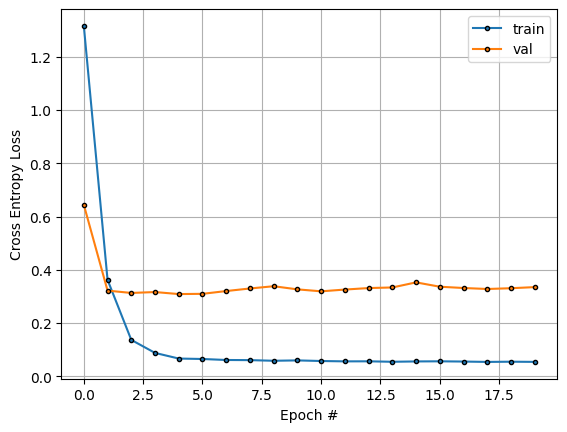

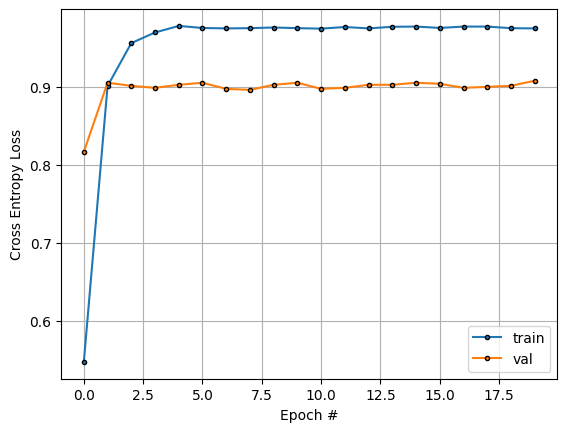

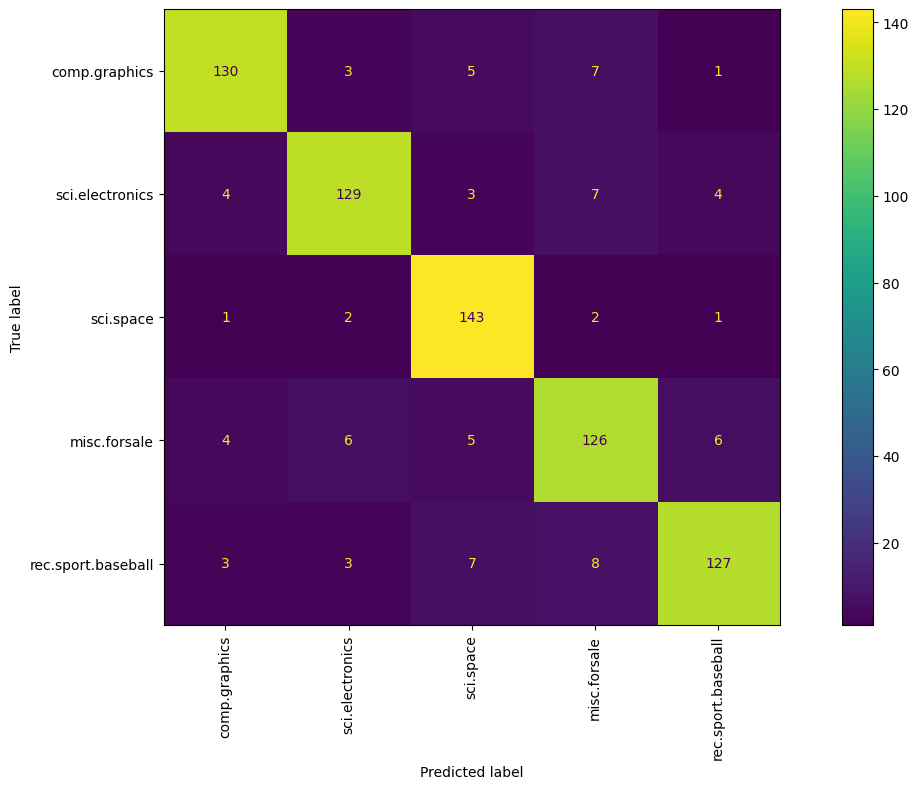

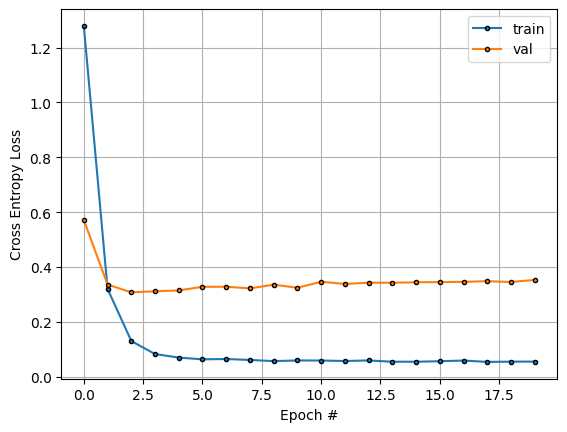

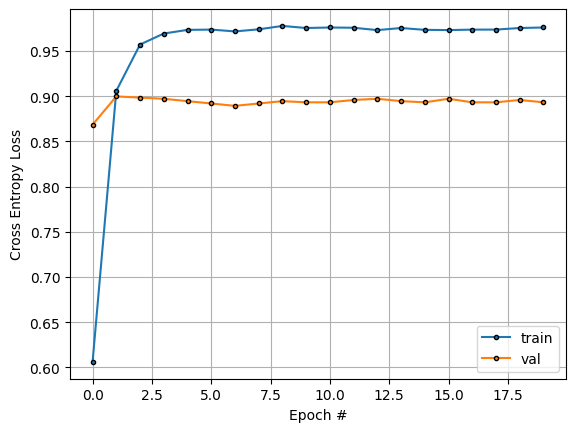

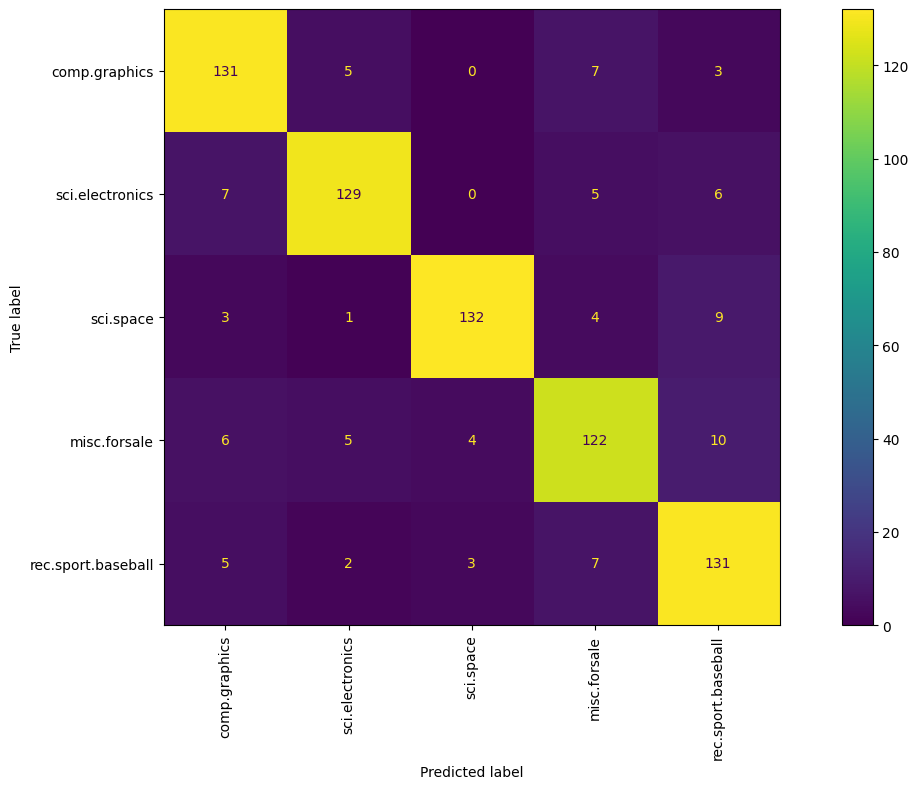

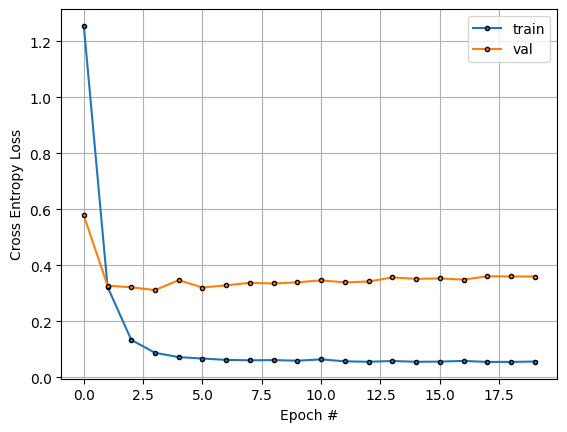

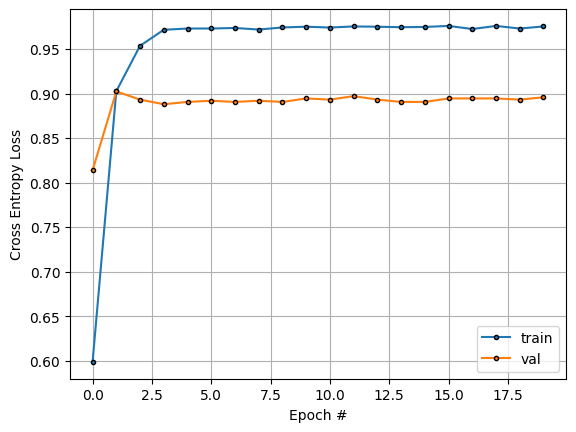

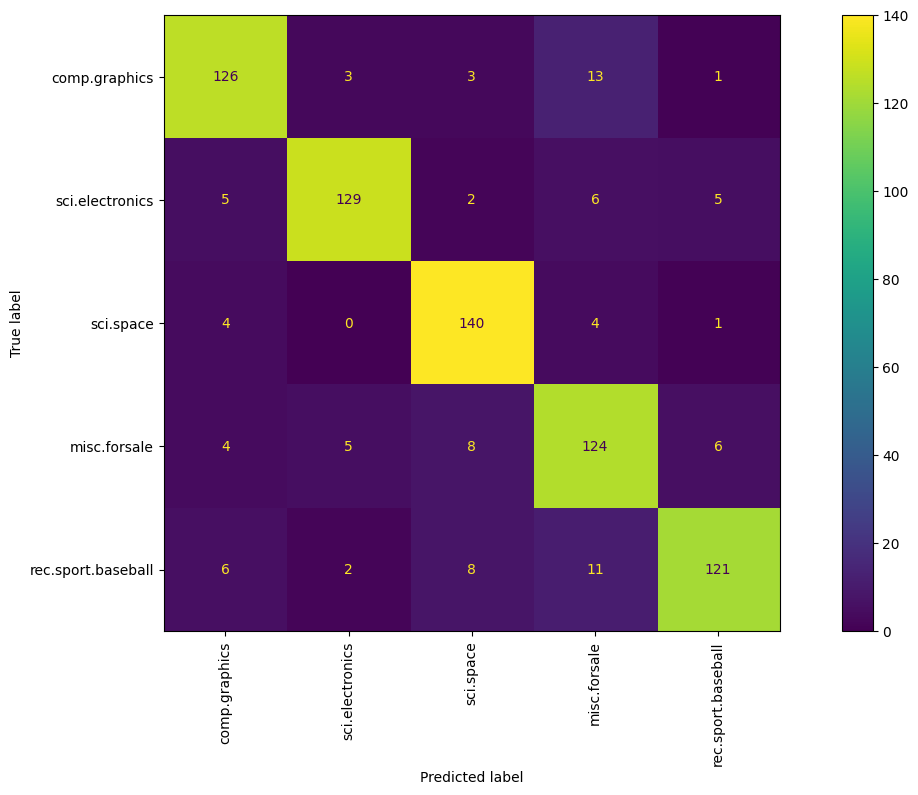

In [ ]:
# run the training
if __name__ == "__main__":
    # Store results in a dictionary
    results = {}

    # Test different ngram ranges
    for ngram_range in [(1,1), (1,2), (1,3)]:
        print(f"\n{'='*40}\nTraining with ngram_range={ngram_range}\n{'='*40}")
        model, metrics = run_training(ngram_range=ngram_range)
        results[ngram_range] = {
            'model': model,
            'metrics': metrics,
            'train_loss': metrics[0],
            'val_loss': metrics[1],
            'train_acc': metrics[2],
            'val_acc': metrics[3]
        }

**Hyper Parameter Optimization**

In [ ]:
# Modified TextClassifier with configurable hyperparameters
class TunedTextClassifier(nn.Module):
    def __init__(self, input_size, num_classes,
                 hidden_dims=[512, 256],
                 dropout_rates=[0.6, 0.4],
                 use_batchnorm=True):
        super().__init__()
        layers = []
        for i, (dim, dropout) in enumerate(zip(hidden_dims, dropout_rates)):
            layers.append(nn.Linear(
                input_size if i==0 else hidden_dims[i-1],
                dim
            ))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dims[-1], num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

In [ ]:
import torch.nn.functional as F

def run_hyperparameter_optimization():
    best_accuracy = 0
    best_params = {}
    results = []

    # Hyperparameter grid
    param_grid = {
        'lr': [0.0001, 0.0005, 0.001],
        'batch_size': [32, 64, 128],
        'hidden_dims': [[512], [512, 256], [1024, 512]],
        'dropout_rates': [[0.5], [0.6, 0.4]],
        'weight_decay': [0.0, 0.0001, 0.001]
    }

    # Generate all combinations
    from itertools import product
    keys, values = zip(*param_grid.items())
    for i, combination in enumerate(product(*values)):
        params = dict(zip(keys, combination))

        print(f"\n{'='*40}")
        print(f"Training combination {i+1}/{len(list(product(*values)))}")
        print(params)

        # Train with current params
        model, history = run_training(
            lr=params['lr'],
            batch_size=params['batch_size'],
            hidden_dims=params['hidden_dims'],
            dropout_rates=params['dropout_rates'],
            weight_decay=params['weight_decay']
        )

        # Track best performance
        current_acc = max(history['val_acc'])
        results.append((params, current_acc))

        if current_acc > best_accuracy:
            best_accuracy = current_acc
            best_params = params
            print(f"New best accuracy: {best_accuracy:.2%}")

    # Save results
    results_df = pd.DataFrame([
        (str(p), acc) for p, acc in results
    ], columns=['params', 'val_accuracy'])

    return best_params, results_df

def run_training(
    ngram_range=(1,1),
    model_class=TextClassifier,
    hidden_dims=[512, 256],
    dropout_rates=[0.6, 0.4],
    lr=0.001,
    weight_decay=0.0001,
    use_batchnorm=False,
    max_epochs=4,
    patience=10,
    batch_size=64
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Prepare datasets
    train_dl, val_dl, test_dl, pipeline = prepare_datasets(
        ngram_range, batch_size
    )

    # Initialize model differently based on class
    if model_class == TextClassifier:
        model_instance = model_class(
            input_size=len(pipeline.named_steps['tfidf'].get_feature_names_out()),
            num_classes=len(categories),
        )
    elif model_class == TunedTextClassifier:
        model_instance = model_class(
            input_size=len(pipeline.named_steps['tfidf'].get_feature_names_out()),
            num_classes=len(categories),
            hidden_dims=hidden_dims,
            dropout_rates=dropout_rates,
            use_batchnorm=use_batchnorm,
        )
    else:
        raise ValueError(f"Unknown model class: {model_class}")


    model_instance = model_instance.to(device)  # Move model to device after initialization

    # Calculate class weights
    class_counts = np.bincount(train_dl.dataset.tensors[1].numpy())
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(device)

    # Configure optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model_instance.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        patience=5,
        factor=0.5,
    )

    # Training loop with early stopping
    best_val_acc = 0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(max_epochs):
        # Training phase
        model_instance.train()
        epoch_train_loss, epoch_train_acc = 0.0, 0.0

        for X_batch, y_batch in tqdm(train_dl, desc=f"Epoch {epoch+1}/{max_epochs} - Train"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            logits = model_instance(X_batch)
            loss = F.cross_entropy(logits, y_batch, weight=class_weights)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_instance.parameters(), 5.0)
            optimizer.step()

            # Metrics
            acc = (logits.argmax(dim=-1) == y_batch).float().mean()
            epoch_train_loss += loss.item()
            epoch_train_acc += acc.item()

        # Validation phase
        model_instance.eval()
        epoch_val_loss, epoch_val_acc = 0.0, 0.0

        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_dl, desc=f"Epoch {epoch+1}/{max_epochs} - Val"):
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model_instance(X_batch)
                loss = F.cross_entropy(logits, y_batch)
                acc = (logits.argmax(dim=-1) == y_batch).float().mean()
                epoch_val_loss += loss.item()
                epoch_val_acc += acc.item()

        # Update learning rate
        scheduler.step(epoch_val_acc)

        # Store metrics
        train_loss = epoch_train_loss / len(train_dl)
        train_acc = epoch_train_acc / len(train_dl)
        val_loss = epoch_val_loss / len(val_dl)
        val_acc = epoch_val_acc / len(val_dl)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            # Save the state_dict of the current model instance
            best_model = model_instance.state_dict() # Changed this line
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            model_instance.load_state_dict(best_model)
            break

    # Final evaluation
    model_instance.eval()
    evaluate(model_instance, test_dl, device, class_names=categories)

    return model_instance, history

Training original model...


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 231.70it/s]



Epoch 1
Train Loss: 1.5185 | Train Acc: 46.16%
Val Loss: 1.1776 | Val Acc: 80.13%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 233.47it/s]



Epoch 2
Train Loss: 0.6478 | Train Acc: 87.71%
Val Loss: 0.3714 | Val Acc: 89.22%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 287.95it/s]



Epoch 3
Train Loss: 0.2029 | Train Acc: 94.03%
Val Loss: 0.3075 | Val Acc: 90.13%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 326.57it/s]



Epoch 4
Train Loss: 0.1109 | Train Acc: 96.46%
Val Loss: 0.3035 | Val Acc: 90.13%


100%|██████████| 12/12 [00:00<00:00, 319.83it/s]


              precision    recall  f1-score   support

           0       0.89      0.92      0.91       146
           1       0.90      0.90      0.90       147
           2       0.88      0.95      0.92       149
           3       0.90      0.79      0.84       147
           4       0.89      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training tuned model...


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 200.57it/s]



Epoch 1
Train Loss: 1.5740 | Train Acc: 46.67%
Val Loss: 1.4366 | Val Acc: 83.36%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 194.76it/s]



Epoch 2
Train Loss: 0.9769 | Train Acc: 83.47%
Val Loss: 0.5357 | Val Acc: 88.19%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 221.09it/s]



Epoch 3
Train Loss: 0.3331 | Train Acc: 91.77%
Val Loss: 0.3426 | Val Acc: 90.26%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 137.55it/s]



Epoch 4
Train Loss: 0.1717 | Train Acc: 94.87%
Val Loss: 0.3128 | Val Acc: 90.65%


100%|██████████| 12/12 [00:00<00:00, 195.99it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.88      0.90       147
           2       0.88      0.93      0.91       149
           3       0.84      0.84      0.84       147
           4       0.89      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737



100%|██████████| 12/12 [00:00<00:00, 196.22it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.88      0.90       147
           2       0.88      0.93      0.91       149
           3       0.84      0.84      0.84       147
           4       0.89      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737



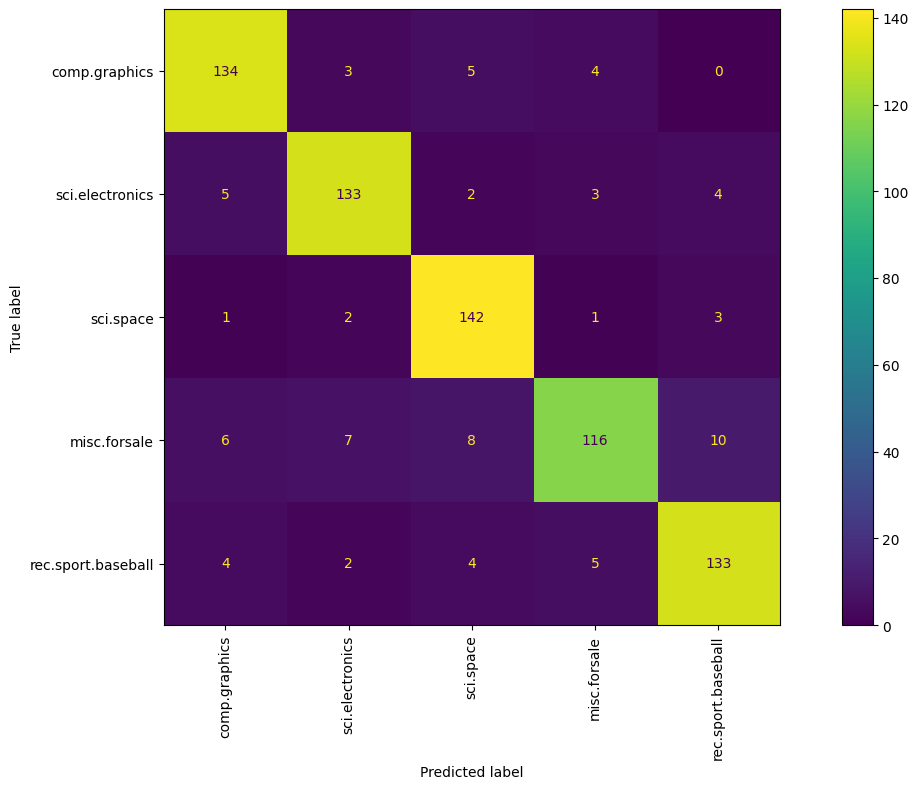

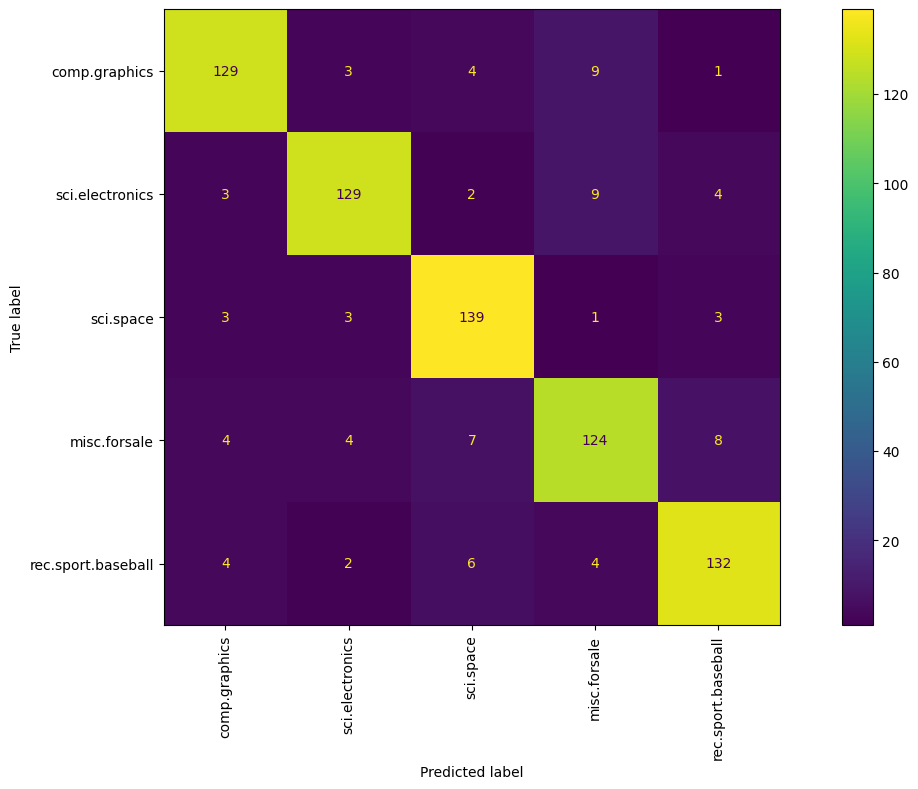

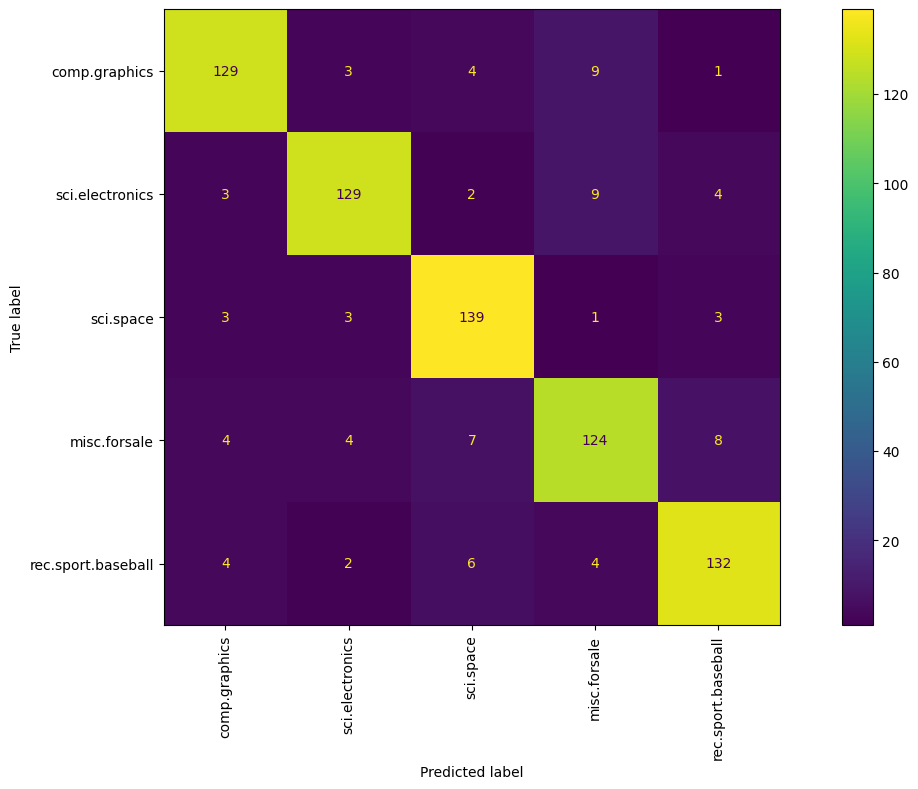

In [ ]:
if __name__ == "__main__":
    # Train original model (unchanged)
    print("Training original model...")
    original_model, original_history = run_training(model_class=TextClassifier)

    # Train tuned model with hyperparameters
    print("\nTraining tuned model...")
    tuned_model, tuned_history = run_training(
        model_class=TunedTextClassifier,
        hidden_dims=[512, 256],
        dropout_rates=[0.6, 0.4],
        lr=0.0005,
        weight_decay=0.001
    )

        # Get the test_dl from the latest call to run_training
    train_dl, val_dl, test_dl, pipeline = prepare_datasets(ngram_range=(1,1), batch_size=64)

    # Evaluate the tuned model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Define device here
    evaluate(tuned_model, test_dl, device, class_names=categories)

    # Get losses and accuracies for plotting from the tuned model's history
    losses, val_losses, acc, val_acc = tuned_history['train_loss'], tuned_history['val_loss'], tuned_history['train_acc'], tuned_history['val_acc']

Describe your modeling approach in detail. What are the hyperparameters of your model? What are the hyperparameters of the training process? How does preprocessing and vectorization process effect your results?

Theses are the hyper parameters I choose to work with.
'lr': [0.0001, 0.0005, 0.001],
'batch_size': [32, 64, 128],
'hidden_dims': [[512], [512, 256], [1024, 512]],
'dropout_rates': [[0.5], [0.6, 0.4]],
'weight_decay': [0.0, 0.0001, 0.001]

I also lowered epochs to 4 for hyper parameter optimization since we saw most of the training being completed in the sample dataset after about 4 epochs with little differences after that.

Plot the loss curves for your training and evaluation runs. What insights do you have from your plots? If you use the information from your plot to readjust anything in the hyperparameters, explain what you did and why.

Remember some of the tools we've learned about in order to combat overfitting: dropout, weight decay, reducing model capacity, etc. I'm most interested here in how you adaptively use some of these tools based on what you observe in your loss curves.

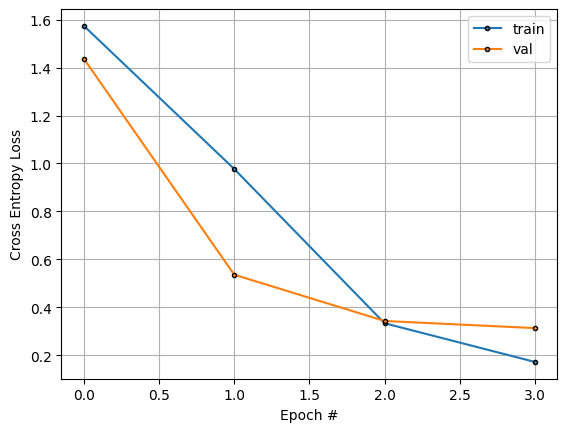

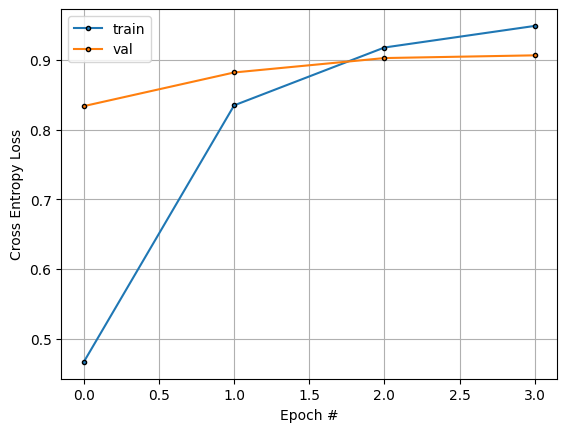

In [ ]:
plot_loss_curves(losses, val_losses, acc, val_acc)

## Evaluation

Evaluate your model. Once you are done experimenting, print out and interpet the classification report and confusion matrices for your model on the test set. Where does your model struggle? How would you use this information to improve performance?

100%|██████████| 12/12 [00:00<00:00, 84.87it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.88      0.90       147
           2       0.88      0.93      0.91       149
           3       0.84      0.84      0.84       147
           4       0.89      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737



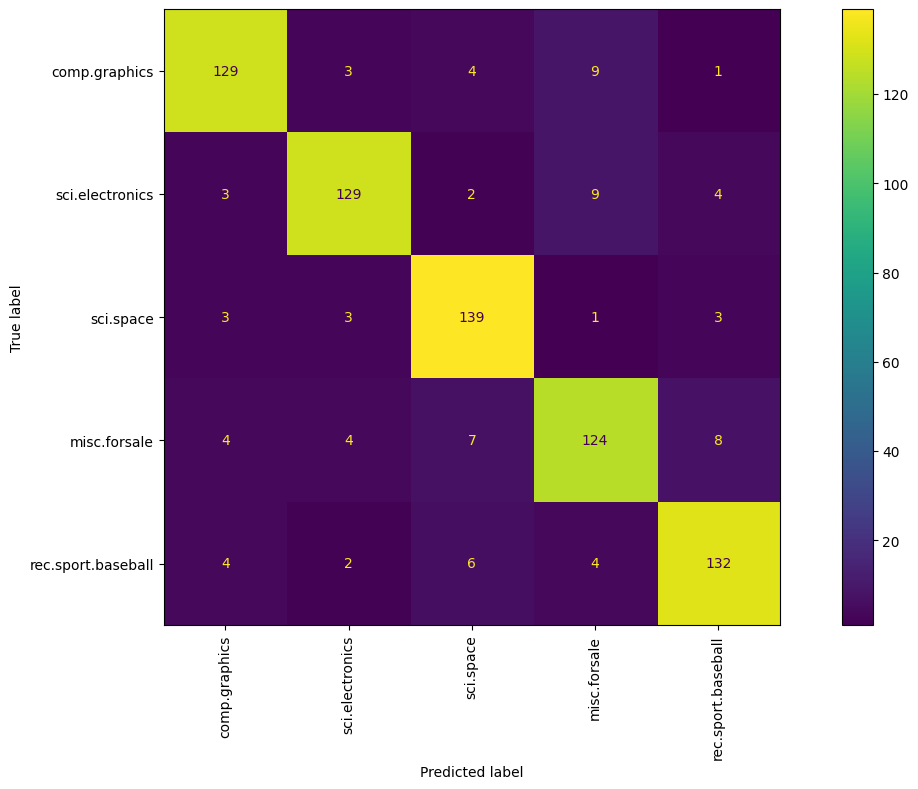

In [ ]:
evaluate(tuned_model, test_dl, device, class_names=categories)


Training combination 1/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 381.17it/s]



Epoch 1
Train Loss: 1.6077 | Train Acc: 20.06%
Val Loss: 1.6017 | Val Acc: 19.27%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 370.26it/s]



Epoch 2
Train Loss: 1.5858 | Train Acc: 29.01%
Val Loss: 1.5607 | Val Acc: 44.27%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 198.96it/s]



Epoch 3
Train Loss: 1.5033 | Train Acc: 66.43%
Val Loss: 1.4351 | Val Acc: 75.78%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 203.34it/s]



Epoch 4
Train Loss: 1.2952 | Train Acc: 82.17%
Val Loss: 1.1779 | Val Acc: 81.12%


100%|██████████| 24/24 [00:00<00:00, 463.28it/s]


              precision    recall  f1-score   support

           0       0.85      0.86      0.85       146
           1       0.94      0.87      0.90       147
           2       0.90      0.90      0.90       149
           3       0.96      0.51      0.67       147
           4       0.62      0.95      0.75       148

    accuracy                           0.82       737
   macro avg       0.85      0.82      0.82       737
weighted avg       0.85      0.82      0.82       737

New best accuracy: 81.12%

Training combination 2/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 409.92it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 24.70%
Val Loss: 1.6013 | Val Acc: 52.34%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 389.04it/s]



Epoch 2
Train Loss: 1.5857 | Train Acc: 51.02%
Val Loss: 1.5589 | Val Acc: 68.75%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 379.73it/s]



Epoch 3
Train Loss: 1.5013 | Train Acc: 74.00%
Val Loss: 1.4296 | Val Acc: 83.46%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 505.02it/s]



Epoch 4
Train Loss: 1.2894 | Train Acc: 84.04%
Val Loss: 1.1690 | Val Acc: 85.42%


100%|██████████| 24/24 [00:00<00:00, 480.87it/s]


              precision    recall  f1-score   support

           0       0.88      0.87      0.88       146
           1       0.75      0.94      0.84       147
           2       0.77      0.95      0.85       149
           3       0.89      0.54      0.67       147
           4       0.85      0.79      0.82       148

    accuracy                           0.82       737
   macro avg       0.83      0.82      0.81       737
weighted avg       0.83      0.82      0.81       737

New best accuracy: 85.42%

Training combination 3/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 381.62it/s]



Epoch 1
Train Loss: 1.6073 | Train Acc: 21.54%
Val Loss: 1.5985 | Val Acc: 25.13%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 443.79it/s]



Epoch 2
Train Loss: 1.5807 | Train Acc: 39.10%
Val Loss: 1.5491 | Val Acc: 67.58%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 391.92it/s]



Epoch 3
Train Loss: 1.4808 | Train Acc: 77.84%
Val Loss: 1.4044 | Val Acc: 77.21%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 485.07it/s]



Epoch 4
Train Loss: 1.2570 | Train Acc: 81.39%
Val Loss: 1.1485 | Val Acc: 76.82%


100%|██████████| 24/24 [00:00<00:00, 524.49it/s]


              precision    recall  f1-score   support

           0       0.64      0.93      0.76       146
           1       0.93      0.85      0.89       147
           2       0.75      0.96      0.84       149
           3       1.00      0.31      0.47       147
           4       0.77      0.80      0.79       148

    accuracy                           0.77       737
   macro avg       0.82      0.77      0.75       737
weighted avg       0.82      0.77      0.75       737


Training combination 4/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 403.18it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 21.80%
Val Loss: 1.6042 | Val Acc: 25.13%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 409.51it/s]



Epoch 2
Train Loss: 1.5873 | Train Acc: 35.51%
Val Loss: 1.5660 | Val Acc: 44.27%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 459.98it/s]



Epoch 3
Train Loss: 1.5096 | Train Acc: 69.52%
Val Loss: 1.4433 | Val Acc: 83.72%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 359.47it/s]



Epoch 4
Train Loss: 1.3090 | Train Acc: 86.22%
Val Loss: 1.1947 | Val Acc: 87.89%


100%|██████████| 24/24 [00:00<00:00, 417.48it/s]


              precision    recall  f1-score   support

           0       0.94      0.81      0.87       146
           1       0.79      0.93      0.85       147
           2       0.98      0.85      0.91       149
           3       0.80      0.84      0.82       147
           4       0.83      0.88      0.86       148

    accuracy                           0.86       737
   macro avg       0.87      0.86      0.86       737
weighted avg       0.87      0.86      0.86       737

New best accuracy: 87.89%

Training combination 5/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 417.52it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 21.17%
Val Loss: 1.6048 | Val Acc: 20.57%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 349.97it/s]



Epoch 2
Train Loss: 1.5846 | Train Acc: 40.95%
Val Loss: 1.5590 | Val Acc: 64.58%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 399.83it/s]



Epoch 3
Train Loss: 1.4954 | Train Acc: 70.75%
Val Loss: 1.4203 | Val Acc: 69.79%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 483.42it/s]



Epoch 4
Train Loss: 1.2752 | Train Acc: 81.47%
Val Loss: 1.1584 | Val Acc: 74.74%


100%|██████████| 24/24 [00:00<00:00, 503.94it/s]


              precision    recall  f1-score   support

           0       0.95      0.80      0.87       146
           1       0.83      0.93      0.88       147
           2       0.98      0.87      0.92       149
           3       0.89      0.32      0.47       147
           4       0.54      0.96      0.69       148

    accuracy                           0.78       737
   macro avg       0.84      0.78      0.77       737
weighted avg       0.84      0.78      0.77       737


Training combination 6/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 413.32it/s]



Epoch 1
Train Loss: 1.6087 | Train Acc: 23.07%
Val Loss: 1.6036 | Val Acc: 26.82%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 391.14it/s]



Epoch 2
Train Loss: 1.5851 | Train Acc: 37.04%
Val Loss: 1.5587 | Val Acc: 51.56%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 329.21it/s]



Epoch 3
Train Loss: 1.4917 | Train Acc: 68.59%
Val Loss: 1.4204 | Val Acc: 73.31%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 509.99it/s]



Epoch 4
Train Loss: 1.2684 | Train Acc: 79.64%
Val Loss: 1.1600 | Val Acc: 77.86%


100%|██████████| 24/24 [00:00<00:00, 508.47it/s]


              precision    recall  f1-score   support

           0       0.82      0.84      0.83       146
           1       0.81      0.93      0.86       147
           2       0.74      0.96      0.84       149
           3       1.00      0.39      0.56       147
           4       0.73      0.84      0.78       148

    accuracy                           0.79       737
   macro avg       0.82      0.79      0.77       737
weighted avg       0.82      0.79      0.77       737


Training combination 7/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 271.17it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 20.30%
Val Loss: 1.5992 | Val Acc: 23.31%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 204.88it/s]



Epoch 2
Train Loss: 1.5845 | Train Acc: 31.01%
Val Loss: 1.5551 | Val Acc: 54.69%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 317.88it/s]



Epoch 3
Train Loss: 1.4967 | Train Acc: 73.63%
Val Loss: 1.4240 | Val Acc: 86.33%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 178.37it/s]



Epoch 4
Train Loss: 1.2817 | Train Acc: 85.61%
Val Loss: 1.1632 | Val Acc: 82.29%


100%|██████████| 24/24 [00:00<00:00, 345.06it/s]


              precision    recall  f1-score   support

           0       0.94      0.81      0.87       146
           1       0.81      0.93      0.86       147
           2       0.83      0.91      0.87       149
           3       0.79      0.67      0.73       147
           4       0.83      0.87      0.85       148

    accuracy                           0.84       737
   macro avg       0.84      0.84      0.84       737
weighted avg       0.84      0.84      0.84       737


Training combination 8/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 507.19it/s]



Epoch 1
Train Loss: 1.6069 | Train Acc: 24.27%
Val Loss: 1.6025 | Val Acc: 33.33%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 501.63it/s]



Epoch 2
Train Loss: 1.5823 | Train Acc: 47.08%
Val Loss: 1.5543 | Val Acc: 68.75%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 508.62it/s]



Epoch 3
Train Loss: 1.4855 | Train Acc: 79.82%
Val Loss: 1.4095 | Val Acc: 79.04%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 497.77it/s]



Epoch 4
Train Loss: 1.2598 | Train Acc: 85.96%
Val Loss: 1.1443 | Val Acc: 86.98%


100%|██████████| 24/24 [00:00<00:00, 495.12it/s]


              precision    recall  f1-score   support

           0       0.72      0.93      0.81       146
           1       0.87      0.93      0.90       147
           2       0.94      0.87      0.91       149
           3       0.93      0.69      0.79       147
           4       0.87      0.84      0.86       148

    accuracy                           0.85       737
   macro avg       0.87      0.85      0.85       737
weighted avg       0.87      0.85      0.85       737


Training combination 9/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 519.14it/s]



Epoch 1
Train Loss: 1.6084 | Train Acc: 23.98%
Val Loss: 1.6041 | Val Acc: 38.41%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 484.78it/s]



Epoch 2
Train Loss: 1.5829 | Train Acc: 46.75%
Val Loss: 1.5553 | Val Acc: 56.12%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 514.04it/s]



Epoch 3
Train Loss: 1.4862 | Train Acc: 68.30%
Val Loss: 1.4089 | Val Acc: 71.61%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 400.47it/s]



Epoch 4
Train Loss: 1.2550 | Train Acc: 78.44%
Val Loss: 1.1440 | Val Acc: 76.43%


100%|██████████| 24/24 [00:00<00:00, 418.14it/s]


              precision    recall  f1-score   support

           0       0.85      0.86      0.86       146
           1       0.64      0.95      0.77       147
           2       0.89      0.89      0.89       149
           3       1.00      0.29      0.45       147
           4       0.74      0.90      0.81       148

    accuracy                           0.78       737
   macro avg       0.82      0.78      0.76       737
weighted avg       0.82      0.78      0.76       737


Training combination 10/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 520.19it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 19.80%
Val Loss: 1.6022 | Val Acc: 19.01%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 526.67it/s]



Epoch 2
Train Loss: 1.5829 | Train Acc: 31.60%
Val Loss: 1.5545 | Val Acc: 59.24%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 504.68it/s]



Epoch 3
Train Loss: 1.4886 | Train Acc: 76.99%
Val Loss: 1.4133 | Val Acc: 81.77%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 464.95it/s]



Epoch 4
Train Loss: 1.2650 | Train Acc: 85.93%
Val Loss: 1.1470 | Val Acc: 83.59%


100%|██████████| 24/24 [00:00<00:00, 455.06it/s]


              precision    recall  f1-score   support

           0       0.89      0.82      0.85       146
           1       0.85      0.91      0.88       147
           2       0.85      0.92      0.88       149
           3       0.90      0.61      0.73       147
           4       0.72      0.91      0.80       148

    accuracy                           0.83       737
   macro avg       0.84      0.83      0.83       737
weighted avg       0.84      0.83      0.83       737


Training combination 11/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 513.85it/s]



Epoch 1
Train Loss: 1.6075 | Train Acc: 21.77%
Val Loss: 1.6017 | Val Acc: 20.05%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 510.83it/s]



Epoch 2
Train Loss: 1.5819 | Train Acc: 39.01%
Val Loss: 1.5535 | Val Acc: 62.11%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 456.30it/s]



Epoch 3
Train Loss: 1.4862 | Train Acc: 72.50%
Val Loss: 1.4082 | Val Acc: 78.39%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 406.07it/s]



Epoch 4
Train Loss: 1.2630 | Train Acc: 81.21%
Val Loss: 1.1446 | Val Acc: 81.77%


100%|██████████| 24/24 [00:00<00:00, 411.55it/s]


              precision    recall  f1-score   support

           0       0.94      0.77      0.85       146
           1       0.70      0.96      0.81       147
           2       0.85      0.90      0.88       149
           3       0.93      0.59      0.72       147
           4       0.78      0.87      0.82       148

    accuracy                           0.82       737
   macro avg       0.84      0.82      0.82       737
weighted avg       0.84      0.82      0.82       737


Training combination 12/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 448.49it/s]



Epoch 1
Train Loss: 1.6085 | Train Acc: 21.72%
Val Loss: 1.6042 | Val Acc: 26.30%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 515.19it/s]



Epoch 2
Train Loss: 1.5884 | Train Acc: 37.13%
Val Loss: 1.5659 | Val Acc: 52.60%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 404.94it/s]



Epoch 3
Train Loss: 1.5078 | Train Acc: 74.61%
Val Loss: 1.4415 | Val Acc: 80.34%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 373.96it/s]



Epoch 4
Train Loss: 1.3070 | Train Acc: 85.03%
Val Loss: 1.2018 | Val Acc: 81.90%


100%|██████████| 24/24 [00:00<00:00, 435.07it/s]


              precision    recall  f1-score   support

           0       0.88      0.86      0.87       146
           1       0.84      0.90      0.87       147
           2       0.92      0.88      0.90       149
           3       0.93      0.67      0.78       147
           4       0.71      0.91      0.80       148

    accuracy                           0.84       737
   macro avg       0.86      0.84      0.84       737
weighted avg       0.86      0.84      0.84       737


Training combination 13/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 500.60it/s]



Epoch 1
Train Loss: 1.6081 | Train Acc: 20.44%
Val Loss: 1.5997 | Val Acc: 19.40%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 513.15it/s]



Epoch 2
Train Loss: 1.5811 | Train Acc: 36.58%
Val Loss: 1.5490 | Val Acc: 53.91%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 426.14it/s]



Epoch 3
Train Loss: 1.4821 | Train Acc: 68.77%
Val Loss: 1.4013 | Val Acc: 78.65%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 459.85it/s]



Epoch 4
Train Loss: 1.2595 | Train Acc: 77.44%
Val Loss: 1.1547 | Val Acc: 85.16%


100%|██████████| 24/24 [00:00<00:00, 420.40it/s]


              precision    recall  f1-score   support

           0       0.76      0.91      0.83       146
           1       0.82      0.93      0.87       147
           2       0.89      0.89      0.89       149
           3       0.81      0.66      0.73       147
           4       0.90      0.78      0.84       148

    accuracy                           0.83       737
   macro avg       0.84      0.83      0.83       737
weighted avg       0.84      0.83      0.83       737


Training combination 14/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 443.87it/s]



Epoch 1
Train Loss: 1.6086 | Train Acc: 20.96%
Val Loss: 1.6020 | Val Acc: 21.09%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 516.31it/s]



Epoch 2
Train Loss: 1.5854 | Train Acc: 41.17%
Val Loss: 1.5566 | Val Acc: 68.75%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 384.83it/s]



Epoch 3
Train Loss: 1.4922 | Train Acc: 75.79%
Val Loss: 1.4133 | Val Acc: 77.73%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 455.51it/s]



Epoch 4
Train Loss: 1.2606 | Train Acc: 80.92%
Val Loss: 1.1406 | Val Acc: 80.34%


100%|██████████| 24/24 [00:00<00:00, 466.70it/s]


              precision    recall  f1-score   support

           0       0.66      0.96      0.78       146
           1       0.89      0.92      0.91       147
           2       0.90      0.88      0.89       149
           3       0.97      0.57      0.72       147
           4       0.87      0.82      0.84       148

    accuracy                           0.83       737
   macro avg       0.86      0.83      0.83       737
weighted avg       0.86      0.83      0.83       737


Training combination 15/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 501.09it/s]



Epoch 1
Train Loss: 1.6078 | Train Acc: 20.39%
Val Loss: 1.5998 | Val Acc: 23.31%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 491.48it/s]



Epoch 2
Train Loss: 1.5866 | Train Acc: 29.05%
Val Loss: 1.5597 | Val Acc: 49.48%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 465.86it/s]



Epoch 3
Train Loss: 1.5058 | Train Acc: 64.98%
Val Loss: 1.4325 | Val Acc: 80.86%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 437.64it/s]



Epoch 4
Train Loss: 1.2976 | Train Acc: 84.42%
Val Loss: 1.1780 | Val Acc: 87.89%


100%|██████████| 24/24 [00:00<00:00, 398.79it/s]


              precision    recall  f1-score   support

           0       0.84      0.85      0.85       146
           1       0.92      0.90      0.91       147
           2       0.93      0.88      0.90       149
           3       0.70      0.83      0.76       147
           4       0.93      0.82      0.87       148

    accuracy                           0.85       737
   macro avg       0.86      0.85      0.86       737
weighted avg       0.86      0.85      0.86       737


Training combination 16/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 507.20it/s]



Epoch 1
Train Loss: 1.6072 | Train Acc: 23.71%
Val Loss: 1.6014 | Val Acc: 33.98%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 500.98it/s]



Epoch 2
Train Loss: 1.5833 | Train Acc: 43.71%
Val Loss: 1.5569 | Val Acc: 59.38%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 517.28it/s]



Epoch 3
Train Loss: 1.4936 | Train Acc: 76.03%
Val Loss: 1.4213 | Val Acc: 76.17%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 521.02it/s]



Epoch 4
Train Loss: 1.2697 | Train Acc: 82.43%
Val Loss: 1.1617 | Val Acc: 76.82%


100%|██████████| 24/24 [00:00<00:00, 474.51it/s]


              precision    recall  f1-score   support

           0       0.87      0.84      0.85       146
           1       0.70      0.94      0.80       147
           2       0.73      0.97      0.83       149
           3       0.96      0.35      0.52       147
           4       0.85      0.85      0.85       148

    accuracy                           0.79       737
   macro avg       0.82      0.79      0.77       737
weighted avg       0.82      0.79      0.77       737


Training combination 17/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 511.07it/s]



Epoch 1
Train Loss: 1.6083 | Train Acc: 22.15%
Val Loss: 1.6036 | Val Acc: 25.65%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 492.79it/s]



Epoch 2
Train Loss: 1.5855 | Train Acc: 36.20%
Val Loss: 1.5598 | Val Acc: 52.47%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 426.83it/s]



Epoch 3
Train Loss: 1.4925 | Train Acc: 70.25%
Val Loss: 1.4162 | Val Acc: 75.91%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 473.26it/s]



Epoch 4
Train Loss: 1.2664 | Train Acc: 77.45%
Val Loss: 1.1618 | Val Acc: 78.26%


100%|██████████| 24/24 [00:00<00:00, 519.05it/s]


              precision    recall  f1-score   support

           0       0.81      0.86      0.84       146
           1       0.62      0.95      0.75       147
           2       0.70      0.95      0.81       149
           3       0.94      0.31      0.47       147
           4       0.96      0.68      0.79       148

    accuracy                           0.75       737
   macro avg       0.81      0.75      0.73       737
weighted avg       0.81      0.75      0.73       737


Training combination 18/162
{'lr': 0.0001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 491.55it/s]



Epoch 1
Train Loss: 1.6073 | Train Acc: 26.38%
Val Loss: 1.6014 | Val Acc: 52.99%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 475.02it/s]



Epoch 2
Train Loss: 1.5853 | Train Acc: 60.31%
Val Loss: 1.5595 | Val Acc: 75.91%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 425.31it/s]



Epoch 3
Train Loss: 1.5001 | Train Acc: 75.10%
Val Loss: 1.4307 | Val Acc: 72.92%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 473.45it/s]



Epoch 4
Train Loss: 1.2913 | Train Acc: 80.28%
Val Loss: 1.1801 | Val Acc: 76.69%


100%|██████████| 24/24 [00:00<00:00, 492.67it/s]


              precision    recall  f1-score   support

           0       0.87      0.86      0.87       146
           1       0.59      0.97      0.73       147
           2       0.98      0.87      0.92       149
           3       0.92      0.37      0.52       147
           4       0.84      0.90      0.87       148

    accuracy                           0.79       737
   macro avg       0.84      0.79      0.78       737
weighted avg       0.84      0.79      0.78       737


Training combination 19/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 286.54it/s]



Epoch 1
Train Loss: 1.6097 | Train Acc: 20.40%
Val Loss: 1.6064 | Val Acc: 20.26%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 292.45it/s]



Epoch 2
Train Loss: 1.6004 | Train Acc: 22.99%
Val Loss: 1.5906 | Val Acc: 30.13%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 291.43it/s]



Epoch 3
Train Loss: 1.5735 | Train Acc: 34.64%
Val Loss: 1.5531 | Val Acc: 41.03%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.25it/s]



Epoch 4
Train Loss: 1.5175 | Train Acc: 58.03%
Val Loss: 1.4813 | Val Acc: 75.33%


100%|██████████| 12/12 [00:00<00:00, 273.55it/s]


              precision    recall  f1-score   support

           0       0.71      0.91      0.80       146
           1       0.98      0.54      0.70       147
           2       0.53      0.99      0.69       149
           3       0.95      0.56      0.71       147
           4       0.98      0.69      0.81       148

    accuracy                           0.74       737
   macro avg       0.83      0.74      0.74       737
weighted avg       0.83      0.74      0.74       737


Training combination 20/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 280.22it/s]



Epoch 1
Train Loss: 1.6094 | Train Acc: 20.15%
Val Loss: 1.6069 | Val Acc: 19.64%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 322.31it/s]



Epoch 2
Train Loss: 1.6005 | Train Acc: 24.09%
Val Loss: 1.5917 | Val Acc: 30.67%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.21it/s]



Epoch 3
Train Loss: 1.5749 | Train Acc: 47.52%
Val Loss: 1.5553 | Val Acc: 62.21%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 304.51it/s]



Epoch 4
Train Loss: 1.5204 | Train Acc: 66.37%
Val Loss: 1.4869 | Val Acc: 70.25%


100%|██████████| 12/12 [00:00<00:00, 313.36it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.64      0.92      0.76       146
           1       0.98      0.65      0.78       147
           2       0.90      0.87      0.88       149
           3       0.00      0.00      0.00       147
           4       0.46      0.90      0.61       148

    accuracy                           0.67       737
   macro avg       0.60      0.67      0.61       737
weighted avg       0.60      0.67      0.61       737


Training combination 21/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 288.43it/s]



Epoch 1
Train Loss: 1.6086 | Train Acc: 22.78%
Val Loss: 1.6059 | Val Acc: 21.67%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 292.08it/s]



Epoch 2
Train Loss: 1.6001 | Train Acc: 37.33%
Val Loss: 1.5918 | Val Acc: 52.60%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.82it/s]



Epoch 3
Train Loss: 1.5765 | Train Acc: 53.04%
Val Loss: 1.5576 | Val Acc: 57.41%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 287.94it/s]



Epoch 4
Train Loss: 1.5251 | Train Acc: 65.04%
Val Loss: 1.4932 | Val Acc: 71.68%


100%|██████████| 12/12 [00:00<00:00, 278.67it/s]
/tmp/ipykernel_793/1463625653.py:94: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16,8))


              precision    recall  f1-score   support

           0       0.99      0.57      0.72       146
           1       0.56      0.93      0.70       147
           2       0.84      0.89      0.86       149
           3       1.00      0.20      0.34       147
           4       0.63      0.95      0.75       148

    accuracy                           0.71       737
   macro avg       0.80      0.71      0.68       737
weighted avg       0.80      0.71      0.68       737


Training combination 22/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 291.74it/s]



Epoch 1
Train Loss: 1.6087 | Train Acc: 21.58%
Val Loss: 1.6057 | Val Acc: 20.78%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 277.36it/s]



Epoch 2
Train Loss: 1.6009 | Train Acc: 29.60%
Val Loss: 1.5924 | Val Acc: 36.35%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 295.99it/s]



Epoch 3
Train Loss: 1.5782 | Train Acc: 46.80%
Val Loss: 1.5602 | Val Acc: 62.86%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 282.94it/s]



Epoch 4
Train Loss: 1.5277 | Train Acc: 74.87%
Val Loss: 1.4937 | Val Acc: 80.00%


100%|██████████| 12/12 [00:00<00:00, 280.01it/s]


              precision    recall  f1-score   support

           0       0.95      0.81      0.87       146
           1       0.86      0.90      0.88       147
           2       0.60      0.99      0.74       149
           3       0.97      0.71      0.82       147
           4       0.95      0.67      0.79       148

    accuracy                           0.82       737
   macro avg       0.87      0.82      0.82       737
weighted avg       0.87      0.82      0.82       737


Training combination 23/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 271.50it/s]



Epoch 1
Train Loss: 1.6093 | Train Acc: 19.84%
Val Loss: 1.6062 | Val Acc: 20.11%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 286.91it/s]



Epoch 2
Train Loss: 1.6008 | Train Acc: 20.38%
Val Loss: 1.5925 | Val Acc: 21.02%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.39it/s]



Epoch 3
Train Loss: 1.5766 | Train Acc: 42.33%
Val Loss: 1.5581 | Val Acc: 71.15%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 275.80it/s]



Epoch 4
Train Loss: 1.5242 | Train Acc: 81.35%
Val Loss: 1.4903 | Val Acc: 89.08%


100%|██████████| 12/12 [00:00<00:00, 280.28it/s]


              precision    recall  f1-score   support

           0       0.84      0.90      0.87       146
           1       0.81      0.93      0.86       147
           2       0.94      0.89      0.91       149
           3       0.87      0.84      0.86       147
           4       0.97      0.82      0.89       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737

New best accuracy: 89.08%

Training combination 24/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.50it/s]



Epoch 1
Train Loss: 1.6101 | Train Acc: 19.79%
Val Loss: 1.6075 | Val Acc: 20.11%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.35it/s]



Epoch 2
Train Loss: 1.6029 | Train Acc: 19.85%
Val Loss: 1.5957 | Val Acc: 20.11%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 266.83it/s]



Epoch 3
Train Loss: 1.5828 | Train Acc: 24.45%
Val Loss: 1.5665 | Val Acc: 36.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 289.21it/s]



Epoch 4
Train Loss: 1.5373 | Train Acc: 49.68%
Val Loss: 1.5062 | Val Acc: 64.02%


100%|██████████| 12/12 [00:00<00:00, 277.64it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.97      0.52      0.68       146
           1       0.35      1.00      0.52       147
           2       0.95      0.79      0.86       149
           3       0.00      0.00      0.00       147
           4       0.96      0.74      0.84       148

    accuracy                           0.61       737
   macro avg       0.65      0.61      0.58       737
weighted avg       0.65      0.61      0.58       737


Training combination 25/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 163.17it/s]



Epoch 1
Train Loss: 1.6088 | Train Acc: 19.83%
Val Loss: 1.6055 | Val Acc: 20.11%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.96it/s]



Epoch 2
Train Loss: 1.5990 | Train Acc: 20.55%
Val Loss: 1.5885 | Val Acc: 22.70%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 298.13it/s]



Epoch 3
Train Loss: 1.5698 | Train Acc: 36.23%
Val Loss: 1.5473 | Val Acc: 49.86%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 287.52it/s]



Epoch 4
Train Loss: 1.5069 | Train Acc: 61.71%
Val Loss: 1.4663 | Val Acc: 74.92%


100%|██████████| 12/12 [00:00<00:00, 259.77it/s]


              precision    recall  f1-score   support

           0       0.98      0.41      0.58       146
           1       0.48      0.98      0.64       147
           2       0.86      0.90      0.88       149
           3       0.92      0.59      0.72       147
           4       0.91      0.76      0.83       148

    accuracy                           0.73       737
   macro avg       0.83      0.73      0.73       737
weighted avg       0.83      0.73      0.73       737


Training combination 26/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 200.97it/s]



Epoch 1
Train Loss: 1.6080 | Train Acc: 19.83%
Val Loss: 1.6048 | Val Acc: 20.11%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 267.23it/s]



Epoch 2
Train Loss: 1.5984 | Train Acc: 24.49%
Val Loss: 1.5884 | Val Acc: 36.49%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 176.81it/s]



Epoch 3
Train Loss: 1.5701 | Train Acc: 55.18%
Val Loss: 1.5499 | Val Acc: 70.11%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 196.90it/s]



Epoch 4
Train Loss: 1.5122 | Train Acc: 75.88%
Val Loss: 1.4753 | Val Acc: 78.30%


100%|██████████| 12/12 [00:00<00:00, 221.30it/s]


              precision    recall  f1-score   support

           0       0.98      0.64      0.78       146
           1       0.62      0.97      0.76       147
           2       0.67      0.91      0.77       149
           3       0.94      0.45      0.61       147
           4       0.79      0.76      0.78       148

    accuracy                           0.75       737
   macro avg       0.80      0.75      0.74       737
weighted avg       0.80      0.75      0.74       737


Training combination 27/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 286.09it/s]



Epoch 1
Train Loss: 1.6095 | Train Acc: 19.82%
Val Loss: 1.6072 | Val Acc: 19.87%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 274.34it/s]



Epoch 2
Train Loss: 1.6014 | Train Acc: 19.99%
Val Loss: 1.5935 | Val Acc: 20.13%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 231.20it/s]



Epoch 3
Train Loss: 1.5776 | Train Acc: 30.31%
Val Loss: 1.5570 | Val Acc: 42.44%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 266.27it/s]



Epoch 4
Train Loss: 1.5212 | Train Acc: 56.04%
Val Loss: 1.4840 | Val Acc: 62.97%


100%|██████████| 12/12 [00:00<00:00, 260.82it/s]


              precision    recall  f1-score   support

           0       0.36      0.99      0.52       146
           1       0.82      0.85      0.84       147
           2       0.99      0.71      0.83       149
           3       1.00      0.01      0.03       147
           4       0.97      0.47      0.63       148

    accuracy                           0.61       737
   macro avg       0.83      0.61      0.57       737
weighted avg       0.83      0.61      0.57       737


Training combination 28/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 276.25it/s]



Epoch 1
Train Loss: 1.6081 | Train Acc: 22.91%
Val Loss: 1.6056 | Val Acc: 24.15%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 291.16it/s]



Epoch 2
Train Loss: 1.6000 | Train Acc: 36.87%
Val Loss: 1.5922 | Val Acc: 49.22%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 292.27it/s]



Epoch 3
Train Loss: 1.5769 | Train Acc: 58.00%
Val Loss: 1.5582 | Val Acc: 71.16%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 224.68it/s]



Epoch 4
Train Loss: 1.5241 | Train Acc: 75.75%
Val Loss: 1.4896 | Val Acc: 80.89%


100%|██████████| 12/12 [00:00<00:00, 210.10it/s]


              precision    recall  f1-score   support

           0       0.70      0.90      0.79       146
           1       0.99      0.52      0.68       147
           2       0.67      0.97      0.79       149
           3       0.76      0.75      0.76       147
           4       0.94      0.72      0.81       148

    accuracy                           0.77       737
   macro avg       0.81      0.77      0.76       737
weighted avg       0.81      0.77      0.76       737


Training combination 29/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.93it/s]



Epoch 1
Train Loss: 1.6107 | Train Acc: 21.77%
Val Loss: 1.6077 | Val Acc: 32.34%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 269.91it/s]



Epoch 2
Train Loss: 1.6010 | Train Acc: 29.28%
Val Loss: 1.5913 | Val Acc: 38.20%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 255.11it/s]



Epoch 3
Train Loss: 1.5734 | Train Acc: 43.99%
Val Loss: 1.5515 | Val Acc: 62.21%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 266.58it/s]



Epoch 4
Train Loss: 1.5124 | Train Acc: 68.87%
Val Loss: 1.4710 | Val Acc: 74.53%


100%|██████████| 12/12 [00:00<00:00, 301.80it/s]


              precision    recall  f1-score   support

           0       0.99      0.51      0.67       146
           1       0.69      0.94      0.79       147
           2       0.68      0.96      0.80       149
           3       0.69      0.67      0.68       147
           4       0.91      0.67      0.77       148

    accuracy                           0.75       737
   macro avg       0.79      0.75      0.74       737
weighted avg       0.79      0.75      0.74       737


Training combination 30/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 279.28it/s]



Epoch 1
Train Loss: 1.6092 | Train Acc: 21.76%
Val Loss: 1.6056 | Val Acc: 22.07%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 276.96it/s]



Epoch 2
Train Loss: 1.5995 | Train Acc: 30.64%
Val Loss: 1.5889 | Val Acc: 38.69%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.14it/s]



Epoch 3
Train Loss: 1.5699 | Train Acc: 51.15%
Val Loss: 1.5456 | Val Acc: 67.27%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 271.41it/s]



Epoch 4
Train Loss: 1.5047 | Train Acc: 75.18%
Val Loss: 1.4622 | Val Acc: 81.18%


100%|██████████| 12/12 [00:00<00:00, 269.34it/s]


              precision    recall  f1-score   support

           0       0.99      0.54      0.70       146
           1       0.77      0.95      0.85       147
           2       0.90      0.89      0.90       149
           3       0.64      0.78      0.71       147
           4       0.85      0.86      0.86       148

    accuracy                           0.81       737
   macro avg       0.83      0.81      0.80       737
weighted avg       0.83      0.81      0.80       737


Training combination 31/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 256.44it/s]



Epoch 1
Train Loss: 1.6099 | Train Acc: 20.24%
Val Loss: 1.6064 | Val Acc: 20.26%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 269.81it/s]



Epoch 2
Train Loss: 1.5998 | Train Acc: 21.21%
Val Loss: 1.5900 | Val Acc: 22.47%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 263.07it/s]



Epoch 3
Train Loss: 1.5729 | Train Acc: 31.61%
Val Loss: 1.5517 | Val Acc: 47.15%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 265.31it/s]



Epoch 4
Train Loss: 1.5143 | Train Acc: 64.48%
Val Loss: 1.4755 | Val Acc: 77.41%


100%|██████████| 12/12 [00:00<00:00, 274.50it/s]


              precision    recall  f1-score   support

           0       0.95      0.76      0.84       146
           1       0.91      0.80      0.85       147
           2       0.61      0.98      0.75       149
           3       0.91      0.41      0.56       147
           4       0.68      0.86      0.76       148

    accuracy                           0.76       737
   macro avg       0.81      0.76      0.75       737
weighted avg       0.81      0.76      0.75       737


Training combination 32/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 271.90it/s]



Epoch 1
Train Loss: 1.6089 | Train Acc: 23.58%
Val Loss: 1.6056 | Val Acc: 50.90%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 286.45it/s]



Epoch 2
Train Loss: 1.6001 | Train Acc: 40.04%
Val Loss: 1.5915 | Val Acc: 55.06%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 288.45it/s]



Epoch 3
Train Loss: 1.5753 | Train Acc: 58.59%
Val Loss: 1.5564 | Val Acc: 70.25%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.90it/s]



Epoch 4
Train Loss: 1.5220 | Train Acc: 75.85%
Val Loss: 1.4865 | Val Acc: 77.65%


100%|██████████| 12/12 [00:00<00:00, 207.24it/s]


              precision    recall  f1-score   support

           0       0.91      0.84      0.88       146
           1       0.59      0.97      0.73       147
           2       0.96      0.87      0.91       149
           3       0.98      0.28      0.43       147
           4       0.73      0.91      0.81       148

    accuracy                           0.77       737
   macro avg       0.83      0.77      0.75       737
weighted avg       0.83      0.77      0.75       737


Training combination 33/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 259.51it/s]



Epoch 1
Train Loss: 1.6091 | Train Acc: 19.78%
Val Loss: 1.6061 | Val Acc: 19.87%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 282.72it/s]



Epoch 2
Train Loss: 1.6000 | Train Acc: 19.93%
Val Loss: 1.5914 | Val Acc: 20.38%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 274.89it/s]



Epoch 3
Train Loss: 1.5752 | Train Acc: 33.13%
Val Loss: 1.5565 | Val Acc: 56.07%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.94it/s]



Epoch 4
Train Loss: 1.5221 | Train Acc: 71.14%
Val Loss: 1.4878 | Val Acc: 82.22%


100%|██████████| 12/12 [00:00<00:00, 283.46it/s]


              precision    recall  f1-score   support

           0       0.53      0.97      0.69       146
           1       0.93      0.88      0.90       147
           2       0.98      0.79      0.87       149
           3       0.97      0.63      0.76       147
           4       0.93      0.75      0.83       148

    accuracy                           0.80       737
   macro avg       0.87      0.80      0.81       737
weighted avg       0.87      0.80      0.81       737


Training combination 34/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 272.70it/s]



Epoch 1
Train Loss: 1.6085 | Train Acc: 20.40%
Val Loss: 1.6058 | Val Acc: 20.11%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.34it/s]



Epoch 2
Train Loss: 1.5996 | Train Acc: 27.63%
Val Loss: 1.5908 | Val Acc: 42.31%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 256.60it/s]



Epoch 3
Train Loss: 1.5729 | Train Acc: 56.76%
Val Loss: 1.5530 | Val Acc: 67.53%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 283.04it/s]



Epoch 4
Train Loss: 1.5167 | Train Acc: 77.17%
Val Loss: 1.4825 | Val Acc: 81.43%


100%|██████████| 12/12 [00:00<00:00, 271.65it/s]


              precision    recall  f1-score   support

           0       0.78      0.90      0.84       146
           1       0.65      0.97      0.77       147
           2       0.98      0.82      0.89       149
           3       0.96      0.46      0.62       147
           4       0.85      0.88      0.86       148

    accuracy                           0.81       737
   macro avg       0.84      0.81      0.80       737
weighted avg       0.84      0.81      0.80       737


Training combination 35/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.72it/s]



Epoch 1
Train Loss: 1.6089 | Train Acc: 22.92%
Val Loss: 1.6056 | Val Acc: 24.01%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 272.49it/s]



Epoch 2
Train Loss: 1.5996 | Train Acc: 36.46%
Val Loss: 1.5906 | Val Acc: 58.94%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 293.74it/s]



Epoch 3
Train Loss: 1.5728 | Train Acc: 64.86%
Val Loss: 1.5537 | Val Acc: 79.87%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 291.38it/s]



Epoch 4
Train Loss: 1.5171 | Train Acc: 82.96%
Val Loss: 1.4849 | Val Acc: 81.04%


100%|██████████| 12/12 [00:00<00:00, 214.21it/s]


              precision    recall  f1-score   support

           0       0.63      0.95      0.76       146
           1       0.90      0.90      0.90       147
           2       0.98      0.81      0.89       149
           3       0.96      0.52      0.67       147
           4       0.80      0.89      0.84       148

    accuracy                           0.81       737
   macro avg       0.85      0.81      0.81       737
weighted avg       0.85      0.81      0.81       737


Training combination 36/162
{'lr': 0.0001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.63it/s]



Epoch 1
Train Loss: 1.6098 | Train Acc: 23.14%
Val Loss: 1.6070 | Val Acc: 37.03%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 280.58it/s]



Epoch 2
Train Loss: 1.6010 | Train Acc: 33.71%
Val Loss: 1.5923 | Val Acc: 45.72%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.81it/s]



Epoch 3
Train Loss: 1.5750 | Train Acc: 50.08%
Val Loss: 1.5543 | Val Acc: 54.94%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 287.64it/s]



Epoch 4
Train Loss: 1.5173 | Train Acc: 64.29%
Val Loss: 1.4810 | Val Acc: 71.69%


100%|██████████| 12/12 [00:00<00:00, 274.24it/s]


              precision    recall  f1-score   support

           0       0.99      0.55      0.70       146
           1       0.78      0.89      0.83       147
           2       0.75      0.95      0.84       149
           3       1.00      0.18      0.30       147
           4       0.51      0.95      0.67       148

    accuracy                           0.70       737
   macro avg       0.81      0.70      0.67       737
weighted avg       0.81      0.70      0.67       737


Training combination 37/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.81it/s]



Epoch 1
Train Loss: 1.6093 | Train Acc: 19.84%
Val Loss: 1.6079 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.83it/s]



Epoch 2
Train Loss: 1.6050 | Train Acc: 19.93%
Val Loss: 1.6019 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.08it/s]



Epoch 3
Train Loss: 1.5959 | Train Acc: 24.45%
Val Loss: 1.5901 | Val Acc: 29.60%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.44it/s]



Epoch 4
Train Loss: 1.5797 | Train Acc: 39.21%
Val Loss: 1.5705 | Val Acc: 50.30%


100%|██████████| 6/6 [00:00<00:00, 127.58it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.98      0.40      0.57       146
           1       0.31      1.00      0.47       147
           2       1.00      0.35      0.52       149
           3       0.00      0.00      0.00       147
           4       0.77      0.77      0.77       148

    accuracy                           0.50       737
   macro avg       0.61      0.50      0.47       737
weighted avg       0.61      0.50      0.47       737


Training combination 38/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.48it/s]



Epoch 1
Train Loss: 1.6102 | Train Acc: 19.79%
Val Loss: 1.6084 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.77it/s]



Epoch 2
Train Loss: 1.6058 | Train Acc: 19.81%
Val Loss: 1.6031 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.85it/s]



Epoch 3
Train Loss: 1.5976 | Train Acc: 19.86%
Val Loss: 1.5924 | Val Acc: 19.80%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 141.90it/s]



Epoch 4
Train Loss: 1.5823 | Train Acc: 23.17%
Val Loss: 1.5743 | Val Acc: 26.47%


100%|██████████| 6/6 [00:00<00:00, 136.16it/s]


              precision    recall  f1-score   support

           0       0.21      1.00      0.35       146
           1       1.00      0.01      0.03       147
           2       1.00      0.18      0.31       149
           3       1.00      0.07      0.14       147
           4       1.00      0.03      0.07       148

    accuracy                           0.26       737
   macro avg       0.84      0.26      0.18       737
weighted avg       0.84      0.26      0.18       737


Training combination 39/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 121.86it/s]



Epoch 1
Train Loss: 1.6103 | Train Acc: 20.33%
Val Loss: 1.6081 | Val Acc: 20.52%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.49it/s]



Epoch 2
Train Loss: 1.6065 | Train Acc: 22.02%
Val Loss: 1.6031 | Val Acc: 21.44%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 151.20it/s]



Epoch 3
Train Loss: 1.5979 | Train Acc: 29.30%
Val Loss: 1.5920 | Val Acc: 35.60%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.81it/s]



Epoch 4
Train Loss: 1.5813 | Train Acc: 38.81%
Val Loss: 1.5715 | Val Acc: 44.40%


100%|██████████| 6/6 [00:00<00:00, 135.18it/s]


              precision    recall  f1-score   support

           0       0.40      0.90      0.55       146
           1       1.00      0.01      0.01       147
           2       0.39      0.97      0.55       149
           3       1.00      0.06      0.12       147
           4       1.00      0.12      0.22       148

    accuracy                           0.41       737
   macro avg       0.76      0.41      0.29       737
weighted avg       0.76      0.41      0.29       737


Training combination 40/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 138.99it/s]



Epoch 1
Train Loss: 1.6091 | Train Acc: 20.98%
Val Loss: 1.6078 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 126.99it/s]



Epoch 2
Train Loss: 1.6050 | Train Acc: 27.20%
Val Loss: 1.6025 | Val Acc: 28.77%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.73it/s]



Epoch 3
Train Loss: 1.5969 | Train Acc: 41.03%
Val Loss: 1.5916 | Val Acc: 49.27%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.39it/s]



Epoch 4
Train Loss: 1.5810 | Train Acc: 55.71%
Val Loss: 1.5733 | Val Acc: 60.66%


100%|██████████| 6/6 [00:00<00:00, 128.19it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.46      0.98      0.63       146
           1       0.95      0.67      0.78       147
           2       1.00      0.50      0.67       149
           3       0.00      0.00      0.00       147
           4       0.53      0.90      0.67       148

    accuracy                           0.61       737
   macro avg       0.59      0.61      0.55       737
weighted avg       0.59      0.61      0.55       737


Training combination 41/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 140.12it/s]



Epoch 1
Train Loss: 1.6087 | Train Acc: 19.85%
Val Loss: 1.6073 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.08it/s]



Epoch 2
Train Loss: 1.6048 | Train Acc: 22.66%
Val Loss: 1.6021 | Val Acc: 20.19%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.57it/s]



Epoch 3
Train Loss: 1.5964 | Train Acc: 37.11%
Val Loss: 1.5914 | Val Acc: 46.71%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.53it/s]



Epoch 4
Train Loss: 1.5810 | Train Acc: 62.18%
Val Loss: 1.5729 | Val Acc: 73.66%


100%|██████████| 6/6 [00:00<00:00, 127.92it/s]


              precision    recall  f1-score   support

           0       0.41      0.99      0.58       146
           1       0.96      0.74      0.84       147
           2       0.96      0.84      0.90       149
           3       0.94      0.51      0.66       147
           4       1.00      0.45      0.62       148

    accuracy                           0.71       737
   macro avg       0.86      0.71      0.72       737
weighted avg       0.86      0.71      0.72       737


Training combination 42/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.99it/s]



Epoch 1
Train Loss: 1.6093 | Train Acc: 20.13%
Val Loss: 1.6081 | Val Acc: 19.81%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.63it/s]



Epoch 2
Train Loss: 1.6052 | Train Acc: 24.12%
Val Loss: 1.6027 | Val Acc: 20.11%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.01it/s]



Epoch 3
Train Loss: 1.5969 | Train Acc: 29.42%
Val Loss: 1.5915 | Val Acc: 36.06%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 138.97it/s]



Epoch 4
Train Loss: 1.5809 | Train Acc: 43.82%
Val Loss: 1.5727 | Val Acc: 52.04%


100%|██████████| 6/6 [00:00<00:00, 132.59it/s]


              precision    recall  f1-score   support

           0       1.00      0.02      0.04       146
           1       0.98      0.54      0.69       147
           2       1.00      0.20      0.34       149
           3       0.38      0.74      0.50       147
           4       0.43      0.97      0.60       148

    accuracy                           0.50       737
   macro avg       0.76      0.49      0.43       737
weighted avg       0.76      0.50      0.43       737


Training combination 43/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.82it/s]



Epoch 1
Train Loss: 1.6102 | Train Acc: 20.10%
Val Loss: 1.6089 | Val Acc: 19.81%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.69it/s]



Epoch 2
Train Loss: 1.6060 | Train Acc: 20.09%
Val Loss: 1.6035 | Val Acc: 19.81%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.70it/s]



Epoch 3
Train Loss: 1.5975 | Train Acc: 20.27%
Val Loss: 1.5927 | Val Acc: 19.94%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 143.67it/s]



Epoch 4
Train Loss: 1.5819 | Train Acc: 26.54%
Val Loss: 1.5745 | Val Acc: 33.81%


100%|██████████| 6/6 [00:00<00:00, 126.97it/s]


              precision    recall  f1-score   support

           0       0.92      0.49      0.64       146
           1       1.00      0.11      0.20       147
           2       1.00      0.01      0.03       149
           3       1.00      0.01      0.01       147
           4       0.23      1.00      0.38       148

    accuracy                           0.32       737
   macro avg       0.83      0.32      0.25       737
weighted avg       0.83      0.32      0.25       737


Training combination 44/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 104.66it/s]



Epoch 1
Train Loss: 1.6095 | Train Acc: 20.02%
Val Loss: 1.6079 | Val Acc: 20.06%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 98.06it/s]



Epoch 2
Train Loss: 1.6058 | Train Acc: 20.04%
Val Loss: 1.6029 | Val Acc: 20.06%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 98.09it/s]



Epoch 3
Train Loss: 1.5977 | Train Acc: 20.26%
Val Loss: 1.5925 | Val Acc: 20.45%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.34it/s]



Epoch 4
Train Loss: 1.5832 | Train Acc: 27.80%
Val Loss: 1.5747 | Val Acc: 34.27%


100%|██████████| 6/6 [00:00<00:00, 112.32it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.01      0.01       146
           1       0.00      0.00      0.00       147
           2       1.00      0.53      0.69       149
           3       0.23      1.00      0.38       147
           4       1.00      0.19      0.32       148

    accuracy                           0.35       737
   macro avg       0.65      0.35      0.28       737
weighted avg       0.65      0.35      0.28       737


Training combination 45/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.30it/s]



Epoch 1
Train Loss: 1.6096 | Train Acc: 19.76%
Val Loss: 1.6083 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.29it/s]



Epoch 2
Train Loss: 1.6060 | Train Acc: 19.81%
Val Loss: 1.6038 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 83.97it/s]



Epoch 3
Train Loss: 1.5987 | Train Acc: 20.28%
Val Loss: 1.5947 | Val Acc: 19.93%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.87it/s]



Epoch 4
Train Loss: 1.5854 | Train Acc: 31.43%
Val Loss: 1.5789 | Val Acc: 40.73%


100%|██████████| 6/6 [00:00<00:00, 109.81it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.24      1.00      0.39       146
           1       1.00      0.38      0.55       147
           2       1.00      0.42      0.59       149
           3       1.00      0.09      0.16       147
           4       0.00      0.00      0.00       148

    accuracy                           0.38       737
   macro avg       0.65      0.38      0.34       737
weighted avg       0.65      0.38      0.34       737


Training combination 46/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.68it/s]



Epoch 1
Train Loss: 1.6102 | Train Acc: 19.82%
Val Loss: 1.6092 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.71it/s]



Epoch 2
Train Loss: 1.6064 | Train Acc: 19.80%
Val Loss: 1.6045 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 142.03it/s]



Epoch 3
Train Loss: 1.5991 | Train Acc: 20.39%
Val Loss: 1.5942 | Val Acc: 20.06%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 140.25it/s]



Epoch 4
Train Loss: 1.5835 | Train Acc: 28.30%
Val Loss: 1.5762 | Val Acc: 33.23%


100%|██████████| 6/6 [00:00<00:00, 133.22it/s]


              precision    recall  f1-score   support

           0       0.98      0.38      0.55       146
           1       0.22      1.00      0.37       147
           2       1.00      0.03      0.05       149
           3       1.00      0.10      0.17       147
           4       1.00      0.03      0.07       148

    accuracy                           0.31       737
   macro avg       0.84      0.31      0.24       737
weighted avg       0.84      0.31      0.24       737


Training combination 47/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.60it/s]



Epoch 1
Train Loss: 1.6100 | Train Acc: 20.11%
Val Loss: 1.6082 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.39it/s]



Epoch 2
Train Loss: 1.6061 | Train Acc: 25.46%
Val Loss: 1.6025 | Val Acc: 29.55%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 142.48it/s]



Epoch 3
Train Loss: 1.5970 | Train Acc: 37.24%
Val Loss: 1.5913 | Val Acc: 48.57%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.16it/s]



Epoch 4
Train Loss: 1.5816 | Train Acc: 47.33%
Val Loss: 1.5726 | Val Acc: 51.69%


100%|██████████| 6/6 [00:00<00:00, 136.04it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.29      0.99      0.45       146
           1       0.00      0.00      0.00       147
           2       0.87      0.85      0.86       149
           3       1.00      0.01      0.01       147
           4       0.90      0.62      0.74       148

    accuracy                           0.49       737
   macro avg       0.61      0.49      0.41       737
weighted avg       0.61      0.49      0.41       737


Training combination 48/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.96it/s]



Epoch 1
Train Loss: 1.6097 | Train Acc: 19.82%
Val Loss: 1.6077 | Val Acc: 28.69%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.65it/s]



Epoch 2
Train Loss: 1.6051 | Train Acc: 25.56%
Val Loss: 1.6018 | Val Acc: 36.44%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 143.00it/s]



Epoch 3
Train Loss: 1.5954 | Train Acc: 34.87%
Val Loss: 1.5895 | Val Acc: 47.27%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 136.47it/s]



Epoch 4
Train Loss: 1.5777 | Train Acc: 56.49%
Val Loss: 1.5683 | Val Acc: 67.16%


100%|██████████| 6/6 [00:00<00:00, 139.61it/s]


              precision    recall  f1-score   support

           0       1.00      0.07      0.13       146
           1       0.69      0.96      0.80       147
           2       1.00      0.72      0.84       149
           3       0.47      0.90      0.62       147
           4       0.79      0.70      0.74       148

    accuracy                           0.67       737
   macro avg       0.79      0.67      0.63       737
weighted avg       0.79      0.67      0.63       737


Training combination 49/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 93.58it/s]



Epoch 1
Train Loss: 1.6095 | Train Acc: 20.09%
Val Loss: 1.6079 | Val Acc: 19.81%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 146.33it/s]



Epoch 2
Train Loss: 1.6053 | Train Acc: 20.07%
Val Loss: 1.6024 | Val Acc: 19.81%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.31it/s]



Epoch 3
Train Loss: 1.5969 | Train Acc: 20.41%
Val Loss: 1.5913 | Val Acc: 20.20%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.24it/s]



Epoch 4
Train Loss: 1.5813 | Train Acc: 29.52%
Val Loss: 1.5728 | Val Acc: 36.32%


100%|██████████| 6/6 [00:00<00:00, 131.94it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.01      0.01       146
           1       1.00      0.29      0.45       147
           2       1.00      0.50      0.67       149
           3       0.00      0.00      0.00       147
           4       0.24      1.00      0.39       148

    accuracy                           0.36       737
   macro avg       0.65      0.36      0.30       737
weighted avg       0.65      0.36      0.31       737


Training combination 50/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 136.36it/s]



Epoch 1
Train Loss: 1.6088 | Train Acc: 20.75%
Val Loss: 1.6073 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.33it/s]



Epoch 2
Train Loss: 1.6048 | Train Acc: 25.98%
Val Loss: 1.6022 | Val Acc: 28.12%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 144.96it/s]



Epoch 3
Train Loss: 1.5969 | Train Acc: 37.40%
Val Loss: 1.5914 | Val Acc: 46.83%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 138.95it/s]



Epoch 4
Train Loss: 1.5813 | Train Acc: 56.60%
Val Loss: 1.5722 | Val Acc: 67.63%


100%|██████████| 6/6 [00:00<00:00, 130.21it/s]


              precision    recall  f1-score   support

           0       0.42      0.96      0.58       146
           1       0.99      0.50      0.66       147
           2       0.74      0.89      0.81       149
           3       1.00      0.08      0.15       147
           4       0.84      0.78      0.81       148

    accuracy                           0.64       737
   macro avg       0.80      0.64      0.60       737
weighted avg       0.80      0.64      0.60       737


Training combination 51/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 136.31it/s]



Epoch 1
Train Loss: 1.6108 | Train Acc: 20.24%
Val Loss: 1.6089 | Val Acc: 20.52%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 138.83it/s]



Epoch 2
Train Loss: 1.6077 | Train Acc: 20.23%
Val Loss: 1.6046 | Val Acc: 20.52%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.13it/s]



Epoch 3
Train Loss: 1.6006 | Train Acc: 21.06%
Val Loss: 1.5958 | Val Acc: 21.65%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 139.68it/s]



Epoch 4
Train Loss: 1.5879 | Train Acc: 26.69%
Val Loss: 1.5806 | Val Acc: 32.61%


100%|██████████| 6/6 [00:00<00:00, 128.12it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.01      0.01       146
           1       0.97      0.51      0.67       147
           2       0.23      1.00      0.37       149
           3       0.00      0.00      0.00       147
           4       0.00      0.00      0.00       148

    accuracy                           0.31       737
   macro avg       0.44      0.30      0.21       737
weighted avg       0.44      0.31      0.21       737


Training combination 52/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 139.83it/s]



Epoch 1
Train Loss: 1.6108 | Train Acc: 19.78%
Val Loss: 1.6092 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.47it/s]



Epoch 2
Train Loss: 1.6069 | Train Acc: 19.86%
Val Loss: 1.6045 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.37it/s]



Epoch 3
Train Loss: 1.5995 | Train Acc: 20.06%
Val Loss: 1.5951 | Val Acc: 19.80%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.06it/s]



Epoch 4
Train Loss: 1.5858 | Train Acc: 23.93%
Val Loss: 1.5791 | Val Acc: 25.70%


100%|██████████| 6/6 [00:00<00:00, 130.64it/s]
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.21      1.00      0.35       146
           1       0.00      0.00      0.00       147
           2       1.00      0.03      0.06       149
           3       0.90      0.18      0.30       147
           4       1.00      0.02      0.04       148

    accuracy                           0.24       737
   macro avg       0.62      0.25      0.15       737
weighted avg       0.62      0.24      0.15       737


Training combination 53/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.75it/s]



Epoch 1
Train Loss: 1.6097 | Train Acc: 20.65%
Val Loss: 1.6074 | Val Acc: 20.52%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.00it/s]



Epoch 2
Train Loss: 1.6052 | Train Acc: 23.71%
Val Loss: 1.6016 | Val Acc: 22.99%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.76it/s]



Epoch 3
Train Loss: 1.5957 | Train Acc: 29.30%
Val Loss: 1.5900 | Val Acc: 32.01%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 141.91it/s]



Epoch 4
Train Loss: 1.5796 | Train Acc: 41.47%
Val Loss: 1.5698 | Val Acc: 54.72%


100%|██████████| 6/6 [00:00<00:00, 123.07it/s]


              precision    recall  f1-score   support

           0       1.00      0.36      0.53       146
           1       0.91      0.53      0.67       147
           2       0.35      1.00      0.52       149
           3       1.00      0.03      0.05       147
           4       0.60      0.70      0.65       148

    accuracy                           0.53       737
   macro avg       0.77      0.52      0.48       737
weighted avg       0.77      0.53      0.49       737


Training combination 54/162
{'lr': 0.0001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.87it/s]



Epoch 1
Train Loss: 1.6093 | Train Acc: 19.85%
Val Loss: 1.6079 | Val Acc: 19.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.16it/s]



Epoch 2
Train Loss: 1.6052 | Train Acc: 19.96%
Val Loss: 1.6024 | Val Acc: 19.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 139.44it/s]



Epoch 3
Train Loss: 1.5961 | Train Acc: 22.90%
Val Loss: 1.5914 | Val Acc: 21.84%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.95it/s]



Epoch 4
Train Loss: 1.5809 | Train Acc: 37.18%
Val Loss: 1.5729 | Val Acc: 45.18%


100%|██████████| 6/6 [00:00<00:00, 137.12it/s]


              precision    recall  f1-score   support

           0       0.26      1.00      0.41       146
           1       0.99      0.52      0.68       147
           2       1.00      0.36      0.53       149
           3       1.00      0.12      0.21       147
           4       1.00      0.12      0.22       148

    accuracy                           0.42       737
   macro avg       0.85      0.42      0.41       737
weighted avg       0.85      0.42      0.41       737


Training combination 55/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 473.00it/s]



Epoch 1
Train Loss: 1.5366 | Train Acc: 51.84%
Val Loss: 1.2721 | Val Acc: 72.66%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 447.91it/s]



Epoch 2
Train Loss: 0.7724 | Train Acc: 81.24%
Val Loss: 0.5013 | Val Acc: 84.11%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 422.51it/s]



Epoch 3
Train Loss: 0.2910 | Train Acc: 92.85%
Val Loss: 0.3531 | Val Acc: 89.71%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 447.59it/s]



Epoch 4
Train Loss: 0.1546 | Train Acc: 95.60%
Val Loss: 0.3235 | Val Acc: 90.76%


100%|██████████| 24/24 [00:00<00:00, 485.82it/s]


              precision    recall  f1-score   support

           0       0.91      0.92      0.91       146
           1       0.92      0.87      0.90       147
           2       0.89      0.95      0.92       149
           3       0.84      0.84      0.84       147
           4       0.92      0.89      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737

New best accuracy: 90.76%

Training combination 56/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 455.35it/s]



Epoch 1
Train Loss: 1.5441 | Train Acc: 44.48%
Val Loss: 1.2922 | Val Acc: 75.26%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 473.79it/s]



Epoch 2
Train Loss: 0.7706 | Train Acc: 83.91%
Val Loss: 0.4535 | Val Acc: 89.32%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 439.04it/s]



Epoch 3
Train Loss: 0.2721 | Train Acc: 93.11%
Val Loss: 0.3302 | Val Acc: 90.36%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 477.90it/s]



Epoch 4
Train Loss: 0.1463 | Train Acc: 95.80%
Val Loss: 0.3080 | Val Acc: 90.10%


100%|██████████| 24/24 [00:00<00:00, 465.37it/s]


              precision    recall  f1-score   support

           0       0.89      0.90      0.89       146
           1       0.90      0.89      0.90       147
           2       0.89      0.94      0.91       149
           3       0.89      0.82      0.86       147
           4       0.89      0.90      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 57/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 452.73it/s]



Epoch 1
Train Loss: 1.5307 | Train Acc: 48.20%
Val Loss: 1.2467 | Val Acc: 85.55%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 459.77it/s]



Epoch 2
Train Loss: 0.7462 | Train Acc: 84.78%
Val Loss: 0.4668 | Val Acc: 88.41%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 436.54it/s]



Epoch 3
Train Loss: 0.2766 | Train Acc: 93.11%
Val Loss: 0.3384 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 488.45it/s]



Epoch 4
Train Loss: 0.1424 | Train Acc: 96.01%
Val Loss: 0.3185 | Val Acc: 90.49%


100%|██████████| 24/24 [00:00<00:00, 458.18it/s]


              precision    recall  f1-score   support

           0       0.88      0.90      0.89       146
           1       0.92      0.90      0.91       147
           2       0.88      0.95      0.91       149
           3       0.86      0.82      0.84       147
           4       0.91      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 58/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 448.00it/s]



Epoch 1
Train Loss: 1.5349 | Train Acc: 45.85%
Val Loss: 1.2455 | Val Acc: 82.68%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 466.77it/s]



Epoch 2
Train Loss: 0.7455 | Train Acc: 84.31%
Val Loss: 0.4712 | Val Acc: 88.54%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 418.36it/s]



Epoch 3
Train Loss: 0.2762 | Train Acc: 93.11%
Val Loss: 0.3477 | Val Acc: 90.62%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 485.08it/s]



Epoch 4
Train Loss: 0.1488 | Train Acc: 96.15%
Val Loss: 0.3132 | Val Acc: 90.23%


100%|██████████| 24/24 [00:00<00:00, 468.26it/s]


              precision    recall  f1-score   support

           0       0.91      0.88      0.90       146
           1       0.89      0.91      0.90       147
           2       0.89      0.95      0.92       149
           3       0.83      0.85      0.84       147
           4       0.93      0.86      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 59/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 428.83it/s]



Epoch 1
Train Loss: 1.5426 | Train Acc: 41.08%
Val Loss: 1.2867 | Val Acc: 85.16%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 439.62it/s]



Epoch 2
Train Loss: 0.7762 | Train Acc: 85.12%
Val Loss: 0.4871 | Val Acc: 84.38%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 470.22it/s]



Epoch 3
Train Loss: 0.2810 | Train Acc: 93.34%
Val Loss: 0.3459 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 449.74it/s]



Epoch 4
Train Loss: 0.1518 | Train Acc: 95.46%
Val Loss: 0.3238 | Val Acc: 89.97%


100%|██████████| 24/24 [00:00<00:00, 472.12it/s]


              precision    recall  f1-score   support

           0       0.92      0.87      0.89       146
           1       0.93      0.90      0.91       147
           2       0.95      0.91      0.93       149
           3       0.84      0.83      0.83       147
           4       0.82      0.93      0.87       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 60/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 458.88it/s]



Epoch 1
Train Loss: 1.5294 | Train Acc: 50.76%
Val Loss: 1.2354 | Val Acc: 74.48%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 451.31it/s]



Epoch 2
Train Loss: 0.7594 | Train Acc: 81.76%
Val Loss: 0.4949 | Val Acc: 88.54%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 472.06it/s]



Epoch 3
Train Loss: 0.3001 | Train Acc: 92.47%
Val Loss: 0.3553 | Val Acc: 90.23%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 450.36it/s]



Epoch 4
Train Loss: 0.1568 | Train Acc: 95.77%
Val Loss: 0.3116 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 453.34it/s]


              precision    recall  f1-score   support

           0       0.91      0.89      0.90       146
           1       0.93      0.90      0.91       147
           2       0.88      0.95      0.91       149
           3       0.86      0.86      0.86       147
           4       0.90      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737

New best accuracy: 90.89%

Training combination 61/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 455.97it/s]



Epoch 1
Train Loss: 1.5304 | Train Acc: 50.24%
Val Loss: 1.2389 | Val Acc: 76.95%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 488.60it/s]



Epoch 2
Train Loss: 0.7478 | Train Acc: 84.14%
Val Loss: 0.4749 | Val Acc: 88.93%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 464.73it/s]



Epoch 3
Train Loss: 0.2820 | Train Acc: 92.91%
Val Loss: 0.3486 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 468.66it/s]



Epoch 4
Train Loss: 0.1579 | Train Acc: 95.92%
Val Loss: 0.3234 | Val Acc: 90.36%


100%|██████████| 24/24 [00:00<00:00, 464.97it/s]


              precision    recall  f1-score   support

           0       0.93      0.89      0.91       146
           1       0.90      0.90      0.90       147
           2       0.88      0.96      0.92       149
           3       0.86      0.80      0.83       147
           4       0.87      0.89      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 62/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 444.35it/s]



Epoch 1
Train Loss: 1.5411 | Train Acc: 47.81%
Val Loss: 1.2886 | Val Acc: 74.22%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 404.66it/s]



Epoch 2
Train Loss: 0.7542 | Train Acc: 83.98%
Val Loss: 0.4678 | Val Acc: 88.93%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 436.08it/s]



Epoch 3
Train Loss: 0.2689 | Train Acc: 93.16%
Val Loss: 0.3437 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 437.18it/s]



Epoch 4
Train Loss: 0.1448 | Train Acc: 96.12%
Val Loss: 0.3144 | Val Acc: 90.49%


100%|██████████| 24/24 [00:00<00:00, 426.56it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.90      0.90      0.90       147
           2       0.90      0.94      0.92       149
           3       0.84      0.85      0.85       147
           4       0.92      0.89      0.91       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 63/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 452.05it/s]



Epoch 1
Train Loss: 1.5386 | Train Acc: 49.93%
Val Loss: 1.2653 | Val Acc: 80.99%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 449.13it/s]



Epoch 2
Train Loss: 0.7595 | Train Acc: 84.25%
Val Loss: 0.4643 | Val Acc: 89.45%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 433.73it/s]



Epoch 3
Train Loss: 0.2821 | Train Acc: 92.72%
Val Loss: 0.3517 | Val Acc: 89.58%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 476.99it/s]



Epoch 4
Train Loss: 0.1538 | Train Acc: 95.49%
Val Loss: 0.3146 | Val Acc: 90.62%


100%|██████████| 24/24 [00:00<00:00, 434.89it/s]


              precision    recall  f1-score   support

           0       0.93      0.90      0.91       146
           1       0.93      0.91      0.92       147
           2       0.89      0.95      0.92       149
           3       0.88      0.86      0.87       147
           4       0.91      0.91      0.91       148

    accuracy                           0.91       737
   macro avg       0.91      0.91      0.91       737
weighted avg       0.91      0.91      0.91       737


Training combination 64/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 482.08it/s]



Epoch 1
Train Loss: 1.5218 | Train Acc: 47.29%
Val Loss: 1.2066 | Val Acc: 81.51%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 446.59it/s]



Epoch 2
Train Loss: 0.7258 | Train Acc: 85.53%
Val Loss: 0.4740 | Val Acc: 88.93%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 453.31it/s]



Epoch 3
Train Loss: 0.2815 | Train Acc: 92.88%
Val Loss: 0.3344 | Val Acc: 89.97%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 484.57it/s]



Epoch 4
Train Loss: 0.1516 | Train Acc: 95.86%
Val Loss: 0.3063 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 464.53it/s]


              precision    recall  f1-score   support

           0       0.89      0.89      0.89       146
           1       0.92      0.88      0.90       147
           2       0.89      0.94      0.91       149
           3       0.86      0.86      0.86       147
           4       0.90      0.87      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 65/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 386.28it/s]



Epoch 1
Train Loss: 1.5357 | Train Acc: 45.38%
Val Loss: 1.2601 | Val Acc: 75.13%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 490.79it/s]



Epoch 2
Train Loss: 0.7528 | Train Acc: 83.79%
Val Loss: 0.4820 | Val Acc: 84.24%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 446.86it/s]



Epoch 3
Train Loss: 0.2868 | Train Acc: 92.44%
Val Loss: 0.3562 | Val Acc: 89.84%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 382.71it/s]



Epoch 4
Train Loss: 0.1517 | Train Acc: 96.00%
Val Loss: 0.3170 | Val Acc: 90.23%


100%|██████████| 24/24 [00:00<00:00, 353.02it/s]


              precision    recall  f1-score   support

           0       0.91      0.89      0.90       146
           1       0.91      0.90      0.90       147
           2       0.89      0.95      0.92       149
           3       0.83      0.87      0.85       147
           4       0.94      0.86      0.90       148

    accuracy                           0.89       737
   macro avg       0.90      0.89      0.89       737
weighted avg       0.90      0.89      0.89       737


Training combination 66/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 480.46it/s]



Epoch 1
Train Loss: 1.5228 | Train Acc: 47.11%
Val Loss: 1.2150 | Val Acc: 77.73%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 485.23it/s]



Epoch 2
Train Loss: 0.7422 | Train Acc: 84.46%
Val Loss: 0.4835 | Val Acc: 84.64%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 393.93it/s]



Epoch 3
Train Loss: 0.2753 | Train Acc: 93.03%
Val Loss: 0.3527 | Val Acc: 89.71%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 376.38it/s]



Epoch 4
Train Loss: 0.1495 | Train Acc: 95.92%
Val Loss: 0.3211 | Val Acc: 91.02%


100%|██████████| 24/24 [00:00<00:00, 445.01it/s]


              precision    recall  f1-score   support

           0       0.91      0.88      0.90       146
           1       0.90      0.90      0.90       147
           2       0.89      0.95      0.92       149
           3       0.85      0.85      0.85       147
           4       0.92      0.88      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737

New best accuracy: 91.02%

Training combination 67/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 436.86it/s]



Epoch 1
Train Loss: 1.5385 | Train Acc: 51.55%
Val Loss: 1.2667 | Val Acc: 87.50%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 365.16it/s]



Epoch 2
Train Loss: 0.7386 | Train Acc: 85.90%
Val Loss: 0.4501 | Val Acc: 90.10%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 483.74it/s]



Epoch 3
Train Loss: 0.2809 | Train Acc: 92.58%
Val Loss: 0.3428 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 443.20it/s]



Epoch 4
Train Loss: 0.1508 | Train Acc: 95.86%
Val Loss: 0.3262 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 450.45it/s]


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       146
           1       0.91      0.86      0.89       147
           2       0.88      0.95      0.92       149
           3       0.86      0.83      0.84       147
           4       0.88      0.88      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 68/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 444.40it/s]



Epoch 1
Train Loss: 1.5297 | Train Acc: 46.62%
Val Loss: 1.2356 | Val Acc: 79.04%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 432.23it/s]



Epoch 2
Train Loss: 0.7575 | Train Acc: 82.14%
Val Loss: 0.5002 | Val Acc: 88.67%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 335.29it/s]



Epoch 3
Train Loss: 0.3008 | Train Acc: 92.39%
Val Loss: 0.3561 | Val Acc: 90.23%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 418.90it/s]



Epoch 4
Train Loss: 0.1583 | Train Acc: 95.74%
Val Loss: 0.3163 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 404.67it/s]


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       146
           1       0.92      0.90      0.91       147
           2       0.89      0.94      0.92       149
           3       0.85      0.86      0.86       147
           4       0.93      0.88      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 69/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 472.35it/s]



Epoch 1
Train Loss: 1.5349 | Train Acc: 44.37%
Val Loss: 1.2573 | Val Acc: 82.94%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 439.09it/s]



Epoch 2
Train Loss: 0.7594 | Train Acc: 83.75%
Val Loss: 0.4628 | Val Acc: 89.06%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 422.23it/s]



Epoch 3
Train Loss: 0.2787 | Train Acc: 92.62%
Val Loss: 0.3424 | Val Acc: 90.62%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 406.35it/s]



Epoch 4
Train Loss: 0.1537 | Train Acc: 95.60%
Val Loss: 0.3022 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 453.55it/s]


              precision    recall  f1-score   support

           0       0.91      0.90      0.90       146
           1       0.89      0.90      0.89       147
           2       0.90      0.95      0.92       149
           3       0.85      0.83      0.84       147
           4       0.90      0.87      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 70/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 432.89it/s]



Epoch 1
Train Loss: 1.5371 | Train Acc: 46.85%
Val Loss: 1.2559 | Val Acc: 77.99%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 457.53it/s]



Epoch 2
Train Loss: 0.7413 | Train Acc: 84.28%
Val Loss: 0.4540 | Val Acc: 85.55%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 381.54it/s]



Epoch 3
Train Loss: 0.2788 | Train Acc: 92.73%
Val Loss: 0.3408 | Val Acc: 91.02%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 396.63it/s]



Epoch 4
Train Loss: 0.1456 | Train Acc: 96.35%
Val Loss: 0.3159 | Val Acc: 91.02%


100%|██████████| 24/24 [00:00<00:00, 440.06it/s]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.92      0.89      0.90       147
           2       0.88      0.95      0.91       149
           3       0.87      0.83      0.85       147
           4       0.89      0.88      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 71/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 452.77it/s]



Epoch 1
Train Loss: 1.5411 | Train Acc: 42.23%
Val Loss: 1.2689 | Val Acc: 78.91%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 459.30it/s]



Epoch 2
Train Loss: 0.7585 | Train Acc: 83.99%
Val Loss: 0.4723 | Val Acc: 85.68%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 333.49it/s]



Epoch 3
Train Loss: 0.2855 | Train Acc: 92.65%
Val Loss: 0.3401 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 428.10it/s]



Epoch 4
Train Loss: 0.1547 | Train Acc: 95.80%
Val Loss: 0.3196 | Val Acc: 90.49%


100%|██████████| 24/24 [00:00<00:00, 366.92it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.92      0.88      0.90       147
           2       0.88      0.95      0.91       149
           3       0.86      0.82      0.84       147
           4       0.88      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 72/162
{'lr': 0.0005, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 452.82it/s]



Epoch 1
Train Loss: 1.5362 | Train Acc: 47.75%
Val Loss: 1.2640 | Val Acc: 77.99%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 419.97it/s]



Epoch 2
Train Loss: 0.7728 | Train Acc: 82.71%
Val Loss: 0.4737 | Val Acc: 89.97%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 354.48it/s]



Epoch 3
Train Loss: 0.2851 | Train Acc: 92.53%
Val Loss: 0.3439 | Val Acc: 89.84%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 293.87it/s]



Epoch 4
Train Loss: 0.1509 | Train Acc: 95.80%
Val Loss: 0.3247 | Val Acc: 90.10%


100%|██████████| 24/24 [00:00<00:00, 397.74it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.92      0.89      0.90       147
           2       0.88      0.95      0.91       149
           3       0.86      0.82      0.84       147
           4       0.86      0.89      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 73/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 227.63it/s]



Epoch 1
Train Loss: 1.5929 | Train Acc: 30.49%
Val Loss: 1.5345 | Val Acc: 64.13%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 250.66it/s]



Epoch 2
Train Loss: 1.2988 | Train Acc: 81.40%
Val Loss: 0.9256 | Val Acc: 85.70%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 278.70it/s]



Epoch 3
Train Loss: 0.6147 | Train Acc: 88.98%
Val Loss: 0.4631 | Val Acc: 89.09%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 199.85it/s]



Epoch 4
Train Loss: 0.2877 | Train Acc: 93.64%
Val Loss: 0.3506 | Val Acc: 90.14%


100%|██████████| 12/12 [00:00<00:00, 219.07it/s]


              precision    recall  f1-score   support

           0       0.93      0.86      0.90       146
           1       0.91      0.90      0.91       147
           2       0.89      0.93      0.91       149
           3       0.81      0.86      0.84       147
           4       0.91      0.89      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 74/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.91it/s]



Epoch 1
Train Loss: 1.5890 | Train Acc: 31.59%
Val Loss: 1.5192 | Val Acc: 76.75%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 250.36it/s]



Epoch 2
Train Loss: 1.2502 | Train Acc: 83.60%
Val Loss: 0.8486 | Val Acc: 88.19%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.13it/s]



Epoch 3
Train Loss: 0.5392 | Train Acc: 90.34%
Val Loss: 0.4193 | Val Acc: 89.23%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 259.98it/s]



Epoch 4
Train Loss: 0.2479 | Train Acc: 94.24%
Val Loss: 0.3327 | Val Acc: 90.65%


100%|██████████| 12/12 [00:00<00:00, 198.43it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.91      0.93      0.92       147
           2       0.88      0.95      0.91       149
           3       0.87      0.82      0.85       147
           4       0.90      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 75/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 255.64it/s]



Epoch 1
Train Loss: 1.5866 | Train Acc: 28.66%
Val Loss: 1.5123 | Val Acc: 56.61%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 244.69it/s]



Epoch 2
Train Loss: 1.2567 | Train Acc: 70.46%
Val Loss: 0.8997 | Val Acc: 79.22%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.29it/s]



Epoch 3
Train Loss: 0.6046 | Train Acc: 88.03%
Val Loss: 0.4558 | Val Acc: 89.49%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 239.32it/s]



Epoch 4
Train Loss: 0.2779 | Train Acc: 94.08%
Val Loss: 0.3501 | Val Acc: 89.74%


100%|██████████| 12/12 [00:00<00:00, 248.95it/s]


              precision    recall  f1-score   support

           0       0.92      0.91      0.92       146
           1       0.92      0.93      0.93       147
           2       0.94      0.89      0.91       149
           3       0.90      0.83      0.87       147
           4       0.83      0.93      0.88       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 76/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 256.29it/s]



Epoch 1
Train Loss: 1.5873 | Train Acc: 30.61%
Val Loss: 1.5150 | Val Acc: 83.90%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.26it/s]



Epoch 2
Train Loss: 1.2460 | Train Acc: 82.83%
Val Loss: 0.8749 | Val Acc: 87.01%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 289.99it/s]



Epoch 3
Train Loss: 0.5753 | Train Acc: 89.43%
Val Loss: 0.4515 | Val Acc: 88.96%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.65it/s]



Epoch 4
Train Loss: 0.2669 | Train Acc: 93.92%
Val Loss: 0.3495 | Val Acc: 89.61%


100%|██████████| 12/12 [00:00<00:00, 256.34it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.93      0.88      0.91       147
           2       0.89      0.94      0.91       149
           3       0.83      0.86      0.85       147
           4       0.92      0.89      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 77/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.14it/s]



Epoch 1
Train Loss: 1.5906 | Train Acc: 35.05%
Val Loss: 1.5278 | Val Acc: 70.39%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 239.24it/s]



Epoch 2
Train Loss: 1.2852 | Train Acc: 78.60%
Val Loss: 0.9147 | Val Acc: 84.29%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 238.23it/s]



Epoch 3
Train Loss: 0.6007 | Train Acc: 88.75%
Val Loss: 0.4737 | Val Acc: 87.29%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 241.41it/s]



Epoch 4
Train Loss: 0.2867 | Train Acc: 93.22%
Val Loss: 0.3644 | Val Acc: 88.83%


100%|██████████| 12/12 [00:00<00:00, 242.41it/s]


              precision    recall  f1-score   support

           0       0.93      0.86      0.89       146
           1       0.92      0.90      0.91       147
           2       0.89      0.93      0.91       149
           3       0.83      0.85      0.84       147
           4       0.88      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 78/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 249.35it/s]



Epoch 1
Train Loss: 1.5870 | Train Acc: 36.57%
Val Loss: 1.5100 | Val Acc: 74.53%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 197.94it/s]



Epoch 2
Train Loss: 1.2279 | Train Acc: 77.16%
Val Loss: 0.8491 | Val Acc: 82.85%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.09it/s]



Epoch 3
Train Loss: 0.5720 | Train Acc: 88.26%
Val Loss: 0.4640 | Val Acc: 88.57%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 258.12it/s]



Epoch 4
Train Loss: 0.2805 | Train Acc: 93.72%
Val Loss: 0.3559 | Val Acc: 89.88%


100%|██████████| 12/12 [00:00<00:00, 249.97it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.91       146
           1       0.93      0.89      0.91       147
           2       0.89      0.95      0.92       149
           3       0.85      0.83      0.84       147
           4       0.87      0.89      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 79/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.26it/s]



Epoch 1
Train Loss: 1.5862 | Train Acc: 32.20%
Val Loss: 1.5087 | Val Acc: 73.75%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 254.37it/s]



Epoch 2
Train Loss: 1.2426 | Train Acc: 76.43%
Val Loss: 0.8961 | Val Acc: 85.20%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.61it/s]



Epoch 3
Train Loss: 0.6030 | Train Acc: 89.02%
Val Loss: 0.4586 | Val Acc: 89.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 281.02it/s]



Epoch 4
Train Loss: 0.2778 | Train Acc: 93.73%
Val Loss: 0.3442 | Val Acc: 90.13%


100%|██████████| 12/12 [00:00<00:00, 251.88it/s]


              precision    recall  f1-score   support

           0       0.93      0.90      0.92       146
           1       0.92      0.90      0.91       147
           2       0.95      0.89      0.92       149
           3       0.78      0.88      0.83       147
           4       0.92      0.90      0.91       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 80/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.96it/s]



Epoch 1
Train Loss: 1.5924 | Train Acc: 31.63%
Val Loss: 1.5343 | Val Acc: 62.08%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 237.80it/s]



Epoch 2
Train Loss: 1.2995 | Train Acc: 77.65%
Val Loss: 0.9462 | Val Acc: 87.39%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 241.62it/s]



Epoch 3
Train Loss: 0.6202 | Train Acc: 89.44%
Val Loss: 0.4619 | Val Acc: 88.44%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 235.08it/s]



Epoch 4
Train Loss: 0.2770 | Train Acc: 94.25%
Val Loss: 0.3501 | Val Acc: 89.74%


100%|██████████| 12/12 [00:00<00:00, 229.72it/s]


              precision    recall  f1-score   support

           0       0.92      0.88      0.90       146
           1       0.92      0.90      0.91       147
           2       0.89      0.95      0.92       149
           3       0.86      0.86      0.86       147
           4       0.90      0.89      0.89       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 81/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 254.25it/s]



Epoch 1
Train Loss: 1.5893 | Train Acc: 43.46%
Val Loss: 1.5228 | Val Acc: 84.95%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 239.73it/s]



Epoch 2
Train Loss: 1.2580 | Train Acc: 82.22%
Val Loss: 0.8694 | Val Acc: 85.33%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 266.14it/s]



Epoch 3
Train Loss: 0.5644 | Train Acc: 89.38%
Val Loss: 0.4405 | Val Acc: 88.84%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 284.68it/s]



Epoch 4
Train Loss: 0.2667 | Train Acc: 93.82%
Val Loss: 0.3429 | Val Acc: 90.52%


100%|██████████| 12/12 [00:00<00:00, 247.16it/s]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.91      0.90      0.90       147
           2       0.89      0.94      0.91       149
           3       0.87      0.85      0.86       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 82/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 244.45it/s]



Epoch 1
Train Loss: 1.5882 | Train Acc: 37.12%
Val Loss: 1.5187 | Val Acc: 80.25%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.62it/s]



Epoch 2
Train Loss: 1.2596 | Train Acc: 83.18%
Val Loss: 0.8649 | Val Acc: 87.28%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 263.57it/s]



Epoch 3
Train Loss: 0.5544 | Train Acc: 90.38%
Val Loss: 0.4260 | Val Acc: 89.48%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.19it/s]



Epoch 4
Train Loss: 0.2538 | Train Acc: 94.10%
Val Loss: 0.3372 | Val Acc: 90.26%


100%|██████████| 12/12 [00:00<00:00, 252.10it/s]


              precision    recall  f1-score   support

           0       0.90      0.91      0.90       146
           1       0.90      0.93      0.91       147
           2       0.89      0.94      0.92       149
           3       0.91      0.80      0.85       147
           4       0.87      0.89      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 83/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 244.95it/s]



Epoch 1
Train Loss: 1.5866 | Train Acc: 34.75%
Val Loss: 1.5086 | Val Acc: 57.92%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 202.49it/s]



Epoch 2
Train Loss: 1.2437 | Train Acc: 73.26%
Val Loss: 0.8900 | Val Acc: 86.24%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.39it/s]



Epoch 3
Train Loss: 0.6028 | Train Acc: 89.26%
Val Loss: 0.4638 | Val Acc: 88.96%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 272.86it/s]



Epoch 4
Train Loss: 0.2751 | Train Acc: 94.27%
Val Loss: 0.3481 | Val Acc: 90.26%


100%|██████████| 12/12 [00:00<00:00, 242.89it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.92      0.88      0.90       147
           2       0.94      0.89      0.92       149
           3       0.76      0.90      0.82       147
           4       0.93      0.86      0.90       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.89       737
weighted avg       0.89      0.88      0.89       737


Training combination 84/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 250.74it/s]



Epoch 1
Train Loss: 1.5878 | Train Acc: 34.14%
Val Loss: 1.5194 | Val Acc: 73.10%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.88it/s]



Epoch 2
Train Loss: 1.2652 | Train Acc: 81.15%
Val Loss: 0.8938 | Val Acc: 85.98%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.93it/s]



Epoch 3
Train Loss: 0.5889 | Train Acc: 89.20%
Val Loss: 0.4531 | Val Acc: 88.32%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 259.50it/s]



Epoch 4
Train Loss: 0.2727 | Train Acc: 93.72%
Val Loss: 0.3488 | Val Acc: 89.74%


100%|██████████| 12/12 [00:00<00:00, 261.02it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.92      0.88      0.90       147
           2       0.96      0.88      0.92       149
           3       0.76      0.88      0.81       147
           4       0.90      0.90      0.90       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 85/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.16it/s]



Epoch 1
Train Loss: 1.5870 | Train Acc: 38.82%
Val Loss: 1.5178 | Val Acc: 82.20%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 244.47it/s]



Epoch 2
Train Loss: 1.2599 | Train Acc: 82.95%
Val Loss: 0.8825 | Val Acc: 85.33%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.12it/s]



Epoch 3
Train Loss: 0.5605 | Train Acc: 90.02%
Val Loss: 0.4441 | Val Acc: 88.71%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 226.07it/s]



Epoch 4
Train Loss: 0.2650 | Train Acc: 94.26%
Val Loss: 0.3486 | Val Acc: 90.01%


100%|██████████| 12/12 [00:00<00:00, 253.13it/s]


              precision    recall  f1-score   support

           0       0.95      0.86      0.90       146
           1       0.92      0.87      0.90       147
           2       0.89      0.95      0.92       149
           3       0.81      0.86      0.83       147
           4       0.89      0.91      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 86/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.32it/s]



Epoch 1
Train Loss: 1.5964 | Train Acc: 24.71%
Val Loss: 1.5484 | Val Acc: 57.77%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 236.09it/s]



Epoch 2
Train Loss: 1.3364 | Train Acc: 75.92%
Val Loss: 0.9641 | Val Acc: 87.27%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 276.49it/s]



Epoch 3
Train Loss: 0.6248 | Train Acc: 90.03%
Val Loss: 0.4484 | Val Acc: 89.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 290.54it/s]



Epoch 4
Train Loss: 0.2767 | Train Acc: 93.20%
Val Loss: 0.3447 | Val Acc: 90.27%


100%|██████████| 12/12 [00:00<00:00, 260.10it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.90      0.90       147
           2       0.89      0.94      0.91       149
           3       0.83      0.84      0.83       147
           4       0.88      0.85      0.87       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 87/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 264.50it/s]



Epoch 1
Train Loss: 1.5914 | Train Acc: 32.97%
Val Loss: 1.5277 | Val Acc: 63.62%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 255.09it/s]



Epoch 2
Train Loss: 1.2820 | Train Acc: 78.48%
Val Loss: 0.9136 | Val Acc: 84.54%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 241.14it/s]



Epoch 3
Train Loss: 0.6071 | Train Acc: 88.95%
Val Loss: 0.4599 | Val Acc: 89.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 287.87it/s]



Epoch 4
Train Loss: 0.2799 | Train Acc: 93.93%
Val Loss: 0.3470 | Val Acc: 90.39%


100%|██████████| 12/12 [00:00<00:00, 252.01it/s]


              precision    recall  f1-score   support

           0       0.89      0.90      0.89       146
           1       0.92      0.89      0.91       147
           2       0.88      0.94      0.91       149
           3       0.84      0.88      0.86       147
           4       0.94      0.86      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 88/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 265.35it/s]



Epoch 1
Train Loss: 1.5868 | Train Acc: 32.75%
Val Loss: 1.5052 | Val Acc: 76.63%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.11it/s]



Epoch 2
Train Loss: 1.2296 | Train Acc: 79.68%
Val Loss: 0.8637 | Val Acc: 79.99%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 264.97it/s]



Epoch 3
Train Loss: 0.5815 | Train Acc: 88.46%
Val Loss: 0.4548 | Val Acc: 88.57%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 235.49it/s]



Epoch 4
Train Loss: 0.2708 | Train Acc: 94.10%
Val Loss: 0.3464 | Val Acc: 89.48%


100%|██████████| 12/12 [00:00<00:00, 233.63it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.92      0.91      0.92       147
           2       0.95      0.88      0.91       149
           3       0.77      0.84      0.80       147
           4       0.89      0.89      0.89       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 89/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 256.45it/s]



Epoch 1
Train Loss: 1.5882 | Train Acc: 37.54%
Val Loss: 1.5176 | Val Acc: 78.43%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.38it/s]



Epoch 2
Train Loss: 1.2697 | Train Acc: 77.73%
Val Loss: 0.9116 | Val Acc: 79.74%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.99it/s]



Epoch 3
Train Loss: 0.6092 | Train Acc: 88.37%
Val Loss: 0.4591 | Val Acc: 88.83%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 224.28it/s]



Epoch 4
Train Loss: 0.2797 | Train Acc: 93.88%
Val Loss: 0.3514 | Val Acc: 90.39%


100%|██████████| 12/12 [00:00<00:00, 214.79it/s]


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       146
           1       0.93      0.88      0.90       147
           2       0.88      0.95      0.91       149
           3       0.84      0.80      0.82       147
           4       0.88      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 90/162
{'lr': 0.0005, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.04it/s]



Epoch 1
Train Loss: 1.5884 | Train Acc: 37.90%
Val Loss: 1.5186 | Val Acc: 86.35%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 245.96it/s]



Epoch 2
Train Loss: 1.2709 | Train Acc: 81.14%
Val Loss: 0.9097 | Val Acc: 84.92%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 249.97it/s]



Epoch 3
Train Loss: 0.6133 | Train Acc: 88.38%
Val Loss: 0.4823 | Val Acc: 88.31%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 269.43it/s]



Epoch 4
Train Loss: 0.2905 | Train Acc: 93.82%
Val Loss: 0.3577 | Val Acc: 89.87%


100%|██████████| 12/12 [00:00<00:00, 250.01it/s]


              precision    recall  f1-score   support

           0       0.92      0.91      0.91       146
           1       0.92      0.91      0.91       147
           2       0.87      0.95      0.91       149
           3       0.89      0.83      0.86       147
           4       0.90      0.89      0.89       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 91/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.27it/s]



Epoch 1
Train Loss: 1.6024 | Train Acc: 26.74%
Val Loss: 1.5817 | Val Acc: 47.01%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.10it/s]



Epoch 2
Train Loss: 1.5196 | Train Acc: 67.74%
Val Loss: 1.4186 | Val Acc: 76.65%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.74it/s]



Epoch 3
Train Loss: 1.2138 | Train Acc: 81.41%
Val Loss: 0.9990 | Val Acc: 84.27%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.67it/s]



Epoch 4
Train Loss: 0.7313 | Train Acc: 89.71%
Val Loss: 0.6037 | Val Acc: 88.17%


100%|██████████| 6/6 [00:00<00:00, 117.33it/s]


              precision    recall  f1-score   support

           0       0.88      0.89      0.89       146
           1       0.93      0.90      0.91       147
           2       0.94      0.88      0.91       149
           3       0.84      0.76      0.80       147
           4       0.77      0.92      0.84       148

    accuracy                           0.87       737
   macro avg       0.87      0.87      0.87       737
weighted avg       0.87      0.87      0.87       737


Training combination 92/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.94it/s]



Epoch 1
Train Loss: 1.6028 | Train Acc: 28.54%
Val Loss: 1.5826 | Val Acc: 44.84%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 102.85it/s]



Epoch 2
Train Loss: 1.5299 | Train Acc: 65.29%
Val Loss: 1.4406 | Val Acc: 84.23%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.12it/s]



Epoch 3
Train Loss: 1.2508 | Train Acc: 85.89%
Val Loss: 1.0424 | Val Acc: 86.70%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.67it/s]



Epoch 4
Train Loss: 0.7783 | Train Acc: 90.09%
Val Loss: 0.6372 | Val Acc: 88.91%


100%|██████████| 6/6 [00:00<00:00, 117.84it/s]


              precision    recall  f1-score   support

           0       0.79      0.92      0.85       146
           1       0.92      0.91      0.91       147
           2       0.94      0.89      0.91       149
           3       0.86      0.84      0.85       147
           4       0.92      0.85      0.88       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 93/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.78it/s]



Epoch 1
Train Loss: 1.6021 | Train Acc: 24.10%
Val Loss: 1.5798 | Val Acc: 46.75%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 99.20it/s]



Epoch 2
Train Loss: 1.5155 | Train Acc: 69.48%
Val Loss: 1.4086 | Val Acc: 80.45%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 93.71it/s]



Epoch 3
Train Loss: 1.1987 | Train Acc: 84.85%
Val Loss: 0.9822 | Val Acc: 84.49%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 103.31it/s]



Epoch 4
Train Loss: 0.7129 | Train Acc: 89.92%
Val Loss: 0.5913 | Val Acc: 88.56%


100%|██████████| 6/6 [00:00<00:00, 133.57it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.91      0.91       147
           2       0.87      0.93      0.90       149
           3       0.87      0.80      0.83       147
           4       0.88      0.90      0.89       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 94/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.65it/s]



Epoch 1
Train Loss: 1.6032 | Train Acc: 21.12%
Val Loss: 1.5818 | Val Acc: 32.45%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.26it/s]



Epoch 2
Train Loss: 1.5280 | Train Acc: 59.19%
Val Loss: 1.4355 | Val Acc: 81.71%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.57it/s]



Epoch 3
Train Loss: 1.2376 | Train Acc: 85.03%
Val Loss: 1.0237 | Val Acc: 85.01%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 117.48it/s]



Epoch 4
Train Loss: 0.7629 | Train Acc: 90.05%
Val Loss: 0.6227 | Val Acc: 89.39%


100%|██████████| 6/6 [00:00<00:00, 129.61it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.89      0.93      0.91       147
           2       0.94      0.88      0.91       149
           3       0.79      0.82      0.80       147
           4       0.87      0.88      0.88       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 95/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 126.06it/s]



Epoch 1
Train Loss: 1.6017 | Train Acc: 30.13%
Val Loss: 1.5791 | Val Acc: 49.62%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 140.77it/s]



Epoch 2
Train Loss: 1.5183 | Train Acc: 67.08%
Val Loss: 1.4170 | Val Acc: 80.73%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.66it/s]



Epoch 3
Train Loss: 1.2180 | Train Acc: 85.47%
Val Loss: 0.9983 | Val Acc: 85.53%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.28it/s]



Epoch 4
Train Loss: 0.7349 | Train Acc: 89.24%
Val Loss: 0.6099 | Val Acc: 86.79%


100%|██████████| 6/6 [00:00<00:00, 122.82it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.89      0.91      0.90       147
           2       0.96      0.86      0.90       149
           3       0.77      0.81      0.79       147
           4       0.85      0.89      0.86       148

    accuracy                           0.87       737
   macro avg       0.87      0.87      0.87       737
weighted avg       0.87      0.87      0.87       737


Training combination 96/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.85it/s]



Epoch 1
Train Loss: 1.6026 | Train Acc: 23.83%
Val Loss: 1.5821 | Val Acc: 38.11%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.55it/s]



Epoch 2
Train Loss: 1.5271 | Train Acc: 67.01%
Val Loss: 1.4334 | Val Acc: 82.67%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.19it/s]



Epoch 3
Train Loss: 1.2403 | Train Acc: 85.21%
Val Loss: 1.0307 | Val Acc: 86.62%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.93it/s]



Epoch 4
Train Loss: 0.7686 | Train Acc: 89.33%
Val Loss: 0.6430 | Val Acc: 87.44%


100%|██████████| 6/6 [00:00<00:00, 125.38it/s]


              precision    recall  f1-score   support

           0       0.93      0.86      0.89       146
           1       0.91      0.92      0.91       147
           2       0.94      0.89      0.91       149
           3       0.84      0.83      0.84       147
           4       0.81      0.91      0.86       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 97/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.42it/s]



Epoch 1
Train Loss: 1.6040 | Train Acc: 26.55%
Val Loss: 1.5822 | Val Acc: 36.10%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.80it/s]



Epoch 2
Train Loss: 1.5237 | Train Acc: 54.87%
Val Loss: 1.4274 | Val Acc: 76.91%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.41it/s]



Epoch 3
Train Loss: 1.2270 | Train Acc: 82.85%
Val Loss: 1.0056 | Val Acc: 84.96%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.57it/s]



Epoch 4
Train Loss: 0.7394 | Train Acc: 88.74%
Val Loss: 0.6086 | Val Acc: 88.21%


100%|██████████| 6/6 [00:00<00:00, 122.09it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.90      0.90      0.90       147
           2       0.94      0.88      0.91       149
           3       0.78      0.86      0.82       147
           4       0.89      0.86      0.87       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 98/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.60it/s]



Epoch 1
Train Loss: 1.6012 | Train Acc: 28.15%
Val Loss: 1.5770 | Val Acc: 58.20%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 125.61it/s]



Epoch 2
Train Loss: 1.5146 | Train Acc: 76.77%
Val Loss: 1.4114 | Val Acc: 85.44%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.58it/s]



Epoch 3
Train Loss: 1.2078 | Train Acc: 86.83%
Val Loss: 0.9891 | Val Acc: 86.48%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.01it/s]



Epoch 4
Train Loss: 0.7211 | Train Acc: 90.20%
Val Loss: 0.5902 | Val Acc: 89.13%


100%|██████████| 6/6 [00:00<00:00, 124.36it/s]


              precision    recall  f1-score   support

           0       0.88      0.91      0.89       146
           1       0.88      0.93      0.90       147
           2       0.94      0.87      0.91       149
           3       0.82      0.81      0.81       147
           4       0.90      0.89      0.89       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 99/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.23it/s]



Epoch 1
Train Loss: 1.6025 | Train Acc: 26.81%
Val Loss: 1.5815 | Val Acc: 56.47%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.89it/s]



Epoch 2
Train Loss: 1.5263 | Train Acc: 71.22%
Val Loss: 1.4316 | Val Acc: 82.11%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.83it/s]



Epoch 3
Train Loss: 1.2394 | Train Acc: 84.75%
Val Loss: 1.0205 | Val Acc: 86.35%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.72it/s]



Epoch 4
Train Loss: 0.7665 | Train Acc: 89.57%
Val Loss: 0.6222 | Val Acc: 87.66%


100%|██████████| 6/6 [00:00<00:00, 128.33it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.92      0.89      0.90       147
           2       0.94      0.88      0.91       149
           3       0.76      0.80      0.78       147
           4       0.83      0.88      0.86       148

    accuracy                           0.87       737
   macro avg       0.87      0.87      0.87       737
weighted avg       0.87      0.87      0.87       737


Training combination 100/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 111.42it/s]



Epoch 1
Train Loss: 1.6018 | Train Acc: 32.73%
Val Loss: 1.5804 | Val Acc: 60.87%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.02it/s]



Epoch 2
Train Loss: 1.5232 | Train Acc: 75.16%
Val Loss: 1.4292 | Val Acc: 83.79%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 120.43it/s]



Epoch 3
Train Loss: 1.2270 | Train Acc: 86.63%
Val Loss: 1.0127 | Val Acc: 87.56%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.14it/s]



Epoch 4
Train Loss: 0.7417 | Train Acc: 91.63%
Val Loss: 0.6055 | Val Acc: 89.56%


100%|██████████| 6/6 [00:00<00:00, 124.69it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.91      0.91      0.91       147
           2       0.96      0.87      0.91       149
           3       0.78      0.82      0.80       147
           4       0.85      0.89      0.86       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 101/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.41it/s]



Epoch 1
Train Loss: 1.6004 | Train Acc: 28.96%
Val Loss: 1.5754 | Val Acc: 49.91%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.12it/s]



Epoch 2
Train Loss: 1.5138 | Train Acc: 64.38%
Val Loss: 1.4129 | Val Acc: 77.95%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 141.88it/s]



Epoch 3
Train Loss: 1.2102 | Train Acc: 84.31%
Val Loss: 0.9984 | Val Acc: 86.44%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.42it/s]



Epoch 4
Train Loss: 0.7274 | Train Acc: 90.77%
Val Loss: 0.6093 | Val Acc: 89.21%


100%|██████████| 6/6 [00:00<00:00, 128.32it/s]


              precision    recall  f1-score   support

           0       0.78      0.94      0.85       146
           1       0.91      0.90      0.90       147
           2       0.94      0.89      0.91       149
           3       0.90      0.82      0.85       147
           4       0.91      0.87      0.89       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 102/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.64it/s]



Epoch 1
Train Loss: 1.6020 | Train Acc: 27.05%
Val Loss: 1.5809 | Val Acc: 57.59%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.20it/s]



Epoch 2
Train Loss: 1.5249 | Train Acc: 75.64%
Val Loss: 1.4305 | Val Acc: 83.19%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 133.23it/s]



Epoch 3
Train Loss: 1.2313 | Train Acc: 84.99%
Val Loss: 1.0151 | Val Acc: 85.40%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.62it/s]



Epoch 4
Train Loss: 0.7356 | Train Acc: 90.37%
Val Loss: 0.5969 | Val Acc: 88.69%


100%|██████████| 6/6 [00:00<00:00, 128.00it/s]


              precision    recall  f1-score   support

           0       0.87      0.91      0.89       146
           1       0.94      0.88      0.91       147
           2       0.88      0.94      0.91       149
           3       0.89      0.78      0.83       147
           4       0.85      0.91      0.88       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 103/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 114.90it/s]



Epoch 1
Train Loss: 1.6024 | Train Acc: 26.91%
Val Loss: 1.5799 | Val Acc: 48.35%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 95.05it/s]



Epoch 2
Train Loss: 1.5202 | Train Acc: 72.87%
Val Loss: 1.4200 | Val Acc: 81.06%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.06it/s]



Epoch 3
Train Loss: 1.2068 | Train Acc: 82.79%
Val Loss: 0.9839 | Val Acc: 81.50%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 125.16it/s]



Epoch 4
Train Loss: 0.7154 | Train Acc: 87.83%
Val Loss: 0.5925 | Val Acc: 87.78%


100%|██████████| 6/6 [00:00<00:00, 126.32it/s]


              precision    recall  f1-score   support

           0       0.86      0.92      0.89       146
           1       0.91      0.92      0.92       147
           2       0.96      0.89      0.92       149
           3       0.79      0.75      0.77       147
           4       0.85      0.90      0.88       148

    accuracy                           0.87       737
   macro avg       0.87      0.87      0.87       737
weighted avg       0.87      0.87      0.87       737


Training combination 104/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 111.81it/s]



Epoch 1
Train Loss: 1.6022 | Train Acc: 22.96%
Val Loss: 1.5796 | Val Acc: 37.12%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 112.52it/s]



Epoch 2
Train Loss: 1.5256 | Train Acc: 66.02%
Val Loss: 1.4364 | Val Acc: 79.72%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.72it/s]



Epoch 3
Train Loss: 1.2396 | Train Acc: 83.64%
Val Loss: 1.0220 | Val Acc: 83.49%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 112.62it/s]



Epoch 4
Train Loss: 0.7522 | Train Acc: 89.69%
Val Loss: 0.6089 | Val Acc: 88.60%


100%|██████████| 6/6 [00:00<00:00, 96.30it/s]


              precision    recall  f1-score   support

           0       0.87      0.90      0.89       146
           1       0.91      0.91      0.91       147
           2       0.95      0.89      0.92       149
           3       0.77      0.84      0.80       147
           4       0.91      0.87      0.89       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 105/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.37it/s]



Epoch 1
Train Loss: 1.6017 | Train Acc: 32.33%
Val Loss: 1.5789 | Val Acc: 71.62%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 110.92it/s]



Epoch 2
Train Loss: 1.5182 | Train Acc: 78.35%
Val Loss: 1.4164 | Val Acc: 82.11%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.87it/s]



Epoch 3
Train Loss: 1.2137 | Train Acc: 84.02%
Val Loss: 0.9960 | Val Acc: 84.79%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.87it/s]



Epoch 4
Train Loss: 0.7357 | Train Acc: 89.18%
Val Loss: 0.6027 | Val Acc: 88.91%


100%|██████████| 6/6 [00:00<00:00, 120.21it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.90      0.92      0.91       147
           2       0.96      0.87      0.91       149
           3       0.78      0.84      0.81       147
           4       0.86      0.88      0.87       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 106/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.03it/s]



Epoch 1
Train Loss: 1.6030 | Train Acc: 30.84%
Val Loss: 1.5839 | Val Acc: 65.12%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.29it/s]



Epoch 2
Train Loss: 1.5314 | Train Acc: 72.94%
Val Loss: 1.4380 | Val Acc: 86.70%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 113.13it/s]



Epoch 3
Train Loss: 1.2433 | Train Acc: 87.04%
Val Loss: 1.0303 | Val Acc: 86.01%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 141.62it/s]



Epoch 4
Train Loss: 0.7562 | Train Acc: 89.52%
Val Loss: 0.6125 | Val Acc: 88.95%


100%|██████████| 6/6 [00:00<00:00, 127.17it/s]


              precision    recall  f1-score   support

           0       0.87      0.90      0.88       146
           1       0.90      0.90      0.90       147
           2       0.92      0.89      0.90       149
           3       0.80      0.83      0.81       147
           4       0.90      0.87      0.88       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 107/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.68it/s]



Epoch 1
Train Loss: 1.6040 | Train Acc: 23.48%
Val Loss: 1.5860 | Val Acc: 36.13%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 120.80it/s]



Epoch 2
Train Loss: 1.5391 | Train Acc: 60.02%
Val Loss: 1.4596 | Val Acc: 83.93%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.60it/s]



Epoch 3
Train Loss: 1.2834 | Train Acc: 84.40%
Val Loss: 1.0803 | Val Acc: 84.24%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 100.70it/s]



Epoch 4
Train Loss: 0.8005 | Train Acc: 90.26%
Val Loss: 0.6502 | Val Acc: 89.17%


100%|██████████| 6/6 [00:00<00:00, 105.99it/s]


              precision    recall  f1-score   support

           0       0.89      0.90      0.89       146
           1       0.91      0.92      0.91       147
           2       0.88      0.94      0.91       149
           3       0.90      0.77      0.83       147
           4       0.85      0.90      0.88       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 108/162
{'lr': 0.0005, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 136.05it/s]



Epoch 1
Train Loss: 1.6004 | Train Acc: 31.10%
Val Loss: 1.5759 | Val Acc: 46.22%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 126.66it/s]



Epoch 2
Train Loss: 1.5119 | Train Acc: 64.31%
Val Loss: 1.4058 | Val Acc: 72.75%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 134.87it/s]



Epoch 3
Train Loss: 1.2055 | Train Acc: 80.15%
Val Loss: 1.0006 | Val Acc: 83.58%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.28it/s]



Epoch 4
Train Loss: 0.7504 | Train Acc: 88.97%
Val Loss: 0.6169 | Val Acc: 88.26%


100%|██████████| 6/6 [00:00<00:00, 126.91it/s]


              precision    recall  f1-score   support

           0       0.89      0.88      0.89       146
           1       0.91      0.93      0.92       147
           2       0.94      0.89      0.91       149
           3       0.79      0.83      0.81       147
           4       0.88      0.87      0.87       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 109/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 437.80it/s]



Epoch 1
Train Loss: 1.2874 | Train Acc: 58.21%
Val Loss: 0.5802 | Val Acc: 83.98%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 465.84it/s]



Epoch 2
Train Loss: 0.3469 | Train Acc: 90.01%
Val Loss: 0.3225 | Val Acc: 90.62%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 494.32it/s]



Epoch 3
Train Loss: 0.1302 | Train Acc: 95.92%
Val Loss: 0.3065 | Val Acc: 90.76%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 433.35it/s]



Epoch 4
Train Loss: 0.0821 | Train Acc: 97.39%
Val Loss: 0.3091 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 319.33it/s]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.91      0.87      0.89       147
           2       0.87      0.97      0.91       149
           3       0.86      0.84      0.85       147
           4       0.93      0.86      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 110/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 416.73it/s]



Epoch 1
Train Loss: 1.3190 | Train Acc: 51.12%
Val Loss: 0.6348 | Val Acc: 80.99%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 421.37it/s]



Epoch 2
Train Loss: 0.3608 | Train Acc: 89.28%
Val Loss: 0.3573 | Val Acc: 89.32%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 302.01it/s]



Epoch 3
Train Loss: 0.1364 | Train Acc: 95.72%
Val Loss: 0.3456 | Val Acc: 89.32%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 428.29it/s]



Epoch 4
Train Loss: 0.0867 | Train Acc: 97.25%
Val Loss: 0.3395 | Val Acc: 89.71%


100%|██████████| 24/24 [00:00<00:00, 438.02it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.89       146
           1       0.89      0.89      0.89       147
           2       0.96      0.89      0.92       149
           3       0.86      0.85      0.85       147
           4       0.83      0.90      0.86       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.89       737
weighted avg       0.89      0.88      0.89       737


Training combination 111/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 439.87it/s]



Epoch 1
Train Loss: 1.2899 | Train Acc: 61.79%
Val Loss: 0.5923 | Val Acc: 83.85%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 410.00it/s]



Epoch 2
Train Loss: 0.3488 | Train Acc: 90.13%
Val Loss: 0.3356 | Val Acc: 90.62%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 428.22it/s]



Epoch 3
Train Loss: 0.1331 | Train Acc: 95.77%
Val Loss: 0.3051 | Val Acc: 90.10%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 450.68it/s]



Epoch 4
Train Loss: 0.0825 | Train Acc: 97.22%
Val Loss: 0.2974 | Val Acc: 90.62%


100%|██████████| 24/24 [00:00<00:00, 400.89it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.92      0.89      0.90       147
           2       0.89      0.95      0.92       149
           3       0.84      0.86      0.85       147
           4       0.92      0.87      0.90       148

    accuracy                           0.89       737
   macro avg       0.90      0.89      0.89       737
weighted avg       0.90      0.89      0.89       737


Training combination 112/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 405.02it/s]



Epoch 1
Train Loss: 1.2925 | Train Acc: 58.78%
Val Loss: 0.5623 | Val Acc: 89.45%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 395.29it/s]



Epoch 2
Train Loss: 0.3297 | Train Acc: 90.53%
Val Loss: 0.3177 | Val Acc: 89.97%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 427.66it/s]



Epoch 3
Train Loss: 0.1303 | Train Acc: 96.01%
Val Loss: 0.2969 | Val Acc: 89.45%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 484.63it/s]



Epoch 4
Train Loss: 0.0823 | Train Acc: 97.28%
Val Loss: 0.3012 | Val Acc: 90.76%


100%|██████████| 24/24 [00:00<00:00, 438.46it/s]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.92      0.86      0.89       147
           2       0.89      0.95      0.92       149
           3       0.85      0.86      0.85       147
           4       0.91      0.91      0.91       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 113/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 423.41it/s]



Epoch 1
Train Loss: 1.2884 | Train Acc: 56.90%
Val Loss: 0.6059 | Val Acc: 86.59%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 439.15it/s]



Epoch 2
Train Loss: 0.3675 | Train Acc: 89.46%
Val Loss: 0.3403 | Val Acc: 89.97%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 408.91it/s]



Epoch 3
Train Loss: 0.1450 | Train Acc: 95.52%
Val Loss: 0.3106 | Val Acc: 90.23%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 436.35it/s]



Epoch 4
Train Loss: 0.0848 | Train Acc: 97.31%
Val Loss: 0.3071 | Val Acc: 90.36%


100%|██████████| 24/24 [00:00<00:00, 444.18it/s]


              precision    recall  f1-score   support

           0       0.95      0.88      0.91       146
           1       0.92      0.90      0.91       147
           2       0.87      0.94      0.90       149
           3       0.81      0.85      0.83       147
           4       0.91      0.87      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 114/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 434.28it/s]



Epoch 1
Train Loss: 1.3035 | Train Acc: 55.70%
Val Loss: 0.6237 | Val Acc: 86.59%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 426.49it/s]



Epoch 2
Train Loss: 0.3587 | Train Acc: 89.06%
Val Loss: 0.3285 | Val Acc: 89.97%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 412.41it/s]



Epoch 3
Train Loss: 0.1401 | Train Acc: 95.78%
Val Loss: 0.3128 | Val Acc: 90.62%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 403.22it/s]



Epoch 4
Train Loss: 0.0855 | Train Acc: 96.85%
Val Loss: 0.3141 | Val Acc: 90.76%


100%|██████████| 24/24 [00:00<00:00, 408.65it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.89      0.89      0.89       147
           2       0.89      0.94      0.91       149
           3       0.86      0.81      0.84       147
           4       0.88      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 115/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 451.28it/s]



Epoch 1
Train Loss: 1.2898 | Train Acc: 57.80%
Val Loss: 0.5891 | Val Acc: 81.77%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 427.08it/s]



Epoch 2
Train Loss: 0.3461 | Train Acc: 89.72%
Val Loss: 0.3307 | Val Acc: 89.97%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 434.77it/s]



Epoch 3
Train Loss: 0.1324 | Train Acc: 95.92%
Val Loss: 0.3036 | Val Acc: 90.23%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 423.02it/s]



Epoch 4
Train Loss: 0.0855 | Train Acc: 97.11%
Val Loss: 0.3014 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 408.00it/s]


              precision    recall  f1-score   support

           0       0.91      0.89      0.90       146
           1       0.90      0.90      0.90       147
           2       0.88      0.96      0.92       149
           3       0.85      0.83      0.84       147
           4       0.91      0.87      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 116/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 440.09it/s]



Epoch 1
Train Loss: 1.3045 | Train Acc: 56.07%
Val Loss: 0.6061 | Val Acc: 83.20%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 440.72it/s]



Epoch 2
Train Loss: 0.3550 | Train Acc: 90.07%
Val Loss: 0.3170 | Val Acc: 90.49%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 367.93it/s]



Epoch 3
Train Loss: 0.1356 | Train Acc: 95.57%
Val Loss: 0.3144 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 302.46it/s]



Epoch 4
Train Loss: 0.0828 | Train Acc: 97.04%
Val Loss: 0.3046 | Val Acc: 90.89%


100%|██████████| 24/24 [00:00<00:00, 429.67it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.90      0.90      0.90       147
           2       0.87      0.95      0.91       149
           3       0.86      0.84      0.85       147
           4       0.92      0.88      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 117/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 434.81it/s]



Epoch 1
Train Loss: 1.2938 | Train Acc: 57.45%
Val Loss: 0.5803 | Val Acc: 86.85%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 403.14it/s]



Epoch 2
Train Loss: 0.3381 | Train Acc: 89.84%
Val Loss: 0.3191 | Val Acc: 90.49%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 342.90it/s]



Epoch 3
Train Loss: 0.1307 | Train Acc: 95.80%
Val Loss: 0.3132 | Val Acc: 89.71%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 422.93it/s]



Epoch 4
Train Loss: 0.0830 | Train Acc: 97.16%
Val Loss: 0.2988 | Val Acc: 90.49%


100%|██████████| 24/24 [00:00<00:00, 407.00it/s]


              precision    recall  f1-score   support

           0       0.89      0.90      0.90       146
           1       0.91      0.87      0.89       147
           2       0.88      0.96      0.92       149
           3       0.86      0.84      0.85       147
           4       0.90      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 118/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 369.10it/s]



Epoch 1
Train Loss: 1.2910 | Train Acc: 55.57%
Val Loss: 0.6172 | Val Acc: 81.38%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 418.42it/s]



Epoch 2
Train Loss: 0.3644 | Train Acc: 89.72%
Val Loss: 0.3468 | Val Acc: 89.84%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 335.04it/s]



Epoch 3
Train Loss: 0.1391 | Train Acc: 95.92%
Val Loss: 0.3203 | Val Acc: 90.36%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 397.14it/s]



Epoch 4
Train Loss: 0.0827 | Train Acc: 97.25%
Val Loss: 0.3366 | Val Acc: 85.68%


100%|██████████| 24/24 [00:00<00:00, 431.16it/s]


              precision    recall  f1-score   support

           0       0.89      0.88      0.88       146
           1       0.92      0.88      0.90       147
           2       0.97      0.90      0.93       149
           3       0.85      0.83      0.84       147
           4       0.80      0.91      0.85       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 119/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 420.02it/s]



Epoch 1
Train Loss: 1.2892 | Train Acc: 56.04%
Val Loss: 0.6185 | Val Acc: 81.38%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 429.58it/s]



Epoch 2
Train Loss: 0.3575 | Train Acc: 89.29%
Val Loss: 0.3343 | Val Acc: 90.36%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 402.83it/s]



Epoch 3
Train Loss: 0.1422 | Train Acc: 95.49%
Val Loss: 0.3033 | Val Acc: 91.15%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 395.49it/s]



Epoch 4
Train Loss: 0.0871 | Train Acc: 96.90%
Val Loss: 0.3197 | Val Acc: 91.15%


100%|██████████| 24/24 [00:00<00:00, 399.78it/s]


              precision    recall  f1-score   support

           0       0.93      0.89      0.91       146
           1       0.92      0.88      0.90       147
           2       0.86      0.96      0.91       149
           3       0.85      0.82      0.83       147
           4       0.90      0.90      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737

New best accuracy: 91.15%

Training combination 120/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 425.71it/s]



Epoch 1
Train Loss: 1.3058 | Train Acc: 62.48%
Val Loss: 0.5663 | Val Acc: 83.46%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 451.94it/s]



Epoch 2
Train Loss: 0.3372 | Train Acc: 89.66%
Val Loss: 0.3568 | Val Acc: 85.29%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 305.45it/s]



Epoch 3
Train Loss: 0.1357 | Train Acc: 95.60%
Val Loss: 0.3246 | Val Acc: 89.45%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 325.06it/s]



Epoch 4
Train Loss: 0.0846 | Train Acc: 97.08%
Val Loss: 0.3206 | Val Acc: 90.23%


100%|██████████| 24/24 [00:00<00:00, 347.82it/s]


              precision    recall  f1-score   support

           0       0.89      0.92      0.91       146
           1       0.89      0.88      0.89       147
           2       0.91      0.96      0.93       149
           3       0.88      0.84      0.86       147
           4       0.90      0.86      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 121/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 426.04it/s]



Epoch 1
Train Loss: 1.2989 | Train Acc: 57.25%
Val Loss: 0.5958 | Val Acc: 81.51%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 412.99it/s]



Epoch 2
Train Loss: 0.3299 | Train Acc: 90.71%
Val Loss: 0.3179 | Val Acc: 90.36%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 272.57it/s]



Epoch 3
Train Loss: 0.1283 | Train Acc: 95.71%
Val Loss: 0.2976 | Val Acc: 89.84%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 407.92it/s]



Epoch 4
Train Loss: 0.0805 | Train Acc: 96.99%
Val Loss: 0.3002 | Val Acc: 90.62%


100%|██████████| 24/24 [00:00<00:00, 436.50it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.92      0.88      0.90       147
           2       0.88      0.96      0.92       149
           3       0.85      0.86      0.85       147
           4       0.92      0.88      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 122/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 346.64it/s]



Epoch 1
Train Loss: 1.2912 | Train Acc: 60.57%
Val Loss: 0.6333 | Val Acc: 82.29%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 421.64it/s]



Epoch 2
Train Loss: 0.3681 | Train Acc: 89.06%
Val Loss: 0.3267 | Val Acc: 89.71%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 333.01it/s]



Epoch 3
Train Loss: 0.1364 | Train Acc: 95.45%
Val Loss: 0.3066 | Val Acc: 91.02%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 403.29it/s]



Epoch 4
Train Loss: 0.0807 | Train Acc: 97.37%
Val Loss: 0.3262 | Val Acc: 90.23%


100%|██████████| 24/24 [00:00<00:00, 412.98it/s]


              precision    recall  f1-score   support

           0       0.89      0.90      0.90       146
           1       0.92      0.85      0.88       147
           2       0.86      0.96      0.91       149
           3       0.87      0.84      0.85       147
           4       0.90      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 123/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 412.61it/s]



Epoch 1
Train Loss: 1.3037 | Train Acc: 57.66%
Val Loss: 0.6020 | Val Acc: 87.24%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 441.80it/s]



Epoch 2
Train Loss: 0.3587 | Train Acc: 89.17%
Val Loss: 0.3253 | Val Acc: 89.71%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 330.34it/s]



Epoch 3
Train Loss: 0.1392 | Train Acc: 95.98%
Val Loss: 0.3082 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 392.09it/s]



Epoch 4
Train Loss: 0.0850 | Train Acc: 97.16%
Val Loss: 0.3221 | Val Acc: 91.02%


100%|██████████| 24/24 [00:00<00:00, 348.51it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.91      0.87      0.89       147
           2       0.86      0.96      0.91       149
           3       0.86      0.82      0.84       147
           4       0.88      0.87      0.88       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 124/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 420.67it/s]



Epoch 1
Train Loss: 1.2936 | Train Acc: 58.38%
Val Loss: 0.6003 | Val Acc: 87.37%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 435.97it/s]



Epoch 2
Train Loss: 0.3425 | Train Acc: 89.93%
Val Loss: 0.3277 | Val Acc: 90.49%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 345.32it/s]



Epoch 3
Train Loss: 0.1305 | Train Acc: 95.80%
Val Loss: 0.3214 | Val Acc: 90.89%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 405.99it/s]



Epoch 4
Train Loss: 0.0858 | Train Acc: 96.93%
Val Loss: 0.3092 | Val Acc: 91.02%


100%|██████████| 24/24 [00:00<00:00, 424.72it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.91      0.90      0.90       147
           2       0.89      0.95      0.92       149
           3       0.85      0.83      0.84       147
           4       0.90      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 125/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 418.45it/s]



Epoch 1
Train Loss: 1.2852 | Train Acc: 58.53%
Val Loss: 0.6084 | Val Acc: 86.59%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 432.46it/s]



Epoch 2
Train Loss: 0.3593 | Train Acc: 90.10%
Val Loss: 0.3358 | Val Acc: 90.10%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 353.26it/s]



Epoch 3
Train Loss: 0.1416 | Train Acc: 95.54%
Val Loss: 0.3100 | Val Acc: 89.58%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 417.51it/s]



Epoch 4
Train Loss: 0.0927 | Train Acc: 96.61%
Val Loss: 0.2978 | Val Acc: 90.49%


100%|██████████| 24/24 [00:00<00:00, 428.24it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.91       146
           1       0.90      0.90      0.90       147
           2       0.96      0.89      0.92       149
           3       0.83      0.86      0.84       147
           4       0.82      0.89      0.86       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.89       737
weighted avg       0.89      0.88      0.89       737


Training combination 126/162
{'lr': 0.001, 'batch_size': 32, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 381.05it/s]



Epoch 1
Train Loss: 1.2925 | Train Acc: 58.30%
Val Loss: 0.6276 | Val Acc: 79.56%


Epoch 2/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 317.14it/s]



Epoch 2
Train Loss: 0.3563 | Train Acc: 88.91%
Val Loss: 0.3445 | Val Acc: 89.32%


Epoch 3/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 306.77it/s]



Epoch 3
Train Loss: 0.1388 | Train Acc: 95.63%
Val Loss: 0.3012 | Val Acc: 90.49%


Epoch 4/4 - Val: 100%|██████████| 24/24 [00:00<00:00, 372.43it/s]



Epoch 4
Train Loss: 0.0841 | Train Acc: 96.84%
Val Loss: 0.3045 | Val Acc: 90.62%


100%|██████████| 24/24 [00:00<00:00, 319.69it/s]


              precision    recall  f1-score   support

           0       0.94      0.90      0.92       146
           1       0.88      0.91      0.90       147
           2       0.89      0.95      0.92       149
           3       0.85      0.86      0.86       147
           4       0.93      0.86      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 127/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 213.04it/s]



Epoch 1
Train Loss: 1.5080 | Train Acc: 48.74%
Val Loss: 1.1302 | Val Acc: 86.24%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 225.64it/s]



Epoch 2
Train Loss: 0.6279 | Train Acc: 87.87%
Val Loss: 0.3705 | Val Acc: 88.84%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 276.37it/s]



Epoch 3
Train Loss: 0.2034 | Train Acc: 94.21%
Val Loss: 0.3030 | Val Acc: 90.65%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 203.85it/s]



Epoch 4
Train Loss: 0.1065 | Train Acc: 96.67%
Val Loss: 0.2960 | Val Acc: 90.78%


100%|██████████| 12/12 [00:00<00:00, 248.61it/s]


              precision    recall  f1-score   support

           0       0.94      0.88      0.91       146
           1       0.92      0.92      0.92       147
           2       0.88      0.96      0.92       149
           3       0.85      0.82      0.83       147
           4       0.90      0.90      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 128/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 244.65it/s]



Epoch 1
Train Loss: 1.5116 | Train Acc: 47.71%
Val Loss: 1.1532 | Val Acc: 85.72%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 212.10it/s]



Epoch 2
Train Loss: 0.6419 | Train Acc: 86.87%
Val Loss: 0.3856 | Val Acc: 87.93%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 199.24it/s]



Epoch 3
Train Loss: 0.2121 | Train Acc: 94.01%
Val Loss: 0.3204 | Val Acc: 89.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 181.73it/s]



Epoch 4
Train Loss: 0.1143 | Train Acc: 96.46%
Val Loss: 0.3041 | Val Acc: 90.52%


100%|██████████| 12/12 [00:00<00:00, 233.33it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.92      0.90      0.91       147
           2       0.88      0.96      0.92       149
           3       0.86      0.86      0.86       147
           4       0.91      0.88      0.89       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 129/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.34it/s]



Epoch 1
Train Loss: 1.5061 | Train Acc: 41.66%
Val Loss: 1.1404 | Val Acc: 71.68%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.14it/s]



Epoch 2
Train Loss: 0.6660 | Train Acc: 83.66%
Val Loss: 0.3916 | Val Acc: 89.75%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.29it/s]



Epoch 3
Train Loss: 0.2193 | Train Acc: 93.75%
Val Loss: 0.3114 | Val Acc: 89.74%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 196.25it/s]



Epoch 4
Train Loss: 0.1114 | Train Acc: 96.80%
Val Loss: 0.3022 | Val Acc: 89.61%


100%|██████████| 12/12 [00:00<00:00, 208.93it/s]


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       146
           1       0.92      0.88      0.90       147
           2       0.95      0.89      0.92       149
           3       0.87      0.83      0.85       147
           4       0.81      0.93      0.86       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 130/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.89it/s]



Epoch 1
Train Loss: 1.4990 | Train Acc: 49.20%
Val Loss: 1.1090 | Val Acc: 74.78%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 238.34it/s]



Epoch 2
Train Loss: 0.6140 | Train Acc: 85.86%
Val Loss: 0.3729 | Val Acc: 89.74%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 236.17it/s]



Epoch 3
Train Loss: 0.2015 | Train Acc: 94.15%
Val Loss: 0.3100 | Val Acc: 90.00%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 258.08it/s]



Epoch 4
Train Loss: 0.1078 | Train Acc: 96.66%
Val Loss: 0.3020 | Val Acc: 90.13%


100%|██████████| 12/12 [00:00<00:00, 239.12it/s]


              precision    recall  f1-score   support

           0       0.89      0.91      0.90       146
           1       0.91      0.91      0.91       147
           2       0.87      0.95      0.91       149
           3       0.88      0.84      0.86       147
           4       0.93      0.86      0.89       148

    accuracy                           0.89       737
   macro avg       0.90      0.89      0.89       737
weighted avg       0.90      0.89      0.89       737


Training combination 131/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 257.67it/s]



Epoch 1
Train Loss: 1.5170 | Train Acc: 46.34%
Val Loss: 1.1643 | Val Acc: 77.15%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 211.29it/s]



Epoch 2
Train Loss: 0.6423 | Train Acc: 85.48%
Val Loss: 0.3780 | Val Acc: 89.61%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 264.18it/s]



Epoch 3
Train Loss: 0.2045 | Train Acc: 94.44%
Val Loss: 0.3139 | Val Acc: 90.53%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.99it/s]



Epoch 4
Train Loss: 0.1142 | Train Acc: 96.37%
Val Loss: 0.3054 | Val Acc: 89.88%


100%|██████████| 12/12 [00:00<00:00, 247.36it/s]


              precision    recall  f1-score   support

           0       0.91      0.88      0.90       146
           1       0.92      0.91      0.91       147
           2       0.89      0.96      0.92       149
           3       0.85      0.84      0.85       147
           4       0.91      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 132/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 273.95it/s]



Epoch 1
Train Loss: 1.5106 | Train Acc: 53.53%
Val Loss: 1.1425 | Val Acc: 80.52%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.39it/s]



Epoch 2
Train Loss: 0.6454 | Train Acc: 85.69%
Val Loss: 0.3859 | Val Acc: 89.09%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 285.26it/s]



Epoch 3
Train Loss: 0.2126 | Train Acc: 93.94%
Val Loss: 0.3212 | Val Acc: 89.62%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.30it/s]



Epoch 4
Train Loss: 0.1173 | Train Acc: 96.46%
Val Loss: 0.3115 | Val Acc: 89.75%


100%|██████████| 12/12 [00:00<00:00, 244.42it/s]


              precision    recall  f1-score   support

           0       0.91      0.87      0.89       146
           1       0.91      0.89      0.90       147
           2       0.89      0.95      0.92       149
           3       0.83      0.85      0.84       147
           4       0.91      0.89      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 133/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.80it/s]



Epoch 1
Train Loss: 1.5102 | Train Acc: 52.22%
Val Loss: 1.1370 | Val Acc: 84.02%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 215.37it/s]



Epoch 2
Train Loss: 0.6238 | Train Acc: 88.00%
Val Loss: 0.3715 | Val Acc: 88.96%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 258.02it/s]



Epoch 3
Train Loss: 0.1997 | Train Acc: 94.39%
Val Loss: 0.3104 | Val Acc: 89.87%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.27it/s]



Epoch 4
Train Loss: 0.1066 | Train Acc: 96.64%
Val Loss: 0.2985 | Val Acc: 90.52%


100%|██████████| 12/12 [00:00<00:00, 256.60it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.92      0.90      0.91       147
           2       0.88      0.96      0.92       149
           3       0.85      0.86      0.85       147
           4       0.93      0.87      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 134/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.55it/s]



Epoch 1
Train Loss: 1.5120 | Train Acc: 51.70%
Val Loss: 1.1405 | Val Acc: 82.86%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.22it/s]



Epoch 2
Train Loss: 0.6312 | Train Acc: 86.35%
Val Loss: 0.3724 | Val Acc: 89.22%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 245.74it/s]



Epoch 3
Train Loss: 0.1956 | Train Acc: 94.59%
Val Loss: 0.3080 | Val Acc: 90.00%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.79it/s]



Epoch 4
Train Loss: 0.1080 | Train Acc: 96.67%
Val Loss: 0.3005 | Val Acc: 90.65%


100%|██████████| 12/12 [00:00<00:00, 226.75it/s]


              precision    recall  f1-score   support

           0       0.91      0.90      0.90       146
           1       0.90      0.90      0.90       147
           2       0.89      0.94      0.92       149
           3       0.84      0.84      0.84       147
           4       0.90      0.88      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 135/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 234.11it/s]



Epoch 1
Train Loss: 1.5183 | Train Acc: 49.79%
Val Loss: 1.1779 | Val Acc: 83.37%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.42it/s]



Epoch 2
Train Loss: 0.6593 | Train Acc: 86.69%
Val Loss: 0.3737 | Val Acc: 89.35%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 237.63it/s]



Epoch 3
Train Loss: 0.1995 | Train Acc: 94.43%
Val Loss: 0.3116 | Val Acc: 90.52%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.94it/s]



Epoch 4
Train Loss: 0.1126 | Train Acc: 96.31%
Val Loss: 0.2973 | Val Acc: 90.39%


100%|██████████| 12/12 [00:00<00:00, 258.69it/s]


              precision    recall  f1-score   support

           0       0.94      0.91      0.92       146
           1       0.91      0.90      0.90       147
           2       0.87      0.97      0.91       149
           3       0.87      0.83      0.85       147
           4       0.91      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 136/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.46it/s]



Epoch 1
Train Loss: 1.4979 | Train Acc: 53.90%
Val Loss: 1.1103 | Val Acc: 85.59%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 259.71it/s]



Epoch 2
Train Loss: 0.6047 | Train Acc: 87.55%
Val Loss: 0.3626 | Val Acc: 89.48%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 226.14it/s]



Epoch 3
Train Loss: 0.1925 | Train Acc: 94.36%
Val Loss: 0.3020 | Val Acc: 90.78%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 145.80it/s]



Epoch 4
Train Loss: 0.1080 | Train Acc: 96.78%
Val Loss: 0.3001 | Val Acc: 89.87%


100%|██████████| 12/12 [00:00<00:00, 212.64it/s]


              precision    recall  f1-score   support

           0       0.91      0.92      0.91       146
           1       0.92      0.92      0.92       147
           2       0.89      0.95      0.92       149
           3       0.90      0.83      0.86       147
           4       0.89      0.89      0.89       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 137/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 239.18it/s]



Epoch 1
Train Loss: 1.5107 | Train Acc: 48.25%
Val Loss: 1.1361 | Val Acc: 82.99%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 216.35it/s]



Epoch 2
Train Loss: 0.6126 | Train Acc: 87.48%
Val Loss: 0.3581 | Val Acc: 90.01%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 236.12it/s]



Epoch 3
Train Loss: 0.1892 | Train Acc: 94.52%
Val Loss: 0.3094 | Val Acc: 89.48%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 289.21it/s]



Epoch 4
Train Loss: 0.1011 | Train Acc: 96.99%
Val Loss: 0.2986 | Val Acc: 90.14%


100%|██████████| 12/12 [00:00<00:00, 262.67it/s]


              precision    recall  f1-score   support

           0       0.94      0.89      0.91       146
           1       0.91      0.91      0.91       147
           2       0.96      0.89      0.92       149
           3       0.78      0.88      0.83       147
           4       0.92      0.90      0.91       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 138/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 247.28it/s]



Epoch 1
Train Loss: 1.5217 | Train Acc: 45.63%
Val Loss: 1.1869 | Val Acc: 77.78%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 224.40it/s]



Epoch 2
Train Loss: 0.6639 | Train Acc: 85.19%
Val Loss: 0.3800 | Val Acc: 89.35%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 252.66it/s]



Epoch 3
Train Loss: 0.2081 | Train Acc: 94.49%
Val Loss: 0.3061 | Val Acc: 89.74%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.78it/s]



Epoch 4
Train Loss: 0.1106 | Train Acc: 96.62%
Val Loss: 0.2977 | Val Acc: 89.87%


100%|██████████| 12/12 [00:00<00:00, 247.31it/s]


              precision    recall  f1-score   support

           0       0.93      0.86      0.89       146
           1       0.92      0.90      0.91       147
           2       0.95      0.90      0.92       149
           3       0.75      0.88      0.81       147
           4       0.91      0.91      0.91       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 139/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 258.86it/s]



Epoch 1
Train Loss: 1.5010 | Train Acc: 48.88%
Val Loss: 1.1108 | Val Acc: 79.85%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 253.17it/s]



Epoch 2
Train Loss: 0.6378 | Train Acc: 85.08%
Val Loss: 0.3908 | Val Acc: 88.44%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 241.43it/s]



Epoch 3
Train Loss: 0.2134 | Train Acc: 94.62%
Val Loss: 0.3176 | Val Acc: 90.39%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.43it/s]



Epoch 4
Train Loss: 0.1131 | Train Acc: 96.41%
Val Loss: 0.3072 | Val Acc: 90.52%


100%|██████████| 12/12 [00:00<00:00, 259.10it/s]


              precision    recall  f1-score   support

           0       0.91      0.90      0.91       146
           1       0.93      0.86      0.90       147
           2       0.89      0.95      0.92       149
           3       0.85      0.87      0.86       147
           4       0.90      0.89      0.89       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 140/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 222.24it/s]



Epoch 1
Train Loss: 1.5149 | Train Acc: 45.90%
Val Loss: 1.1513 | Val Acc: 79.99%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 238.33it/s]



Epoch 2
Train Loss: 0.6510 | Train Acc: 85.97%
Val Loss: 0.3852 | Val Acc: 88.71%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 211.62it/s]



Epoch 3
Train Loss: 0.2120 | Train Acc: 94.24%
Val Loss: 0.3148 | Val Acc: 90.26%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 235.26it/s]



Epoch 4
Train Loss: 0.1137 | Train Acc: 96.46%
Val Loss: 0.3005 | Val Acc: 91.04%


100%|██████████| 12/12 [00:00<00:00, 255.74it/s]


              precision    recall  f1-score   support

           0       0.91      0.90      0.90       146
           1       0.92      0.87      0.90       147
           2       0.89      0.95      0.92       149
           3       0.84      0.87      0.85       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 141/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 238.60it/s]



Epoch 1
Train Loss: 1.4956 | Train Acc: 48.03%
Val Loss: 1.0955 | Val Acc: 81.30%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 237.46it/s]



Epoch 2
Train Loss: 0.6342 | Train Acc: 86.25%
Val Loss: 0.3902 | Val Acc: 88.70%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 236.49it/s]



Epoch 3
Train Loss: 0.2064 | Train Acc: 94.38%
Val Loss: 0.3133 | Val Acc: 89.87%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 242.42it/s]



Epoch 4
Train Loss: 0.1079 | Train Acc: 96.60%
Val Loss: 0.3052 | Val Acc: 89.87%


100%|██████████| 12/12 [00:00<00:00, 229.85it/s]


              precision    recall  f1-score   support

           0       0.94      0.90      0.92       146
           1       0.92      0.90      0.91       147
           2       0.95      0.89      0.92       149
           3       0.85      0.83      0.84       147
           4       0.81      0.93      0.86       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 142/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 246.36it/s]



Epoch 1
Train Loss: 1.5134 | Train Acc: 44.82%
Val Loss: 1.1648 | Val Acc: 77.91%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.73it/s]



Epoch 2
Train Loss: 0.6287 | Train Acc: 86.48%
Val Loss: 0.3682 | Val Acc: 89.35%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 256.75it/s]



Epoch 3
Train Loss: 0.2002 | Train Acc: 94.33%
Val Loss: 0.3060 | Val Acc: 90.40%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 246.93it/s]



Epoch 4
Train Loss: 0.1099 | Train Acc: 96.63%
Val Loss: 0.3021 | Val Acc: 89.48%


100%|██████████| 12/12 [00:00<00:00, 254.42it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.91      0.90      0.91       147
           2       0.94      0.90      0.92       149
           3       0.86      0.84      0.85       147
           4       0.82      0.91      0.86       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 143/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 262.23it/s]



Epoch 1
Train Loss: 1.5101 | Train Acc: 47.59%
Val Loss: 1.1359 | Val Acc: 81.82%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.60it/s]



Epoch 2
Train Loss: 0.6395 | Train Acc: 86.61%
Val Loss: 0.3674 | Val Acc: 89.74%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.51it/s]



Epoch 3
Train Loss: 0.2058 | Train Acc: 94.11%
Val Loss: 0.3045 | Val Acc: 91.04%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 243.62it/s]



Epoch 4
Train Loss: 0.1105 | Train Acc: 96.73%
Val Loss: 0.3031 | Val Acc: 90.26%


100%|██████████| 12/12 [00:00<00:00, 261.86it/s]


              precision    recall  f1-score   support

           0       0.95      0.87      0.91       146
           1       0.92      0.91      0.91       147
           2       0.88      0.96      0.92       149
           3       0.84      0.85      0.85       147
           4       0.90      0.90      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 144/162
{'lr': 0.001, 'batch_size': 64, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 248.64it/s]



Epoch 1
Train Loss: 1.5112 | Train Acc: 51.93%
Val Loss: 1.1590 | Val Acc: 81.56%


Epoch 2/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 251.11it/s]



Epoch 2
Train Loss: 0.6645 | Train Acc: 86.39%
Val Loss: 0.3888 | Val Acc: 88.83%


Epoch 3/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 264.09it/s]



Epoch 3
Train Loss: 0.2097 | Train Acc: 94.37%
Val Loss: 0.3056 | Val Acc: 89.35%


Epoch 4/4 - Val: 100%|██████████| 12/12 [00:00<00:00, 260.42it/s]



Epoch 4
Train Loss: 0.1148 | Train Acc: 96.54%
Val Loss: 0.2992 | Val Acc: 90.13%


100%|██████████| 12/12 [00:00<00:00, 260.06it/s]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       146
           1       0.91      0.92      0.91       147
           2       0.89      0.95      0.92       149
           3       0.87      0.86      0.86       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 145/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 103.11it/s]



Epoch 1
Train Loss: 1.5795 | Train Acc: 48.61%
Val Loss: 1.4833 | Val Acc: 82.97%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.72it/s]



Epoch 2
Train Loss: 1.1881 | Train Acc: 82.07%
Val Loss: 0.7939 | Val Acc: 83.71%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.03it/s]



Epoch 3
Train Loss: 0.4947 | Train Acc: 90.20%
Val Loss: 0.3986 | Val Acc: 88.69%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 121.94it/s]



Epoch 4
Train Loss: 0.2041 | Train Acc: 94.74%
Val Loss: 0.3197 | Val Acc: 89.64%


100%|██████████| 6/6 [00:00<00:00, 128.14it/s]


              precision    recall  f1-score   support

           0       0.93      0.90      0.91       146
           1       0.91      0.91      0.91       147
           2       0.88      0.94      0.91       149
           3       0.87      0.83      0.85       147
           4       0.89      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 146/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 121.80it/s]



Epoch 1
Train Loss: 1.5765 | Train Acc: 37.13%
Val Loss: 1.4748 | Val Acc: 78.99%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.89it/s]



Epoch 2
Train Loss: 1.1753 | Train Acc: 81.79%
Val Loss: 0.7812 | Val Acc: 85.49%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 94.10it/s]



Epoch 3
Train Loss: 0.4635 | Train Acc: 91.39%
Val Loss: 0.3752 | Val Acc: 89.78%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.13it/s]



Epoch 4
Train Loss: 0.1908 | Train Acc: 94.86%
Val Loss: 0.3113 | Val Acc: 90.29%


100%|██████████| 6/6 [00:00<00:00, 131.37it/s]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90       146
           1       0.90      0.90      0.90       147
           2       0.88      0.93      0.91       149
           3       0.88      0.82      0.85       147
           4       0.90      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 147/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 119.72it/s]



Epoch 1
Train Loss: 1.5767 | Train Acc: 45.41%
Val Loss: 1.4771 | Val Acc: 85.31%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.40it/s]



Epoch 2
Train Loss: 1.1871 | Train Acc: 85.70%
Val Loss: 0.8014 | Val Acc: 87.48%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.91it/s]



Epoch 3
Train Loss: 0.4920 | Train Acc: 89.92%
Val Loss: 0.3907 | Val Acc: 89.43%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.81it/s]



Epoch 4
Train Loss: 0.2073 | Train Acc: 94.72%
Val Loss: 0.3186 | Val Acc: 90.33%


100%|██████████| 6/6 [00:00<00:00, 127.40it/s]


              precision    recall  f1-score   support

           0       0.91      0.90      0.90       146
           1       0.91      0.91      0.91       147
           2       0.88      0.95      0.91       149
           3       0.88      0.83      0.85       147
           4       0.92      0.91      0.91       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 148/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 114.19it/s]



Epoch 1
Train Loss: 1.5825 | Train Acc: 36.38%
Val Loss: 1.4966 | Val Acc: 75.97%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 122.76it/s]



Epoch 2
Train Loss: 1.2250 | Train Acc: 82.09%
Val Loss: 0.8460 | Val Acc: 87.35%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.32it/s]



Epoch 3
Train Loss: 0.4986 | Train Acc: 91.71%
Val Loss: 0.3778 | Val Acc: 90.20%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 118.71it/s]



Epoch 4
Train Loss: 0.1956 | Train Acc: 95.18%
Val Loss: 0.3090 | Val Acc: 90.64%


100%|██████████| 6/6 [00:00<00:00, 122.27it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.92      0.88      0.90       147
           2       0.89      0.95      0.92       149
           3       0.86      0.84      0.85       147
           4       0.89      0.92      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 149/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.61it/s]



Epoch 1
Train Loss: 1.5819 | Train Acc: 41.88%
Val Loss: 1.4963 | Val Acc: 79.77%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 114.68it/s]



Epoch 2
Train Loss: 1.2219 | Train Acc: 81.03%
Val Loss: 0.8407 | Val Acc: 86.22%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.78it/s]



Epoch 3
Train Loss: 0.5063 | Train Acc: 90.47%
Val Loss: 0.3909 | Val Acc: 89.34%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.84it/s]



Epoch 4
Train Loss: 0.2038 | Train Acc: 95.33%
Val Loss: 0.3100 | Val Acc: 89.69%


100%|██████████| 6/6 [00:00<00:00, 133.48it/s]


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       146
           1       0.92      0.91      0.91       147
           2       0.95      0.89      0.92       149
           3       0.78      0.88      0.83       147
           4       0.92      0.89      0.90       148

    accuracy                           0.89       737
   macro avg       0.90      0.89      0.89       737
weighted avg       0.90      0.89      0.89       737


Training combination 150/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 109.14it/s]



Epoch 1
Train Loss: 1.5795 | Train Acc: 42.94%
Val Loss: 1.4845 | Val Acc: 86.61%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 80.62it/s]



Epoch 2
Train Loss: 1.2030 | Train Acc: 83.32%
Val Loss: 0.8193 | Val Acc: 86.96%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.05it/s]



Epoch 3
Train Loss: 0.4963 | Train Acc: 91.03%
Val Loss: 0.3931 | Val Acc: 89.82%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.43it/s]



Epoch 4
Train Loss: 0.2040 | Train Acc: 95.18%
Val Loss: 0.3165 | Val Acc: 90.68%


100%|██████████| 6/6 [00:00<00:00, 113.07it/s]


              precision    recall  f1-score   support

           0       0.92      0.88      0.90       146
           1       0.92      0.90      0.91       147
           2       0.89      0.95      0.92       149
           3       0.85      0.82      0.84       147
           4       0.89      0.90      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 151/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 106.21it/s]



Epoch 1
Train Loss: 1.5795 | Train Acc: 46.07%
Val Loss: 1.4864 | Val Acc: 79.68%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 99.25it/s]



Epoch 2
Train Loss: 1.1957 | Train Acc: 83.63%
Val Loss: 0.8017 | Val Acc: 86.43%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.25it/s]



Epoch 3
Train Loss: 0.4823 | Train Acc: 91.12%
Val Loss: 0.3883 | Val Acc: 88.82%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 117.14it/s]



Epoch 4
Train Loss: 0.1996 | Train Acc: 95.20%
Val Loss: 0.3175 | Val Acc: 89.68%


100%|██████████| 6/6 [00:00<00:00, 120.84it/s]


              precision    recall  f1-score   support

           0       0.93      0.90      0.91       146
           1       0.92      0.92      0.92       147
           2       0.88      0.94      0.91       149
           3       0.88      0.84      0.86       147
           4       0.90      0.90      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 152/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.18it/s]



Epoch 1
Train Loss: 1.5841 | Train Acc: 36.53%
Val Loss: 1.4994 | Val Acc: 77.16%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.52it/s]



Epoch 2
Train Loss: 1.2369 | Train Acc: 80.83%
Val Loss: 0.8742 | Val Acc: 85.88%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 129.40it/s]



Epoch 3
Train Loss: 0.5573 | Train Acc: 89.64%
Val Loss: 0.4201 | Val Acc: 89.26%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.07it/s]



Epoch 4
Train Loss: 0.2259 | Train Acc: 94.46%
Val Loss: 0.3203 | Val Acc: 90.64%


100%|██████████| 6/6 [00:00<00:00, 130.77it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.94      0.89      0.91       147
           2       0.88      0.94      0.91       149
           3       0.83      0.88      0.85       147
           4       0.93      0.86      0.90       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 153/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 120.09it/s]



Epoch 1
Train Loss: 1.5825 | Train Acc: 45.35%
Val Loss: 1.4995 | Val Acc: 84.66%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 124.61it/s]



Epoch 2
Train Loss: 1.2264 | Train Acc: 84.39%
Val Loss: 0.8579 | Val Acc: 84.35%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 125.88it/s]



Epoch 3
Train Loss: 0.5144 | Train Acc: 90.89%
Val Loss: 0.4032 | Val Acc: 89.43%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.69it/s]



Epoch 4
Train Loss: 0.2035 | Train Acc: 94.79%
Val Loss: 0.3241 | Val Acc: 89.85%


100%|██████████| 6/6 [00:00<00:00, 129.24it/s]


              precision    recall  f1-score   support

           0       0.90      0.89      0.90       146
           1       0.93      0.89      0.91       147
           2       0.88      0.95      0.92       149
           3       0.86      0.86      0.86       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 154/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.87it/s]



Epoch 1
Train Loss: 1.5836 | Train Acc: 42.33%
Val Loss: 1.5018 | Val Acc: 86.18%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 122.87it/s]



Epoch 2
Train Loss: 1.2342 | Train Acc: 85.46%
Val Loss: 0.8528 | Val Acc: 88.34%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.81it/s]



Epoch 3
Train Loss: 0.5060 | Train Acc: 91.11%
Val Loss: 0.3891 | Val Acc: 89.43%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.92it/s]



Epoch 4
Train Loss: 0.1991 | Train Acc: 94.81%
Val Loss: 0.3161 | Val Acc: 90.33%


100%|██████████| 6/6 [00:00<00:00, 123.21it/s]


              precision    recall  f1-score   support

           0       0.88      0.92      0.90       146
           1       0.92      0.91      0.92       147
           2       0.88      0.93      0.91       149
           3       0.89      0.82      0.86       147
           4       0.90      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737


Training combination 155/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 118.12it/s]



Epoch 1
Train Loss: 1.5824 | Train Acc: 41.56%
Val Loss: 1.4958 | Val Acc: 74.91%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 116.89it/s]



Epoch 2
Train Loss: 1.2274 | Train Acc: 79.07%
Val Loss: 0.8584 | Val Acc: 85.92%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.56it/s]



Epoch 3
Train Loss: 0.5366 | Train Acc: 90.76%
Val Loss: 0.4063 | Val Acc: 89.78%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 131.18it/s]



Epoch 4
Train Loss: 0.2212 | Train Acc: 94.57%
Val Loss: 0.3166 | Val Acc: 90.42%


100%|██████████| 6/6 [00:00<00:00, 128.27it/s]


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       146
           1       0.89      0.92      0.91       147
           2       0.88      0.95      0.91       149
           3       0.89      0.82      0.85       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 156/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [512, 256], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 99.44it/s]



Epoch 1
Train Loss: 1.5810 | Train Acc: 44.97%
Val Loss: 1.4900 | Val Acc: 86.22%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.52it/s]



Epoch 2
Train Loss: 1.2190 | Train Acc: 84.85%
Val Loss: 0.8435 | Val Acc: 87.35%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.18it/s]



Epoch 3
Train Loss: 0.5127 | Train Acc: 90.97%
Val Loss: 0.3925 | Val Acc: 89.39%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.29it/s]



Epoch 4
Train Loss: 0.2058 | Train Acc: 94.62%
Val Loss: 0.3148 | Val Acc: 90.29%


100%|██████████| 6/6 [00:00<00:00, 123.94it/s]


              precision    recall  f1-score   support

           0       0.94      0.88      0.91       146
           1       0.92      0.91      0.91       147
           2       0.89      0.94      0.92       149
           3       0.82      0.88      0.85       147
           4       0.93      0.89      0.91       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 157/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.80it/s]



Epoch 1
Train Loss: 1.5845 | Train Acc: 35.22%
Val Loss: 1.5005 | Val Acc: 76.82%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 121.94it/s]



Epoch 2
Train Loss: 1.2290 | Train Acc: 82.43%
Val Loss: 0.8409 | Val Acc: 86.44%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.64it/s]



Epoch 3
Train Loss: 0.5075 | Train Acc: 90.54%
Val Loss: 0.3848 | Val Acc: 89.95%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.16it/s]



Epoch 4
Train Loss: 0.2050 | Train Acc: 94.66%
Val Loss: 0.3120 | Val Acc: 90.42%


100%|██████████| 6/6 [00:00<00:00, 125.42it/s]


              precision    recall  f1-score   support

           0       0.90      0.92      0.91       146
           1       0.89      0.93      0.91       147
           2       0.89      0.94      0.92       149
           3       0.91      0.84      0.87       147
           4       0.92      0.89      0.90       148

    accuracy                           0.90       737
   macro avg       0.90      0.90      0.90       737
weighted avg       0.90      0.90      0.90       737


Training combination 158/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.46it/s]



Epoch 1
Train Loss: 1.5844 | Train Acc: 34.28%
Val Loss: 1.5028 | Val Acc: 81.45%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.94it/s]



Epoch 2
Train Loss: 1.2345 | Train Acc: 80.22%
Val Loss: 0.8662 | Val Acc: 81.54%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 122.13it/s]



Epoch 3
Train Loss: 0.5486 | Train Acc: 89.35%
Val Loss: 0.4271 | Val Acc: 89.26%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 117.10it/s]



Epoch 4
Train Loss: 0.2272 | Train Acc: 94.49%
Val Loss: 0.3294 | Val Acc: 89.47%


100%|██████████| 6/6 [00:00<00:00, 133.06it/s]


              precision    recall  f1-score   support

           0       0.92      0.87      0.89       146
           1       0.92      0.88      0.90       147
           2       0.95      0.88      0.91       149
           3       0.75      0.84      0.79       147
           4       0.85      0.91      0.88       148

    accuracy                           0.87       737
   macro avg       0.88      0.87      0.88       737
weighted avg       0.88      0.87      0.88       737


Training combination 159/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.5], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 121.42it/s]



Epoch 1
Train Loss: 1.5830 | Train Acc: 41.06%
Val Loss: 1.5032 | Val Acc: 78.29%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 135.81it/s]



Epoch 2
Train Loss: 1.2393 | Train Acc: 83.01%
Val Loss: 0.8580 | Val Acc: 86.09%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 141.40it/s]



Epoch 3
Train Loss: 0.5271 | Train Acc: 90.58%
Val Loss: 0.3976 | Val Acc: 90.16%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 123.18it/s]



Epoch 4
Train Loss: 0.2220 | Train Acc: 94.24%
Val Loss: 0.3178 | Val Acc: 90.33%


100%|██████████| 6/6 [00:00<00:00, 131.87it/s]


              precision    recall  f1-score   support

           0       0.88      0.88      0.88       146
           1       0.93      0.89      0.91       147
           2       0.87      0.93      0.90       149
           3       0.83      0.86      0.85       147
           4       0.91      0.86      0.89       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 160/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 116.93it/s]



Epoch 1
Train Loss: 1.5831 | Train Acc: 34.86%
Val Loss: 1.4943 | Val Acc: 81.80%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 118.24it/s]



Epoch 2
Train Loss: 1.2189 | Train Acc: 81.05%
Val Loss: 0.8478 | Val Acc: 84.80%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 130.60it/s]



Epoch 3
Train Loss: 0.5147 | Train Acc: 91.09%
Val Loss: 0.4137 | Val Acc: 89.26%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 125.62it/s]



Epoch 4
Train Loss: 0.2234 | Train Acc: 94.36%
Val Loss: 0.3299 | Val Acc: 90.03%


100%|██████████| 6/6 [00:00<00:00, 134.68it/s]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.93      0.88      0.91       147
           2       0.88      0.95      0.91       149
           3       0.83      0.84      0.83       147
           4       0.90      0.87      0.89       148

    accuracy                           0.88       737
   macro avg       0.89      0.88      0.88       737
weighted avg       0.89      0.88      0.88       737


Training combination 161/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.0001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 117.05it/s]



Epoch 1
Train Loss: 1.5826 | Train Acc: 33.04%
Val Loss: 1.4989 | Val Acc: 76.60%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 119.52it/s]



Epoch 2
Train Loss: 1.2294 | Train Acc: 77.38%
Val Loss: 0.8587 | Val Acc: 83.28%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 127.66it/s]



Epoch 3
Train Loss: 0.5487 | Train Acc: 88.95%
Val Loss: 0.4360 | Val Acc: 87.91%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 125.68it/s]



Epoch 4
Train Loss: 0.2333 | Train Acc: 94.42%
Val Loss: 0.3394 | Val Acc: 88.91%


100%|██████████| 6/6 [00:00<00:00, 125.22it/s]


              precision    recall  f1-score   support

           0       0.87      0.91      0.89       146
           1       0.93      0.86      0.89       147
           2       0.94      0.89      0.91       149
           3       0.86      0.80      0.83       147
           4       0.80      0.91      0.85       148

    accuracy                           0.88       737
   macro avg       0.88      0.88      0.88       737
weighted avg       0.88      0.88      0.88       737


Training combination 162/162
{'lr': 0.001, 'batch_size': 128, 'hidden_dims': [1024, 512], 'dropout_rates': [0.6, 0.4], 'weight_decay': 0.001}


Epoch 1/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 137.23it/s]



Epoch 1
Train Loss: 1.5833 | Train Acc: 30.81%
Val Loss: 1.5010 | Val Acc: 70.54%


Epoch 2/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 132.08it/s]



Epoch 2
Train Loss: 1.2369 | Train Acc: 79.75%
Val Loss: 0.8576 | Val Acc: 85.18%


Epoch 3/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 128.89it/s]



Epoch 3
Train Loss: 0.5292 | Train Acc: 90.08%
Val Loss: 0.4144 | Val Acc: 88.74%


Epoch 4/4 - Val: 100%|██████████| 6/6 [00:00<00:00, 145.13it/s]



Epoch 4
Train Loss: 0.2227 | Train Acc: 94.36%
Val Loss: 0.3246 | Val Acc: 90.21%


100%|██████████| 6/6 [00:00<00:00, 126.42it/s]


              precision    recall  f1-score   support

           0       0.94      0.86      0.90       146
           1       0.92      0.90      0.91       147
           2       0.88      0.95      0.91       149
           3       0.83      0.86      0.84       147
           4       0.89      0.89      0.89       148

    accuracy                           0.89       737
   macro avg       0.89      0.89      0.89       737
weighted avg       0.89      0.89      0.89       737



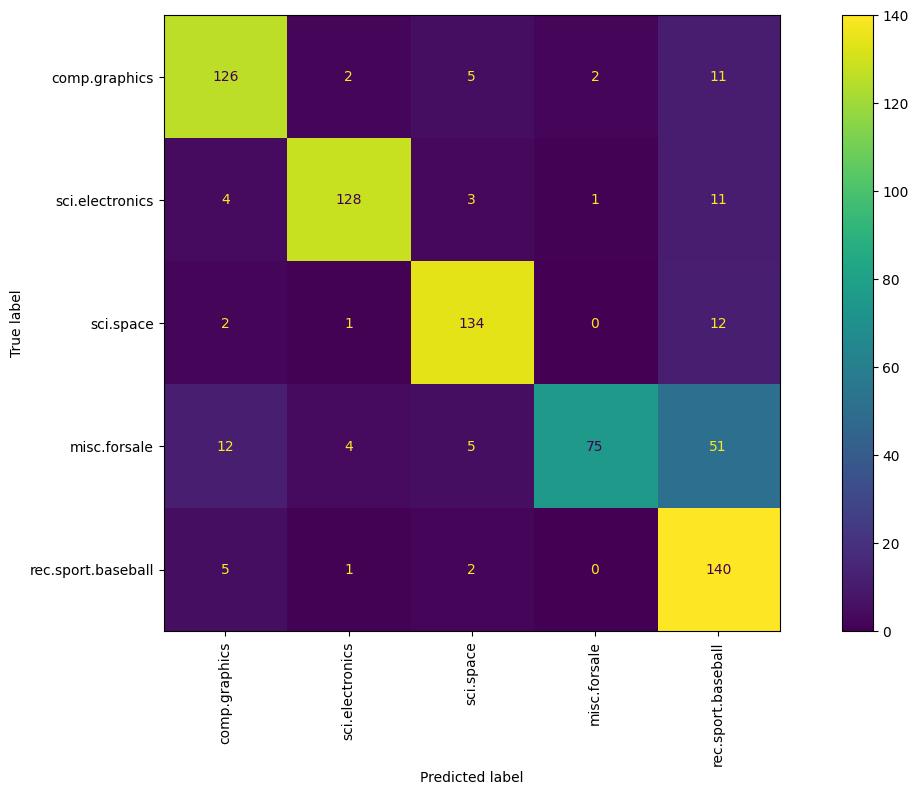

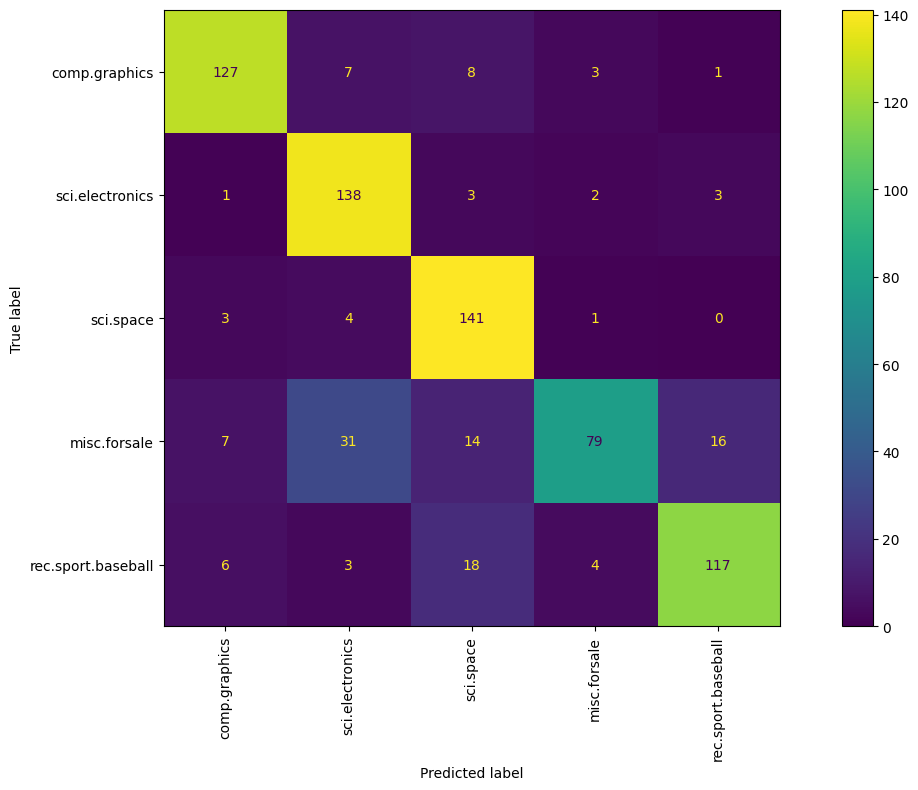

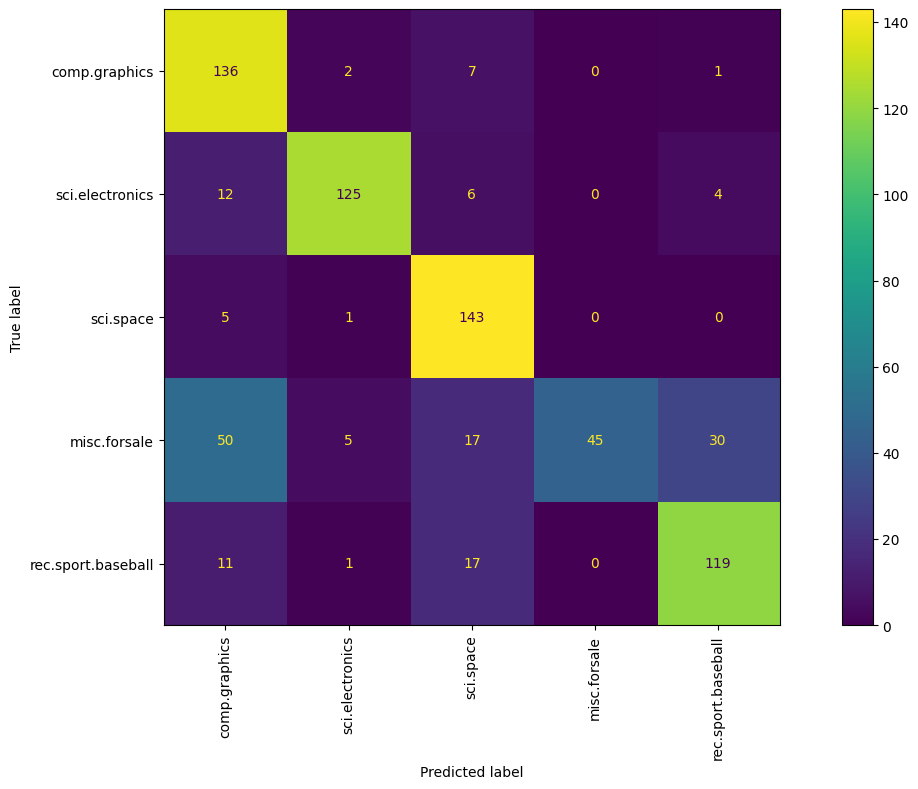

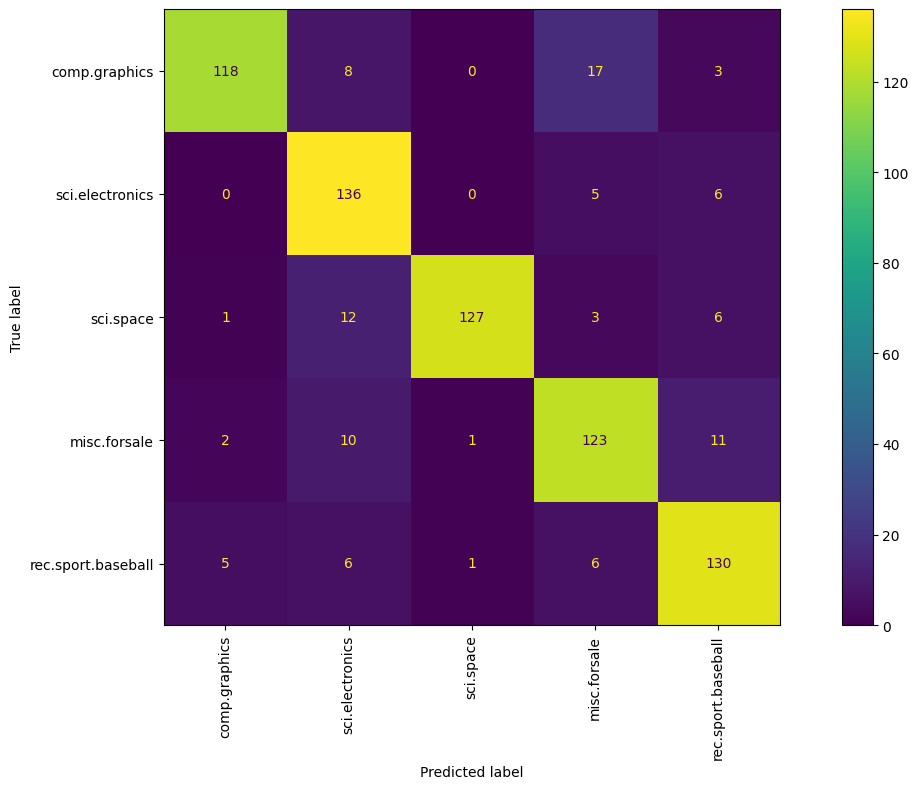

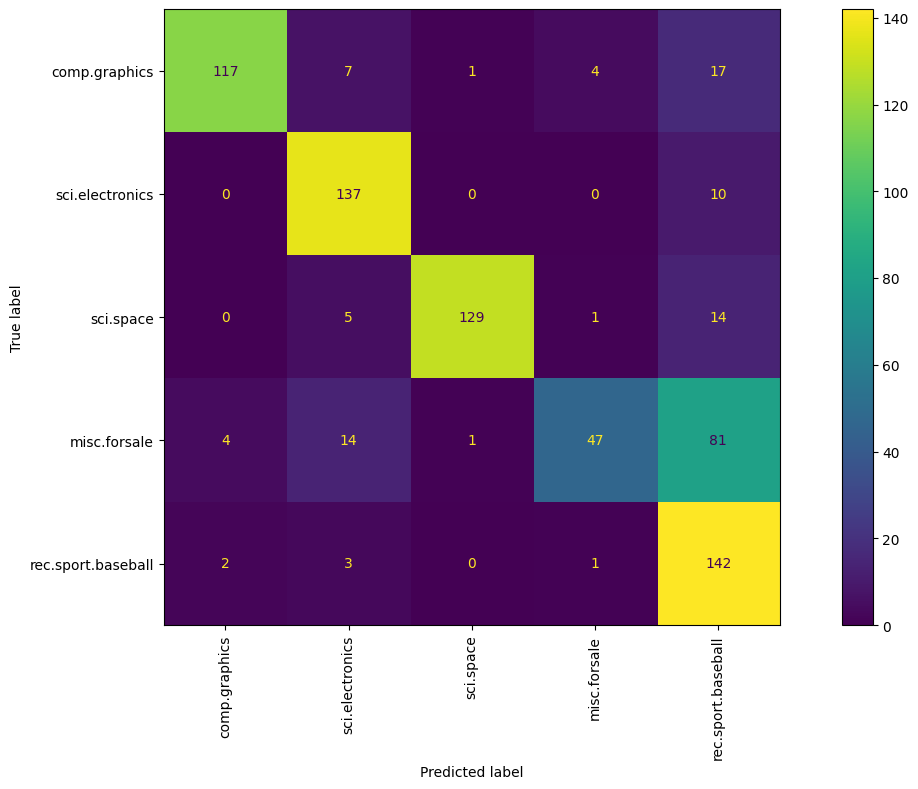

...

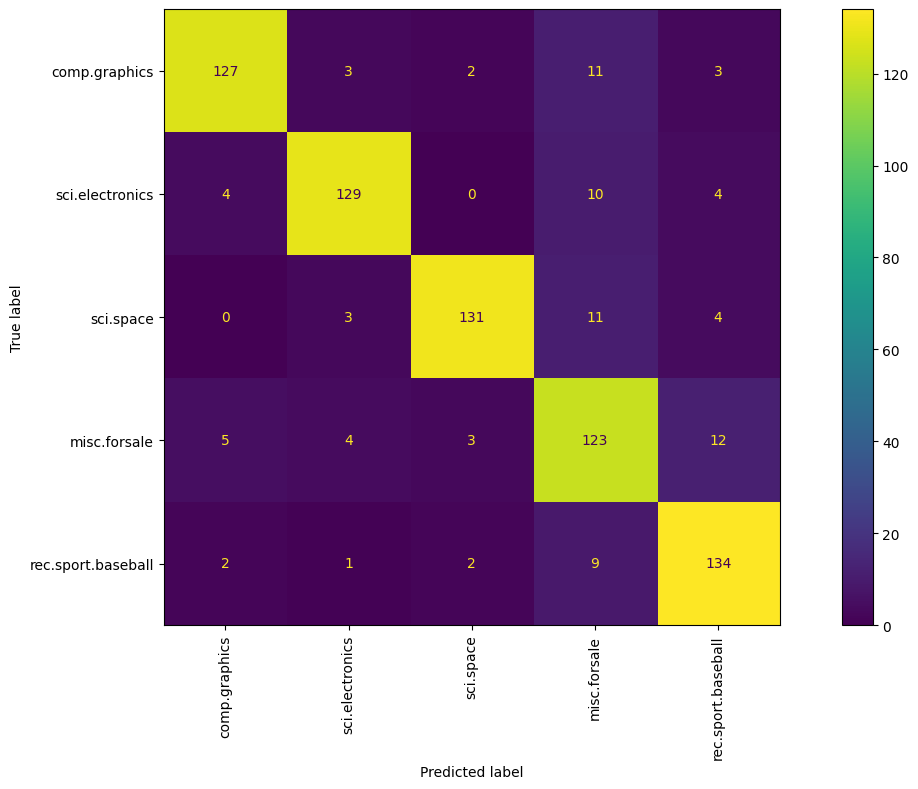

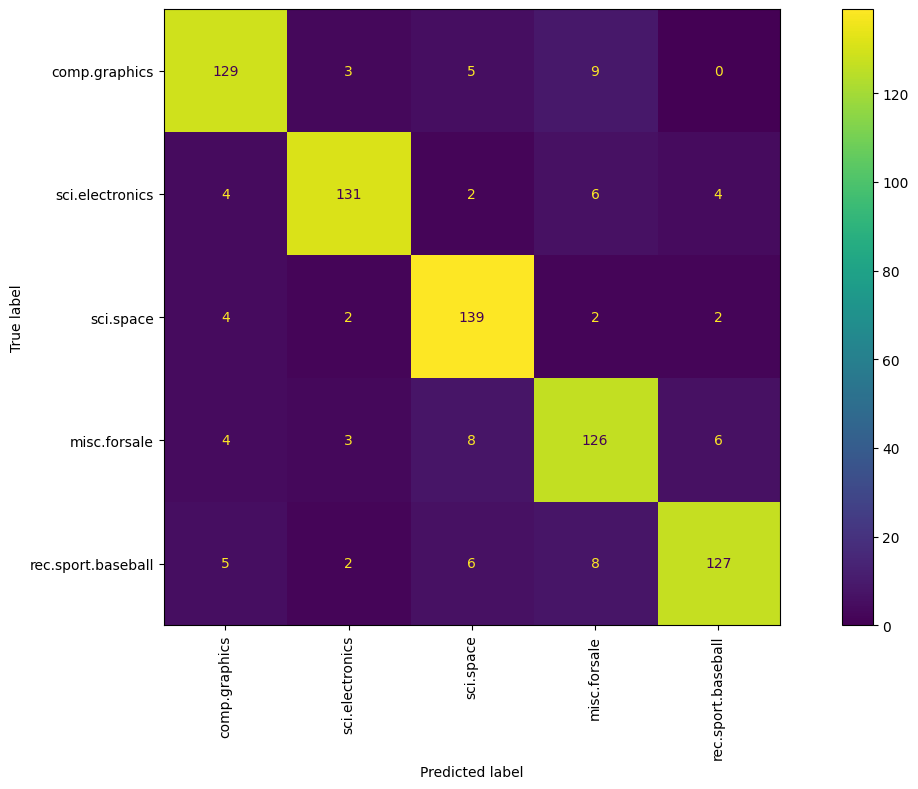

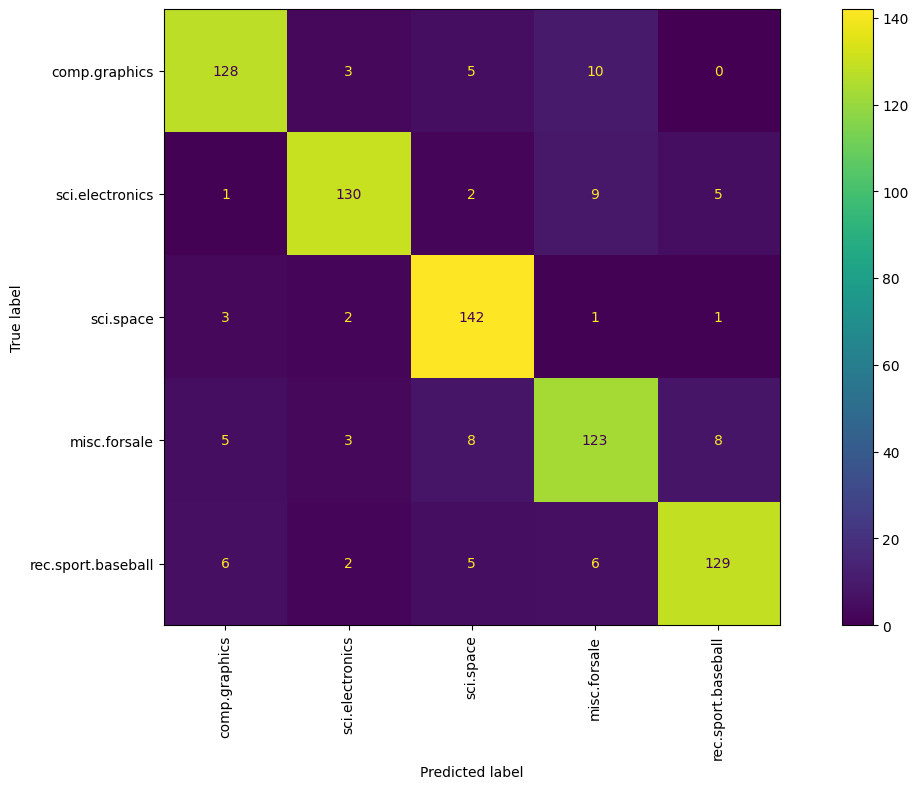

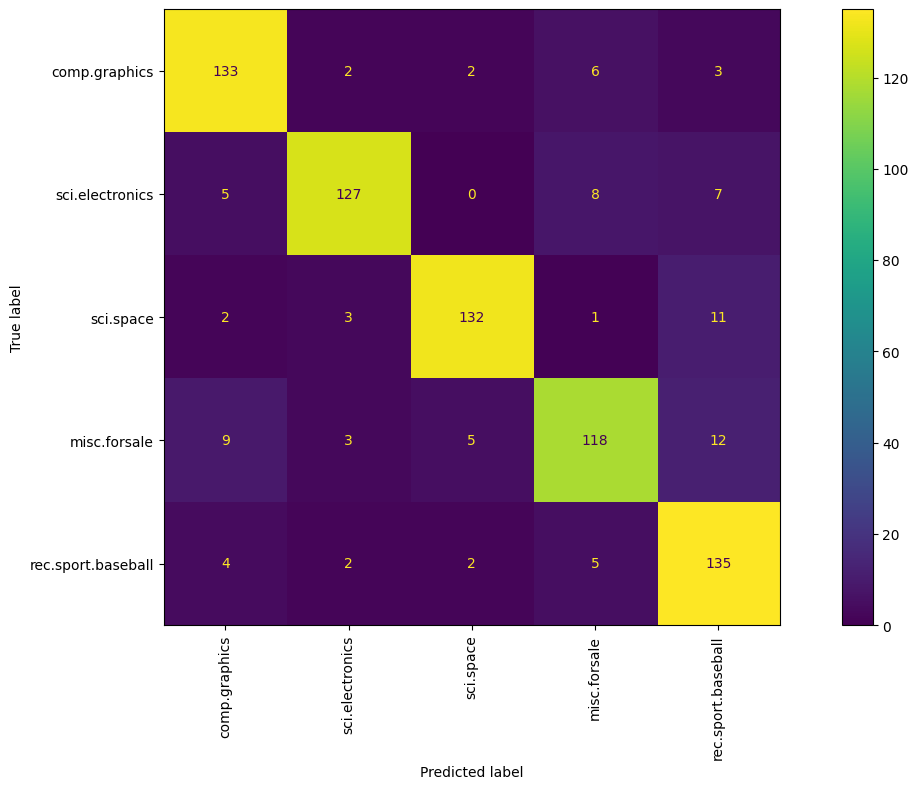

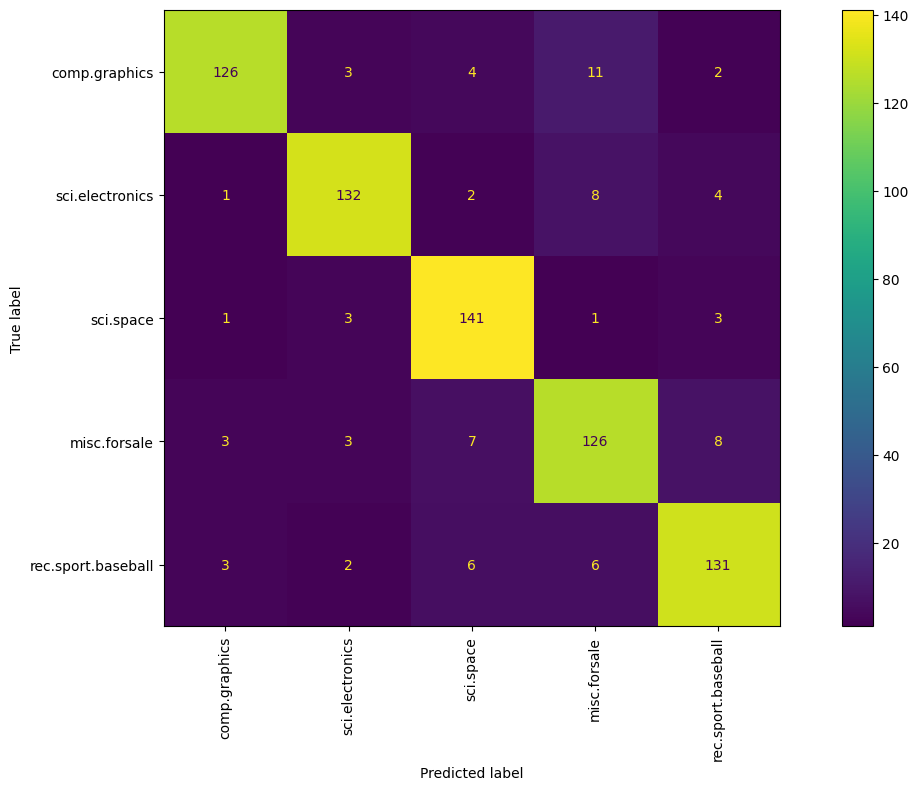

In [ ]:
best_params, results_df = run_hyperparameter_optimization()

In [ ]:
best_params

{'lr': 0.001,
 'batch_size': 32,
 'hidden_dims': [512, 256],
 'dropout_rates': [0.6, 0.4],
 'weight_decay': 0.0001}

In [ ]:
# Convert best_params to a string for comparison
best_params_str = str(best_params)

# Filter results_df to find the row with best parameters
best_row = results_df[results_df['params'] == best_params_str]

# Extract val_accuracy from the 'val_accuracy' column of the best_row
val_accuracy = best_row['val_accuracy'].values[0]

print(f"Validation accuracy for best parameters: {val_accuracy}")

Validation accuracy for best parameters: 0.9114583333333334


# Task 2: Train a neural network on the spam detection dataset

In this task you will gain experience using neural networks in PyTorch for binary classification tasks. This will require making minor edits to the code we've put together in class (copied above). To get us started, the following cells will download the `spambase` dataset from UCI ML Repo:

## Dataset Prep

In [ ]:
!pip install ucimlrepo --quiet

In [ ]:
from ucimlrepo import fetch_ucirepo

spambase = fetch_ucirepo(id=94)
X = spambase.data.features
y = spambase.data.targets

Now, do what you need to do in order to get the data ready for the model. This can include, but isn't limited to, splitting, cleaning, and preprocessing the dataset. You can use the `TensorDataset` class in order to turn your data into a PyTorch Dataset ready to be used with PyTorch DataLoaders.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Check for missing values
print("Missing values in features:", X.isna().sum().sum())  # Verify data cleanliness
print("Missing values in targets:", y.isna().sum().sum())

# Step 1: Convert features and labels to NumPy arrays (if not already)
X = X.values  # Convert pandas DataFrame to NumPy array
y = y.values.ravel()  # Flatten to shape (n_samples,)

# Step 2: Split the data into train (80%), val (10%), test (10%)
# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: val vs test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Step 3: Standardize the features to have mean=0 and std=1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 4: Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Step 5: Wrap tensors in TensorDataset
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

# Step 6: Create DataLoaders for batching
batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size)
test_dl = DataLoader(test_ds, batch_size=batch_size)

Missing values in features: 0
Missing values in targets: 0


Describe any preprocessing you do to the dataset and why:

**I first looked at the data, checked for missing values, converted features to np arrays. Split the data 80 - 10 - 10 , standardized the features for neural network training. Then converted np arrays to tensors and then wrapped them into TensorDataset. Lastly I created a dataloader with batch size 32.**

## Understanding Binary Classification Tasks

Now that we have our dataset prepared and ready to go we are ready to train the model. But not so fast! This task is a binary classification task and the code we've written above is designed primarily for multiclass classification tasks. We will need to make a small edit to our code in order for it to work as expected: anywhere where we compute accuracy metrics needs to be updated in order to account for the difference in the outputs for binary vs multiclass classification.

Let's build up understanding step by step. First, create a model for the binary classification task:

In [ ]:
class SpamClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpamClassifier(input_dim=X.shape[1])
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

How many outputs does your model have, and why? (Hint: the answer should not be 2).

**The model only has 1 output because it is a binary classification task, it only predicts 1 or 0.**

Now, take the first batch and send it through your model to get the logits. What do these logits represent?

In [ ]:
# Get the first batch from the train DataLoader
X_batch, y_batch = next(iter(train_dl))

# Send model to correct device
model = model.to(device)
X_batch = X_batch.to(device)

# Get logits from model
logits = model(X_batch)

print(logits[:5])  # Print first 5 logits

tensor([[-0.6121],
        [-0.1193],
        [-0.2817],
        [-0.2177],
        [ 0.0293]], device='cuda:0', grad_fn=<SliceBackward0>)


**Logits are raw, unnormalized scores output by the model, Those numbers represents the strength and direction of the model’s prediction before applying any activation function**

In order to compare our model predictions to our labels, we follow the same process as in Logistic Regression. Namely, we can use the sigmoid function to map the logits into probability estimates and threshold the results. Use this process in order to turn your logits into predicted class labels for the first batch:

Note, if you threshold probability estaimtes at a level of 0.5, then `sigmoid(logits) > 0.5` is equivalent to `logits > 0` (why?), and you could use either approach to get predicted labels.

**because logits are the raw unnormalized scores. **


In [ ]:
# Option 1: Convert logits into probabilities using sigmoid, then threshold
probs = torch.sigmoid(logits)
preds_prob = (probs > 0.6).float()

# Option 2: Use logits directly (since sigmoid(logits) > 0.5  <=> logits > 0)
preds_direct = (logits > 0).float()

# Check if both are equivalent
print(torch.equal(preds_prob, preds_direct))

False


You should now have predicted class labels for the first batch. You can now compare your predicted class labels to the actual class labels and take the mean of the results to get the accuracy for this batch. Do this for the predicted class labels you obtained for the first batch:

In [ ]:
# Step 4: Compute accuracy for the batch
accuracy = (preds_direct == y_batch.to(device).squeeze()).float().mean()
print(f"Accuracy for the first batch: {accuracy.item():.4f}")

Accuracy for the first batch: 0.5547


Now write a function which combines all the steps above to compute accuracy for binary classification task given logits and corresponding labels:

In [ ]:
def binary_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    # Ensure logits are squeezed to match label shape
    logits = logits.squeeze()
    # Convert logits to predicted class labels (0 or 1)
    preds = (logits > 0).float()
    # Compute accuracy
    accuracy = (preds == labels).float().mean()

    return accuracy

The last step to complete this process is to modify the training functions we imported at the beginning of this notebook in order to work with both multiclass and binary classification tasks using the code you just wrote in the last cell.

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def train_step(model, X_batch, y_batch, loss_fn, optimizer):
    model.train()
    logits = model(X_batch).squeeze()  # Make sure shape is (batch_size,)
    loss = loss_fn(logits, y_batch)    # y_batch should be float32
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    with torch.no_grad():
        acc = binary_accuracy(logits, y_batch)
    return loss.item(), acc.item()

def test_step(model, X_batch, y_batch, loss_fn):
    model.eval()
    with torch.no_grad():
        logits = model(X_batch).squeeze()
        loss = loss_fn(logits, y_batch)
        acc = binary_accuracy(logits, y_batch)
    return loss.item(), acc.item()

def train_model(model, device, loss_fn, optimizer, train_dl, val_dl, n_epochs, scheduler=None):
  model.to(device) # send model to gpu or cpu
  losses, val_losses = [], []
  accuracy, val_accuracy = [], []

  for epoch in range(n_epochs):
    epoch_loss, epoch_val_loss = 0.0, 0.0
    epoch_acc, epoch_val_acc = 0.0, 0.0

    for X_batch, y_batch in tqdm(train_dl): # iterate over all batches in the training set
      X_batch, y_batch = X_batch.to(device), y_batch.to(device) # send data batches to gpu or cpu
      loss, acc = train_step(model, X_batch, y_batch, loss_fn, optimizer)
      epoch_loss += loss
      epoch_acc += acc

    losses.append(epoch_loss/len(train_dl))
    accuracy.append(epoch_acc/len(train_dl))

    for X_batch, y_batch in tqdm(val_dl): # iterate over all batches in the test set
      X_batch, y_batch = X_batch.to(device), y_batch.to(device) # send data batches to gpu or cpu
      loss, acc = test_step(model, X_batch, y_batch, loss_fn)
      epoch_val_loss += loss
      epoch_val_acc += acc

    if scheduler is not None:
      scheduler.step()
    val_losses.append(epoch_val_loss/len(val_dl))
    val_accuracy.append(epoch_val_acc/len(val_dl))

    print(f"Epoch {epoch} | train_loss={losses[-1]} | train_acc={accuracy[-1]} | val_loss={val_losses[-1]} | val_acc={val_accuracy[-1]}")
  return losses, val_losses, accuracy, val_accuracy

def plot_loss_curves(loss, val_loss, acc, val_acc, ngram_range=None):
    def create_plot(train_data, val_data, title):
        plt.figure()
        plt.plot(train_data, label='train')
        plt.plot(val_data, label='val')
        plt.title(f'{title} (ngram_range={ngram_range})')
        plt.xlabel('Epoch #')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

    create_plot(loss, val_loss, 'Loss Curves')
    create_plot(acc, val_acc, 'Accuracy Curves')

def evaluate(model, eval_dl, device, class_names=None):
  predictions = []
  groundtruth = []

  with torch.inference_mode():
    for X_batch, y_batch in tqdm(eval_dl):
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      pred_labels = model(X_batch).argmax(dim=-1)
      predictions.extend(pred_labels.float().cpu().numpy())
      groundtruth.extend(y_batch.cpu().numpy())

  print(classification_report(groundtruth, predictions))
  cm = confusion_matrix(groundtruth, predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  fig, ax = plt.subplots(figsize=(16,8))
  disp.plot(ax=ax, xticks_rotation='vertical')

# Modeling

Create and train a neural spam detector on the UCI spambase dataset. Use `nn.BCEWithLogitsLoss()` as your loss function. As a goal, you can aim for somewhere around 95% accuracy (or more 😃).

In [ ]:
# Train
losses, val_losses, acc, val_acc = train_model(
    model, device, loss_fn, optimizer, train_dl, val_dl, n_epochs=50
)

100%|██████████| 15/15 [00:00<00:00, 612.61it/s]


Epoch 0 | train_loss=0.4286953752455504 | train_acc=0.8546195652173914 | val_loss=0.27692373394966124 | val_acc=0.9152777791023254


100%|██████████| 15/15 [00:00<00:00, 356.55it/s]


Epoch 1 | train_loss=0.2511068886388903 | train_acc=0.9217391304347826 | val_loss=0.22731103400389355 | val_acc=0.9298611124356587


100%|██████████| 15/15 [00:00<00:00, 774.16it/s]


Epoch 2 | train_loss=0.20962222088938173 | train_acc=0.9301630434782608 | val_loss=0.2111611838142077 | val_acc=0.9298611124356587


100%|██████████| 15/15 [00:00<00:00, 392.16it/s]


Epoch 3 | train_loss=0.1881237315904835 | train_acc=0.9323369565217391 | val_loss=0.20270700057347615 | val_acc=0.9277777791023254


100%|██████████| 15/15 [00:00<00:00, 506.04it/s]


Epoch 4 | train_loss=0.17880758150764134 | train_acc=0.9380434782608695 | val_loss=0.19816867858171464 | val_acc=0.9256944457689921


100%|██████████| 15/15 [00:00<00:00, 427.45it/s]


Epoch 5 | train_loss=0.1694523161844067 | train_acc=0.9421195652173913 | val_loss=0.1962963821987311 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 186.74it/s]


Epoch 6 | train_loss=0.16242026479347893 | train_acc=0.94375 | val_loss=0.19360719621181488 | val_acc=0.9236111124356587


100%|██████████| 15/15 [00:00<00:00, 382.73it/s]


Epoch 7 | train_loss=0.15971431447112042 | train_acc=0.9451086956521739 | val_loss=0.1934774582584699 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 263.10it/s]


Epoch 8 | train_loss=0.155286549873974 | train_acc=0.9432065217391304 | val_loss=0.1922518586119016 | val_acc=0.9298611124356587


100%|██████████| 15/15 [00:00<00:00, 248.07it/s]


Epoch 9 | train_loss=0.15348317895246588 | train_acc=0.9459239130434782 | val_loss=0.19545714432994524 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 429.30it/s]


Epoch 10 | train_loss=0.14740790510955065 | train_acc=0.9478260869565217 | val_loss=0.18889180769522984 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 276.00it/s]


Epoch 11 | train_loss=0.14845700685096824 | train_acc=0.946195652173913 | val_loss=0.1885958862801393 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 354.20it/s]


Epoch 12 | train_loss=0.14431563155806582 | train_acc=0.9475543478260869 | val_loss=0.19046390155951182 | val_acc=0.9277777791023254


100%|██████████| 15/15 [00:00<00:00, 997.57it/s]


Epoch 13 | train_loss=0.14085510473536408 | train_acc=0.9491847826086957 | val_loss=0.18806495865186054 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 993.38it/s]


Epoch 14 | train_loss=0.13497554572380108 | train_acc=0.9497282608695652 | val_loss=0.1868849461277326 | val_acc=0.9361111124356588


100%|██████████| 15/15 [00:00<00:00, 810.84it/s]


Epoch 15 | train_loss=0.13719017181707466 | train_acc=0.9519021739130434 | val_loss=0.18882975230614343 | val_acc=0.9298611124356587


100%|██████████| 15/15 [00:00<00:00, 933.08it/s]


Epoch 16 | train_loss=0.13451678869516953 | train_acc=0.9502717391304348 | val_loss=0.18460092494885127 | val_acc=0.9354166666666667


100%|██████████| 15/15 [00:00<00:00, 884.80it/s]


Epoch 17 | train_loss=0.13439808027899783 | train_acc=0.9510869565217391 | val_loss=0.18847506617506346 | val_acc=0.9361111124356588


100%|██████████| 15/15 [00:00<00:00, 940.22it/s]


Epoch 18 | train_loss=0.128174204217351 | train_acc=0.9529891304347826 | val_loss=0.1899899368484815 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 786.36it/s]


Epoch 19 | train_loss=0.12845221997603126 | train_acc=0.9524456521739131 | val_loss=0.1891276607910792 | val_acc=0.9354166666666667


100%|██████████| 15/15 [00:00<00:00, 903.56it/s]


Epoch 20 | train_loss=0.1261963379447875 | train_acc=0.9527173913043478 | val_loss=0.1886658233900865 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 953.97it/s]


Epoch 21 | train_loss=0.12442256537792476 | train_acc=0.9540760869565217 | val_loss=0.18823657259345056 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 1026.00it/s]


Epoch 22 | train_loss=0.12205165865952554 | train_acc=0.9551630434782609 | val_loss=0.1881358489394188 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 936.05it/s]


Epoch 23 | train_loss=0.12283575670874637 | train_acc=0.9573369565217391 | val_loss=0.1865338144203027 | val_acc=0.94375


100%|██████████| 15/15 [00:00<00:00, 1030.27it/s]


Epoch 24 | train_loss=0.12007047904898291 | train_acc=0.9570652173913043 | val_loss=0.1885229508082072 | val_acc=0.9340277791023255


100%|██████████| 15/15 [00:00<00:00, 924.28it/s]


Epoch 25 | train_loss=0.12144461176155702 | train_acc=0.9567934782608696 | val_loss=0.19149748260776203 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 1019.77it/s]


Epoch 26 | train_loss=0.11617356154095868 | train_acc=0.9597826086956521 | val_loss=0.18760145207246146 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 934.80it/s]


Epoch 27 | train_loss=0.11408124922410301 | train_acc=0.9581521739130435 | val_loss=0.18700228482484818 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 901.81it/s]


Epoch 28 | train_loss=0.11291243654230367 | train_acc=0.9622282608695653 | val_loss=0.18626484175523123 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 957.90it/s]


Epoch 29 | train_loss=0.1149429148953894 | train_acc=0.9581521739130435 | val_loss=0.18432134985923768 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 1038.14it/s]


Epoch 30 | train_loss=0.11490624629608963 | train_acc=0.9597826086956521 | val_loss=0.18424035062392552 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 999.99it/s]


Epoch 31 | train_loss=0.11163082610329857 | train_acc=0.9603260869565218 | val_loss=0.1891084134578705 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 975.87it/s]


Epoch 32 | train_loss=0.11319904235070166 | train_acc=0.9641304347826087 | val_loss=0.1940757341682911 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 886.96it/s]


Epoch 33 | train_loss=0.10863876418898935 | train_acc=0.9635869565217391 | val_loss=0.18662860095500947 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 858.74it/s]


Epoch 34 | train_loss=0.11151430481315955 | train_acc=0.9622282608695653 | val_loss=0.1916717251141866 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 838.48it/s]


Epoch 35 | train_loss=0.10778072780889014 | train_acc=0.9627717391304348 | val_loss=0.19138423850138983 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 688.39it/s]


Epoch 36 | train_loss=0.10713839995796266 | train_acc=0.9646739130434783 | val_loss=0.19005385761459667 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 715.78it/s]


Epoch 37 | train_loss=0.10563738078850766 | train_acc=0.9646739130434783 | val_loss=0.18668170819679897 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 819.57it/s]


Epoch 38 | train_loss=0.10356147051181482 | train_acc=0.9638586956521739 | val_loss=0.18669644966721535 | val_acc=0.9375


100%|██████████| 15/15 [00:00<00:00, 788.53it/s]


Epoch 39 | train_loss=0.10759178076101386 | train_acc=0.9633152173913043 | val_loss=0.18628811985254287 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 798.35it/s]


Epoch 40 | train_loss=0.10551007135730722 | train_acc=0.9660326086956522 | val_loss=0.1885080377260844 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 919.64it/s]


Epoch 41 | train_loss=0.10208421349525451 | train_acc=0.9638586956521739 | val_loss=0.18623730142911274 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 698.88it/s]


Epoch 42 | train_loss=0.1037579525343102 | train_acc=0.9657608695652173 | val_loss=0.19125305314858754 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 823.60it/s]


Epoch 43 | train_loss=0.1059158311103997 | train_acc=0.9638586956521739 | val_loss=0.193879447132349 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 1081.10it/s]


Epoch 44 | train_loss=0.10088031228793704 | train_acc=0.966304347826087 | val_loss=0.19526955833037693 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 862.59it/s]


Epoch 45 | train_loss=0.1037230615342117 | train_acc=0.9682065217391305 | val_loss=0.18984088947375616 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 1089.71it/s]


Epoch 46 | train_loss=0.10136656255825706 | train_acc=0.9657608695652173 | val_loss=0.19508349299430847 | val_acc=0.9395833333333333


100%|██████████| 15/15 [00:00<00:00, 1111.07it/s]


Epoch 47 | train_loss=0.10036399884392386 | train_acc=0.9641304347826087 | val_loss=0.19328161055843035 | val_acc=0.9416666666666667


100%|██████████| 15/15 [00:00<00:00, 887.68it/s]


Epoch 48 | train_loss=0.10062854726515387 | train_acc=0.9633152173913043 | val_loss=0.1940510352452596 | val_acc=0.9319444457689922


100%|██████████| 15/15 [00:00<00:00, 1026.36it/s]

Epoch 49 | train_loss=0.09935234516211178 | train_acc=0.9668478260869565 | val_loss=0.19277011925975482 | val_acc=0.9375


Once again, plot the loss curves for your training and evaluation runs. What insights do you have from your plots? If you use the information from your plot to readjust anything in the hyperparameters, explain what you did and why.

Remember some of the tools we've learned about in order to combat overfitting: dropout, weight decay, reducing model capacity, etc. I'm most interested here in how you adaptively use some of these tools based on what you observe in your loss curves.

**I tried running this code 5 different times and got very different loss curves on each. This one was one of the best ones with the model getting better and better over time in training and validation.**

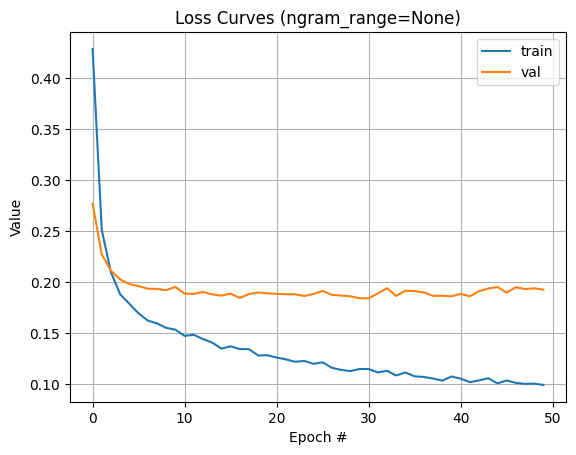

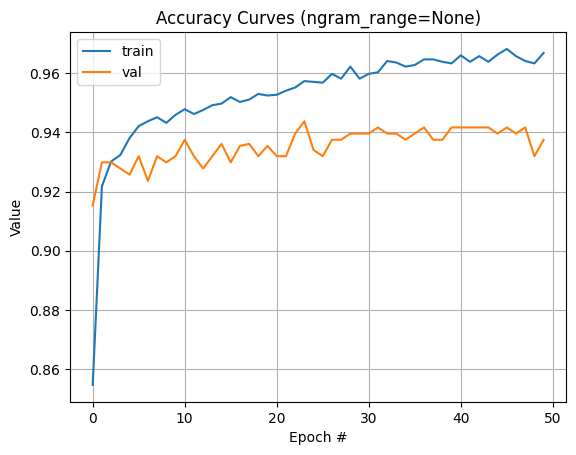

In [ ]:
plot_loss_curves(losses, val_losses, acc, val_acc)

Below is a reference of what you should expect to see in the end:

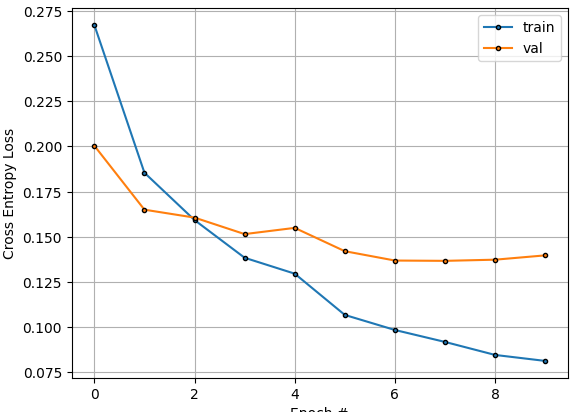

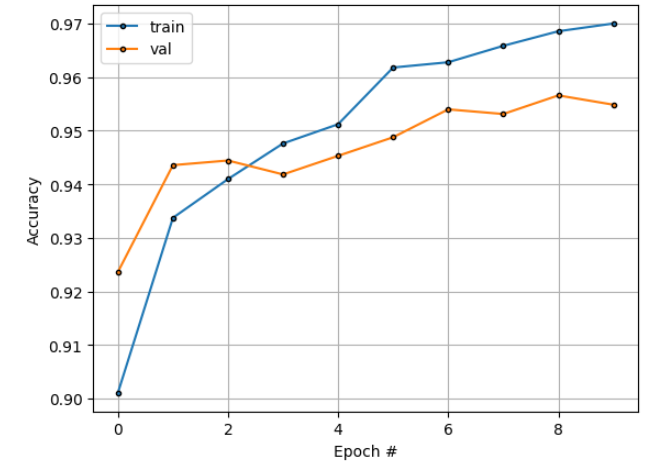

## Evaluation

Once again, evaluate your model using the familiar tools and metrics. Once you are done experimenting, print out and interpet the classification report and confusion matrices for your model on the test set. Where does your model struggle? How would you use this information to improve performance?


 Test Accuracy: 94.36%

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.95      0.96      0.95       279
        Spam       0.94      0.92      0.93       182

    accuracy                           0.94       461
   macro avg       0.94      0.94      0.94       461
weighted avg       0.94      0.94      0.94       461



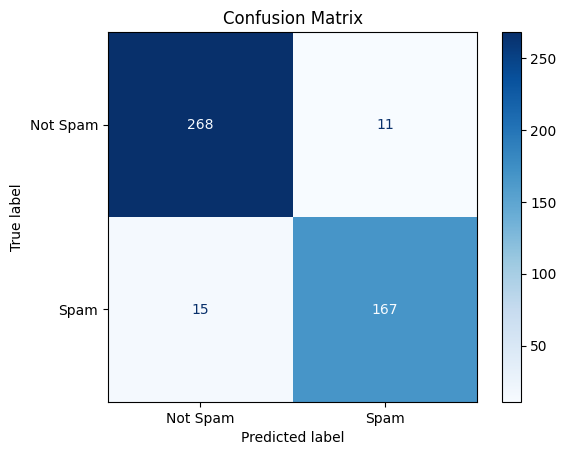

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch).squeeze()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\n Test Accuracy: {accuracy * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["Not Spam", "Spam"]))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    return all_preds, all_labels

all_preds, all_labels = evaluate(model, test_dl, device)

# Task 3: Train a BERT-like model on Natural Disaster Tweets

In this task we will be training a complex BERT-like model to solve the following task: https://www.kaggle.com/competitions/nlp-getting-started.

This task should assure you that the training process for state of the art modern methods is the highly similar to what we've been doing for simpler models. It will also give you more experience working with hugging face datasets and models.

In [ ]:
!pip install datasets --quiet

Download a `DistilBertTokenizer` and `DistilBertForSequenceClassification` model from Hugging Face from the `distilbert-base-uncased` checkpoint.

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(checkpoint)
model = DistilBertForSequenceClassification.from_pretrained(checkpoint, num_labels=1).to(device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Create a summary of the model using torch-summary:

In [ ]:
!pip install transformers torch torchinfo

In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torchinfo import summary

In [ ]:
# Define dummy input for a batch size of 1 and max length of 128
dummy_input = tokenizer(
    "This is a sample input for model summary.",
    return_tensors="pt",
    padding="max_length",
    max_length=128,
    truncation=True
)

# Move input tensors to the same device as the model
dummy_input = {k: v.to(device) for k, v in dummy_input.items()}

In [ ]:
# Now use torchinfo to print the model summary
summary(model, input_data=dummy_input)

Layer (type:depth-idx)                                  Output Shape              Param #
DistilBertForSequenceClassification                     [1, 1]                    --
├─DistilBertModel: 1-1                                  [1, 128, 768]             --
│    └─Embeddings: 2-1                                  [1, 128, 768]             --
│    │    └─Embedding: 3-1                              [1, 128, 768]             23,440,896
│    │    └─Embedding: 3-2                              [1, 128, 768]             393,216
│    │    └─LayerNorm: 3-3                              [1, 128, 768]             1,536
│    │    └─Dropout: 3-4                                [1, 128, 768]             --
│    └─Transformer: 2-2                                 [1, 128, 768]             --
│    │    └─ModuleList: 3-5                             --                        42,527,232
├─Linear: 1-2                                           [1, 768]                  590,592
├─Dropout: 1-3                 

Checkout the model on Hugging Face and write a summary of your findings:

We can create our own Hugging Face datasets from our own data. The following cell creates a `DatasetDict` object which is similar to what you used in lab 1 when training on the airline tweet sentiment data.

In [ ]:
# Check if kaggle.json is present
import os
print(os.listdir())
print(os.path.exists('kaggle.json'))

!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

!kaggle competitions download -c nlp-getting-started

['.config', 'sample_data']
False
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
import pandas as pd

# Read the data directly into pandas from an active GitHub mirror
train_url = "https://raw.githubusercontent.com/sugatagh/Natural-Language-Processing-with-Disaster-Tweets/main/train.csv"
test_url = "https://raw.githubusercontent.com/sugatagh/Natural-Language-Processing-with-Disaster-Tweets/main/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

# Standardize the target column name to 'labels' for Hugging Face compatibility
if 'target' in train_df.columns:
    train_df = train_df.rename(columns={'target': 'labels'})

print(f"Successfully loaded train: {train_df.shape}, test: {test_df.shape}")

Successfully loaded train: (7613, 5), test: (3263, 4)


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# 80/20 train/validation split on train_df so validation data actually exists
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["labels"]
)

tweet_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_split_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_split_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})

Now, prepare your dataset for training. You will need to create a PyTorch dataset for your data. You may find the code from lab 1 airline sentiment data helpful (and highly relevant).

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

#  Tokenize the dataset
MAX_LEN = 128

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

tokenized_datasets = tweet_dataset.map(tokenize_function, batched=True)

# Format all three splits
tokenized_datasets["train"].set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_datasets["validation"].set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_datasets["test"].set_format(type="torch", columns=["input_ids", "attention_mask"])

BATCH_SIZE = 16
train_loader = DataLoader(tokenized_datasets["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized_datasets["validation"], batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=BATCH_SIZE)



Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

Get the first batch from your data loader, and send it through the model:

In [ ]:
# Get the first batch
batch = next(iter(train_loader))

# Move batch to the same device as the model
batch = {k: v.to(device) for k, v in batch.items()}

# Send batch through the model
model.eval()  # Set model to eval mode
with torch.no_grad():
    outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])

# Print the output logits
print("Output logits:", outputs.logits)

Output logits: tensor([[-0.0119],
        [-0.0008],
        [-0.0110],
        [-0.0286],
        [-0.0334],
        [-0.0270],
        [-0.0164],
        [-0.0017],
        [-0.0523],
        [-0.0097],
        [-0.0287],
        [ 0.0068],
        [-0.0239],
        [-0.0064],
        [-0.0314],
        [ 0.0053]], device='cuda:0')


Modify the training code that we've been developing in order for it to work with your dataset. I would recommend at first only training for a couple of epochs. Also, GPU is *highly* recommended.

In [ ]:
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modified binary accuracy calculation
def binary_accuracy(logits, y_true):
    y_pred = torch.sigmoid(logits) > 0.5
    return (y_pred.float() == y_true).float().mean()

# Modified train_step
def train_step(model, batch, loss_fn, optimizer):
    model.train()
    inputs = {
        "input_ids": batch["input_ids"],
        "attention_mask": batch["attention_mask"]
    }
    labels = batch["labels"].float()  # BCEWithLogitsLoss expects float targets

    logits = model(**inputs).logits.squeeze()  # (batch_size,)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    acc = binary_accuracy(logits.detach(), labels)
    return loss.item(), acc.item()

# Modified test_step
def test_step(model, batch, loss_fn):
    model.eval()
    with torch.no_grad():
        inputs = {
            "input_ids": batch["input_ids"],
            "attention_mask": batch["attention_mask"]
        }
        labels = batch["labels"].float()

        logits = model(**inputs).logits.squeeze()
        loss = loss_fn(logits, labels)
        acc = binary_accuracy(logits, labels)
    return loss.item(), acc.item()

# Modified train_model function
def train_model(model, device, loss_fn, optimizer, train_dl, val_dl, n_epochs, scheduler=None):
    model.to(device)
    losses, val_losses = [], []
    accuracy, val_accuracy = [], []

    for epoch in range(n_epochs):
        # Training phase
        model.train()
        epoch_loss, epoch_acc = 0.0, 0.0
        for batch in tqdm(train_dl, desc=f"Training Epoch {epoch}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            loss, acc = train_step(model, batch, loss_fn, optimizer)
            epoch_loss += loss
            epoch_acc += acc

        # Validation phase
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        for batch in tqdm(val_dl, desc=f"Validating Epoch {epoch}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            loss, acc = test_step(model, batch, loss_fn)
            val_loss += loss
            val_acc += acc

        # Record metrics
        train_loss = epoch_loss / len(train_dl)
        train_acc = epoch_acc / len(train_dl)
        valid_loss = val_loss / len(val_dl)
        valid_acc = val_acc / len(val_dl)

        losses.append(train_loss)
        accuracy.append(train_acc)
        val_losses.append(valid_loss)
        val_accuracy.append(valid_acc)

        if scheduler:
            scheduler.step(valid_loss)

        print(f"Epoch {epoch+1}/{n_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {valid_loss:.4f} | Val Acc: {valid_acc:.4f}\n")

    return losses, val_losses, accuracy, val_accuracy

# Modified evaluate function
def evaluate(model, eval_dl, device, class_names=["Not Disaster", "Disaster"]):
    model.eval()
    predictions = []
    groundtruth = []

    with torch.no_grad():
        for batch in tqdm(eval_dl, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            inputs = {
                "input_ids": batch["input_ids"],
                "attention_mask": batch["attention_mask"]
            }
            logits = model(**inputs).logits.squeeze()
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()

            predictions.extend(preds)
            groundtruth.extend(batch["labels"].cpu().numpy())

    print(classification_report(groundtruth, predictions, target_names=class_names))

    cm = confusion_matrix(groundtruth, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, xticks_rotation='vertical')
    plt.show()

# Initialize training components
EPOCHS = 3
LEARNING_RATE = 2e-5

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Run training
losses, val_losses, acc, val_acc = train_model(
    model=model,
    device=device,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_dl=train_loader,
    val_dl=val_loader,
    n_epochs=EPOCHS
)


Validating Epoch 0: 100%|██████████| 96/96 [00:06<00:00, 15.43it/s]


Epoch 1/3
Train Loss: 0.4455 | Train Acc: 0.8107
Val Loss: 0.3997 | Val Acc: 0.8416



Validating Epoch 1: 100%|██████████| 96/96 [00:06<00:00, 15.46it/s]


Epoch 2/3
Train Loss: 0.3295 | Train Acc: 0.8695
Val Loss: 0.3705 | Val Acc: 0.8483



Validating Epoch 2: 100%|██████████| 96/96 [00:06<00:00, 15.34it/s]

Epoch 3/3
Train Loss: 0.2471 | Train Acc: 0.9078
Val Loss: 0.4353 | Val Acc: 0.8279



Plot learning curves, interpret them, and summarize your findings:

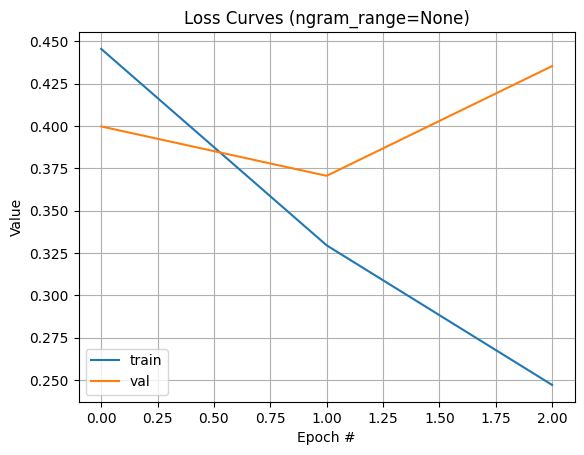

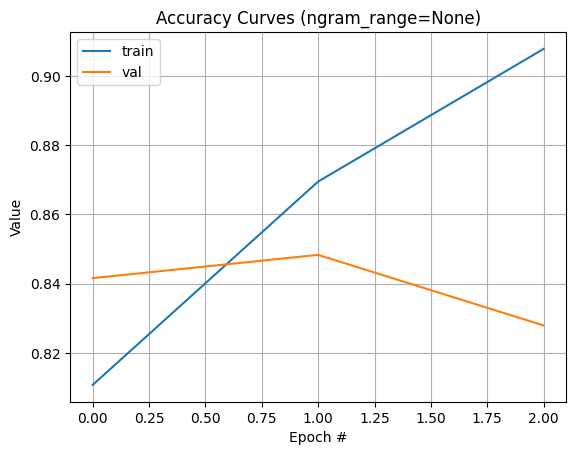

In [ ]:
plot_loss_curves(losses, val_losses, acc, val_acc)

Evaluate your model using the same set of tools as before:

In [ ]:
def evaluate(model, eval_dl, device, class_names=["Not Disaster", "Disaster"]):
    model.eval()
    predictions = []
    groundtruth = []

    with torch.inference_mode():
        for batch in tqdm(eval_dl, desc="Evaluating"): # Iterate through the DataLoader
            batch = {k: v.to(device) for k, v in batch.items()} # Move batch to device
            inputs = {                                          # Prepare inputs for the model
                "input_ids": batch["input_ids"],
                "attention_mask": batch["attention_mask"]
            }
            logits = model(**inputs).logits.squeeze()          # Get model predictions
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy() # Get predicted labels

            predictions.extend(preds)                           # Store predictions
            groundtruth.extend(batch["labels"].cpu().numpy())   # Store actual labels

    print(classification_report(groundtruth, predictions, target_names=class_names))

    cm = confusion_matrix(groundtruth, predictions)            # Create confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names) # Display confusion matrix
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, xticks_rotation='vertical')
    plt.show()

Evaluating: 100%|██████████| 96/96 [00:06<00:00, 15.42it/s]


              precision    recall  f1-score   support

Not Disaster       0.85      0.85      0.85       869
    Disaster       0.80      0.80      0.80       654

    accuracy                           0.83      1523
   macro avg       0.83      0.83      0.83      1523
weighted avg       0.83      0.83      0.83      1523



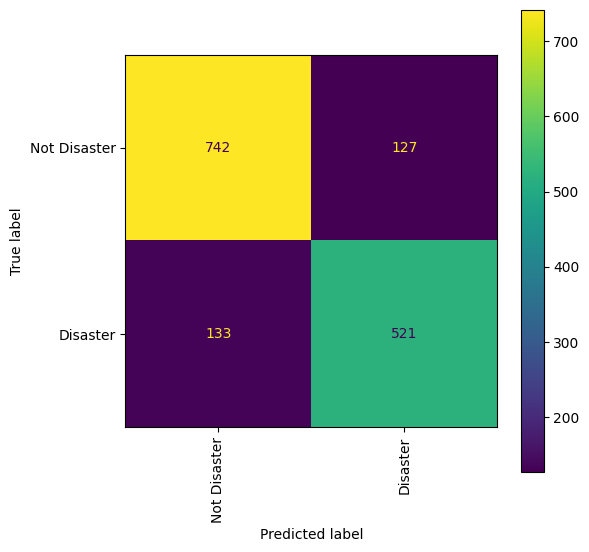

In [ ]:
evaluate(model, val_loader, device)

# Task 4: Exploring Word Vectors

This task is more exploratory and applied in nature than the others. Instead of training a neural net from scratch in order to learn word embeddings as we did in class, in this task I want you to explore some *properties* of word vectors using an implementation of Word2Vec implemented in the `gensim` package.

For this task, I want you to follow through Sections 2 and 3 of the guided tutorial provided [here](https://www.kaggle.com/competitions/word2vec-nlp-tutorial), but use the natural disaster tweets datasets instead of the dataset provided in the tutorial. Note part 1 of this tutorial is focused on other vectorization schemes and can be skipped.

In [ ]:
!pip install --upgrade gensim

In [ ]:
import pandas as pd
import os
import nltk
import logging
import numpy as np
import re
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Custom preprocessing utility for tweets
class TweetPreprocessor:
    @staticmethod
    def tweet_to_wordlist(tweet, remove_stopwords=False):
       # Clean and split a tweet into words
        # Basic cleaning
        tweet = tweet.lower()
        tweet = re.sub(r"http\S+", "", tweet)  # Remove URLs
        tweet = re.sub(r"@\w+", "", tweet)     # Remove mentions
        tweet = re.sub(r"#", "", tweet)        # Remove hashtags but keep text
        tweet = re.sub(r"[^a-z0-9]", " ", tweet)  # Remove special chars

        words = tweet.split()
        if remove_stopwords:
            stops = set(stopwords.words("english"))
            words = [w for w in words if w not in stops]
        return words

    @staticmethod
    def tweet_to_sentences(tweet, tokenizer):
      #  Split tweet into sentences (though tweets are often single sentences)
        raw_sentences = tokenizer.tokenize(tweet.strip())
        return [TweetPreprocessor.tweet_to_wordlist(sent) for sent in raw_sentences]

def makeFeatureVec(words, model, num_features):
    featureVec = np.zeros((num_features,), dtype="float32")
    nwords = 0.
    index2word_set = set(model.wv.index_to_key)

    for word in words:
        if word in index2word_set:
            nwords += 1
            featureVec = np.add(featureVec, model.wv[word])

    if nwords > 0:
        featureVec = np.divide(featureVec, nwords)
    return featureVec

def getAvgFeatureVecs(reviews, model, num_features):
    reviewFeatureVecs = np.zeros((len(reviews), num_features), dtype="float32")
    for i, review in enumerate(reviews):
        if i % 1000 == 0:
            print(f"Review {i} of {len(reviews)}")
        reviewFeatureVecs[i] = makeFeatureVec(review, model, num_features)
    return reviewFeatureVecs

if __name__ == '__main__':
    # Load disaster tweets dataset directly from the working GitHub mirror
    train_url = "https://raw.githubusercontent.com/sugatagh/Natural-Language-Processing-with-Disaster-Tweets/main/train.csv"
    test_url = "https://raw.githubusercontent.com/sugatagh/Natural-Language-Processing-with-Disaster-Tweets/main/test.csv"

    train_df = pd.read_csv(train_url)
    test_df = pd.read_csv(test_url)

    # Split into training and validation
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df["text"],
        train_df["target"],
        test_size=0.2,
        random_state=42
    )

    # Prepare sentences for Word2Vec training
    tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')
    sentences = []

    print("Parsing sentences from training set")
    for tweet in train_texts:
        sentences += TweetPreprocessor.tweet_to_sentences(tweet, tokenizer)

    # Configure and train Word2Vec
    logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

    # Hyperparameters optimized for tweets
    num_features = 200    # Reduced from 300 for shorter texts
    min_word_count = 10   # Lower due to smaller tweet vocabulary
    context = 5           # Smaller window for short messages
    downsampling = 1e-3

    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences,
        vector_size=num_features,
        min_count=min_word_count,
        window=context,
        sample=downsampling,
        workers=os.cpu_count(),
        sg=1,            # Use skip-gram (better for smaller datasets)
        hs=0             # Use negative sampling
    )

    # Prepare features
    print("Creating feature vectors...")
    train_clean = [TweetPreprocessor.tweet_to_wordlist(tweet, True) for tweet in train_texts]
    val_clean = [TweetPreprocessor.tweet_to_wordlist(tweet, True) for tweet in val_texts]

    train_vecs = getAvgFeatureVecs(train_clean, model, num_features)
    val_vecs = getAvgFeatureVecs(val_clean, model, num_features)

    # Train classifier
    print("Training classifier...")
    forest = RandomForestClassifier(
        n_estimators=200,
        max_depth=50,
        class_weight='balanced',
        random_state=42
    )

    forest.fit(train_vecs, train_labels)
    print(f"Validation accuracy: {forest.score(val_vecs, val_labels):.2f}")

    # Save model
    model.save("disaster_tweets_word2vec.model")

    # Example usage
    print("\nSimilar words to 'fire':")
    print(model.wv.most_similar('fire', topn=5))

    print("\nSimilar words to 'flood':")
    print(model.wv.most_similar('flood', topn=5))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Parsing sentences from training set
Training Word2Vec model...
Creating feature vectors...
Review 0 of 6090
Review 1000 of 6090
Review 2000 of 6090
Review 3000 of 6090
Review 4000 of 6090
Review 5000 of 6090
Review 6000 of 6090
Review 0 of 1523
Review 1000 of 1523
Training classifier...
Validation accuracy: 0.75

Similar words to 'fire':
[('truck', 0.9584400057792664), ('forest', 0.954322874546051), ('on', 0.9540384411811829), ('national', 0.9527115821838379), ('road', 0.9477991461753845)]

Similar words to 'flood':
[('county', 0.9931162595748901), ('issued', 0.9929879903793335), ('7', 0.9917765259742737), ('cdt', 0.9913991689682007), ('thunderstorm', 0.9910502433776855)]


Training Word2Vec model...


Epoch 1/10 - Loss: 380723.41


Epoch 2/10 - Loss: -127557.30


Epoch 3/10 - Loss: 31786.98


Epoch 4/10 - Loss: -6020.53


Epoch 5/10 - Loss: -6030.88


Epoch 6/10 - Loss: -10934.97


Epoch 7/10 - Loss: -6619.17


Epoch 8/10 - Loss: -9879.55


Epoch 9/10 - Loss: -2372.72
Epoch 10/10 - Loss: -6213.67


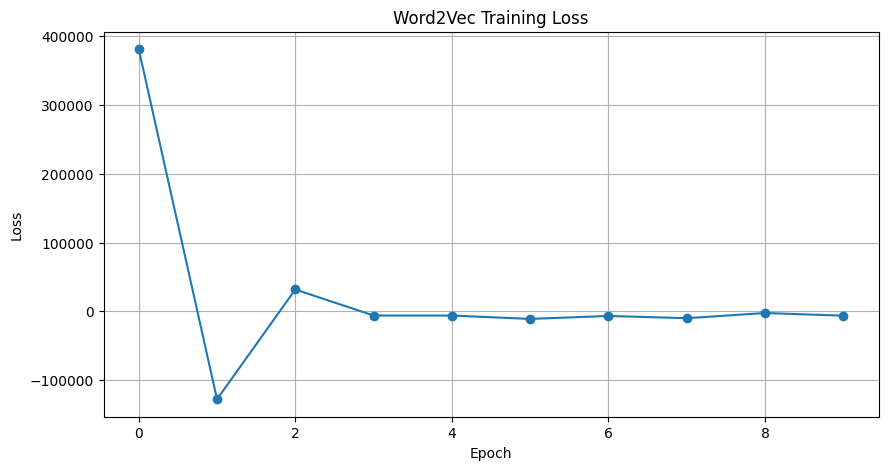


Training Random Forest...

Validation Set Evaluation:
Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.76      0.83      0.79       874
    Disaster       0.74      0.64      0.68       649

    accuracy                           0.75      1523
   macro avg       0.75      0.74      0.74      1523
weighted avg       0.75      0.75      0.75      1523



<Figure size 600x600 with 0 Axes>

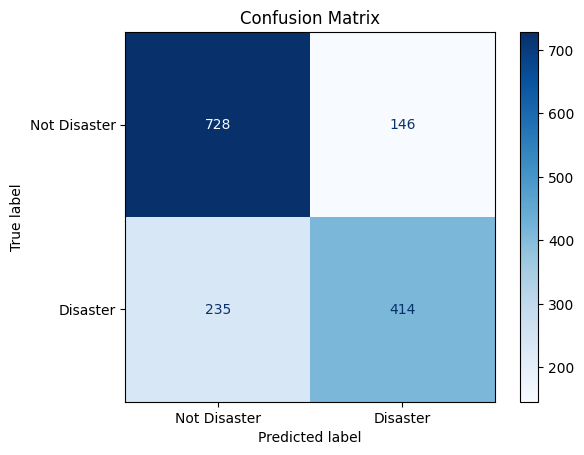

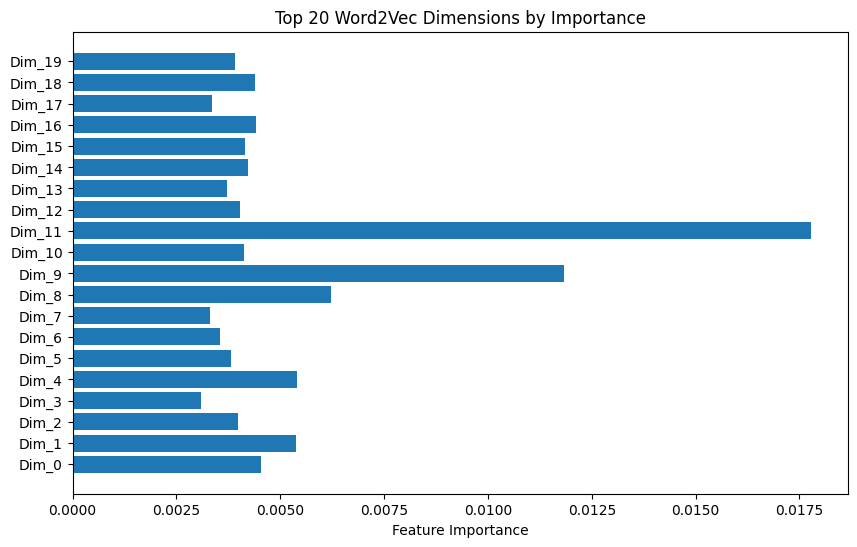

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_word2vec_training_loss(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(losses, marker='o')
    plt.title("Word2Vec Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

def evaluate_classifier(model, X_val, y_val):
    # Generate predictions
    y_pred = model.predict(X_val)

    # Classification report
    print("Classification Report:")
    print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Not Disaster', 'Disaster'])
    plt.figure(figsize=(6,6))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

if __name__ == '__main__':

    # Modified Word2Vec training with loss tracking
    epochs = 10
    losses = []

    print("Training Word2Vec model...")
    model = Word2Vec(
        vector_size=num_features,
        min_count=min_word_count,
        window=context,
        sample=downsampling,
        workers=os.cpu_count(),
        sg=1,
        hs=0,
        compute_loss=True,  # Enable loss computation
        epochs=1  # Start with 1 epoch
    )

    model.build_vocab(sentences)
    previous_loss = 0

    for epoch in range(epochs):
        model.train(
            sentences,
            total_examples=model.corpus_count,
            epochs=1,
            compute_loss=True
        )
        current_loss = model.get_latest_training_loss()
        epoch_loss = current_loss - previous_loss
        losses.append(epoch_loss)
        previous_loss = current_loss
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.2f}")

    # Plot Word2Vec training loss
    plot_word2vec_training_loss(losses)

    # Train Random Forest with validation curve
    print("\nTraining Random Forest...")
    forest = RandomForestClassifier(
        n_estimators=200,
        max_depth=50,
        class_weight='balanced',
        random_state=42
    )

    forest.fit(train_vecs, train_labels)

    # Evaluate on validation set
    print("\nValidation Set Evaluation:")
    evaluate_classifier(forest, val_vecs, val_labels)

    # Plot feature importance (optional)
    plt.figure(figsize=(10, 6))
    plt.barh(range(20), forest.feature_importances_[:20], align='center')
    plt.yticks(range(20), [f"Dim_{i}" for i in range(20)])
    plt.xlabel("Feature Importance")
    plt.title("Top 20 Word2Vec Dimensions by Importance")
    plt.show()


# Task 5: Implement Bengio et al. (2003) model

In this task, you will be reproducing the model introduced in [Bengio et. al (2003)](https://jmlr.org/papers/volume3/bengio03a/bengio03a.pdf) . This is an important paper in the history of Natural Language Processing and the ideas influence later works such as Word2Vec and modern neural network based language models.

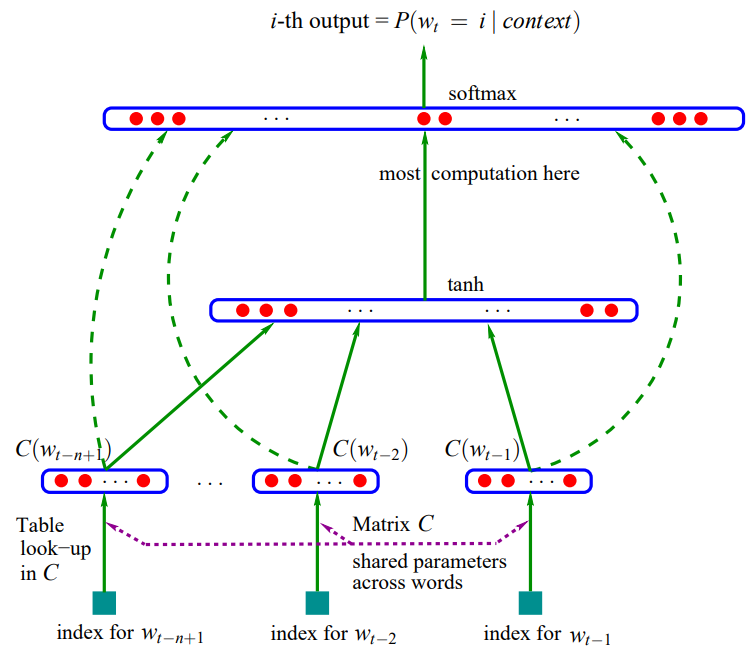

The goal of this task is to give you more hands-on experience building your own models with PyTorch as well as to introduce you to the art and skill of [reading](https://www.youtube.com/watch?v=733m6qBH-jI) and [replicating research papers](https://www.learnpytorch.io/08_pytorch_paper_replicating/).

Your task is to recreate the core model architecture, experiment with modern techniques for optimization (e.g., learning rate scheduling), and explore improvements using innovations from contemporary deep learning practices.

Use either one of the corpuses mentioned in the paper as your data source. Tokenize and encode the corpus, and then create a PyTorch dataset consisting of `(context, next_word)` pairs. For example, if your context window length is `3`, then one sample might be `([123, 78, 461], [82])` where the first entry in the tuple are the token id's for the three context tokens/words and the second entry in the tuple is the target, that is, the token id of the following word.

Note: check out section 4 of the paper for some comments on how the authors formed their datasets and dataset splits.

In [ ]:
import nltk
from nltk.corpus import brown
import torch
from torch.utils.data import Dataset
import numpy as np

# Ensure the Brown Corpus is downloaded
nltk.download('brown')

# Get the Brown Corpus
corpus = brown.words()

# Create a vocabulary and encode the corpus
vocab = set(corpus)
vocab_size = len(vocab)
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

encoded_corpus = [word_to_idx[word] for word in corpus]

class LanguageModelDataset(Dataset):
    def __init__(self, encoded_corpus, context_size):
        self.encoded_corpus = encoded_corpus
        self.context_size = context_size

    def __len__(self):
        return len(self.encoded_corpus) - self.context_size

    def __getitem__(self, idx):
        context = torch.tensor(self.encoded_corpus[idx:idx + self.context_size])
        next_word = torch.tensor(self.encoded_corpus[idx + self.context_size])
        return context, next_word

# Set the context size
context_size = 3
batch_size = 32

# Create the dataset
dataset = LanguageModelDataset(encoded_corpus, context_size)

# Test the dataset
print(dataset[0])


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


(tensor([10280, 46004, 11312]), tensor(39673))


Create a dataloader for your dataset. Pull out the first batch of your dataset and inspect its properties.

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Pull out the first batch
batch = next(iter(dataloader))

# Inspect the properties of the batch
print("Batch shape:")
print("Context:", batch[0].shape)
print("Next word:", batch[1].shape)

print("\nBatch data type:")
print("Context:", batch[0].dtype)
print("Next word:", batch[1].dtype)

print("\nExample data from the batch:")
print("Context:", batch[0][:5])
print("Next word:", batch[1][:5])

Batch shape:
Context: torch.Size([32, 3])
Next word: torch.Size([32])

Batch data type:
Context: torch.int64
Next word: torch.int64

Example data from the batch:
Context: tensor([[20703, 46252, 15006],
        [28111, 22115, 28121],
        [51154, 16329, 52573],
        [25010, 27494, 32216],
        [ 3250,  6757,   537]])
Next word: tensor([54582, 37525,  8837, 45895, 25862])


## Modeling

Create the neural network architecture as shown in Figure 1 of the paper using PyTorch. Make sure to include an optional parameter for the skip connections in the model. The corresponding computations for the skip connections should only be performed if the optional parameter is set to `True`. Use an `nn.Embedding` layer for the `C` matrix (also called "table look-up" in the paper). Note that the matrix `C` is shared across all context words.

*Hint*: You can use the `.view()` method on the output of the embedding layer to concatenate the embeddings for each context word together.

In [ ]:
import torch.nn as nn

class NeuralProbabilisticLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, context_size, direct_connections=False):
        super(NeuralProbabilisticLanguageModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.context_size = context_size
        self.direct_connections = direct_connections

        # Input to hidden layer weights
        self.hidden_layer = nn.Linear(context_size * embedding_dim, hidden_dim)

        # Hidden layer bias
        self.hidden_bias = nn.Parameter(torch.zeros(hidden_dim))

        # Hidden to output layer weights
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

        # Output layer bias
        self.output_bias = nn.Parameter(torch.zeros(vocab_size))

        if direct_connections:
            # Word features to output weights
            self.direct_output_layer = nn.Linear(context_size * embedding_dim, vocab_size, bias=False)

    def forward(self, context):
        # Get the embeddings for the context words
        embeddings = self.embedding(context)

        # Concatenate the embeddings together
        x = embeddings.view(-1, self.context_size * embeddings.size(-1))

        # Compute the hidden layer activations
        hidden_activations = torch.tanh(self.hidden_bias + self.hidden_layer(x))

        # Compute the output layer activations
        output_activations = self.output_bias + self.output_layer(hidden_activations)

        if self.direct_connections:
            # Add the direct connections to the output layer activations
            output_activations += self.direct_output_layer(x)

        return output_activations

**Questions**

1. Why does the embedding layer have the shape that it does?
2. Describe your method for concatenating together the word embeddings.
3. Why does the last layer of the network have the shape that it has?
4. Create an instance of your model and print out a summary of the architecture. How many parameters are in your model?

Forward the first batch from your training data loader through your model and inspect the output shape.

In [ ]:
batch[0]

tensor([[20703, 46252, 15006],
        [28111, 22115, 28121],
        [51154, 16329, 52573],
        [25010, 27494, 32216],
        [ 3250,  6757,   537],
        [23895, 21020,   537],
        [28898, 13157, 14971],
        [41266, 41266,  1902],
        [27494, 38058, 27360],
        [  537,  8837,  5095],
        [21284, 32475, 48709],
        [ 6534, 19692, 10980],
        [  537,  5881, 41012],
        [40019, 34433, 26677],
        [41012, 14013, 35385],
        [34051, 49511, 13838],
        [ 9456, 21411, 15252],
        [26569,  8837, 29033],
        [24712,  5881, 37259],
        [ 2877, 43377, 15006],
        [27360, 23497, 38625],
        [10280,  5768, 27360],
        [34969,   369, 27494],
        [24321, 27494, 42079],
        [32953, 27494, 40671],
        [28894, 40202, 40019],
        [40825, 49511, 45098],
        [  537, 38316, 44592],
        [  537, 28708,  8202],
        [33826, 15006, 40019],
        [ 2599, 24321, 10637],
        [31455,  8730, 26449]])

In [ ]:
max_index = 0
for batch in dataloader:
    context = batch[0]
    max_index = max(max_index, context.max().item())

print(f"Maximum index in the dataset: {max_index}")

Maximum index in the dataset: 56056


In [ ]:
# Create the model
vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 60
direct_connections = True

model = NeuralProbabilisticLanguageModel(vocab_size, embedding_dim, hidden_dim, context_size, direct_connections)

# Forward the first batch through the model
context = batch[0]
output = model(context)

# Inspect the output shape
print("Output shape:", output.shape)

# Compare with the target shape
next_word = batch[1]
print("Target shape:", next_word.shape)

Output shape: torch.Size([5, 56057])
Target shape: torch.Size([5])


In [ ]:
total_len = len(dataset)
train_size = int(0.8 * total_len)
val_size = int(0.1 * total_len)
test_size = total_len - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

NeuralProbabilisticLanguageModel(
  (embedding): Embedding(56057, 100)
  (hidden_layer): Linear(in_features=300, out_features=60, bias=True)
  (output_layer): Linear(in_features=60, out_features=56057, bias=True)
  (direct_output_layer): Linear(in_features=300, out_features=56057, bias=False)
)

## Training

Train your model, using the results in the evaluation section of the paper as a guide for benchmarking performance. You are free to choose any loss function and optimizer that you want, don't restrict yourself to what's described in the paper.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Adding weight decay (regularization) helps mitigate the severe overfitting Bengio encountered
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)


# Train the model
num_epochs = 3
train_losses = []
val_losses = []
val_perplexities = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
        context, next_word = batch

        # Move context and next_word to the same device as the model
        context = context.to(device)
        next_word = next_word.to(device)

        output = model(context)
        loss = criterion(output, next_word)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    print(f'Epoch {epoch+1}, Train Loss: {train_loss}')

    model.eval()
    total_correct = 0
    total_count = 0
    with torch.no_grad():
        for batch in val_dataloader:
            context, next_word = batch
            context = context.to(device) # Move context to device
            next_word = next_word.to(device) # Move next_word to device
            output = model(context)
            _, predicted = torch.max(output, dim=1)
            total_correct += (predicted == next_word).sum().item()
            total_count += next_word.size(0)

    # Calculate perplexity (also move data to device here)
    total_loss = 0
    total_count = 0
    with torch.no_grad():
        for batch in val_dataloader:
            context, next_word = batch
            context = context.to(device) # Move context to device
            next_word = next_word.to(device) # Move next_word to device
            output = model(context)
            loss = criterion(output, next_word)
            total_loss += loss.item() * next_word.size(0)
            total_count += next_word.size(0)
    val_loss = total_loss / total_count
    val_losses.append(val_loss)
    perplexity = np.exp(val_loss)
    val_perplexities.append(perplexity)
    accuracy = total_correct / total_count
    print(f'Epoch {epoch+1}, Val Loss: {val_loss}, Val Accuracy: {accuracy:.4f}, Val Perplexity: {perplexity:.4f}')

Epoch 1, Train Loss: 6.914407432354445
Epoch 1, Val Loss: 6.74376656690913, Val Accuracy: 0.1409, Val Perplexity: 848.7516


Epoch 2, Train Loss: 6.2143734166756035
Epoch 2, Val Loss: 6.731709660839703, Val Accuracy: 0.1476, Val Perplexity: 838.5797


Epoch 3, Train Loss: 5.857220818263023
Epoch 3, Val Loss: 6.769740477823633, Val Accuracy: 0.1508, Val Perplexity: 871.0858


Describe your choice of learning rate, batch size, and the methodology you used for learning rate scheduling.

At first I started with some of the "standard" parameters such as batch size 32, LR at 0.001 and epochs 10. After trying to run the first epoch, I noticed how long it might take so I lowered epochs down to 5. This still took each epoch about 6 minutes to train and loss of 6.9. Second run I used a lower LR of 0.0001 and batch size 20 -- that took 9 minutes, so I went back to my original parameters to complete a full evaluation at 5 epochs --

Yet again, plot the loss curves for your training and evaluation runs. What insights do you have from your plots? If you use the information from your plot to readjust anything in the hyperparameters, explain what you did and why.

In [ ]:
torch.save(model, 'model.pth')

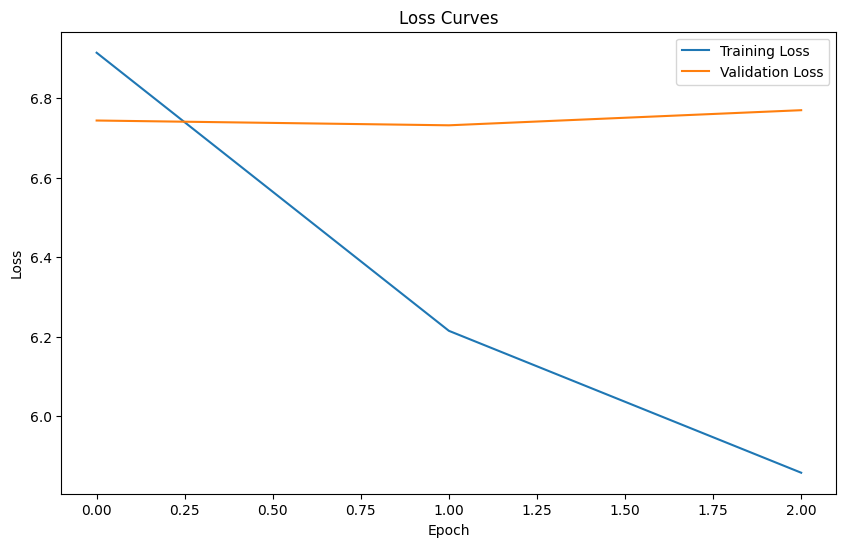

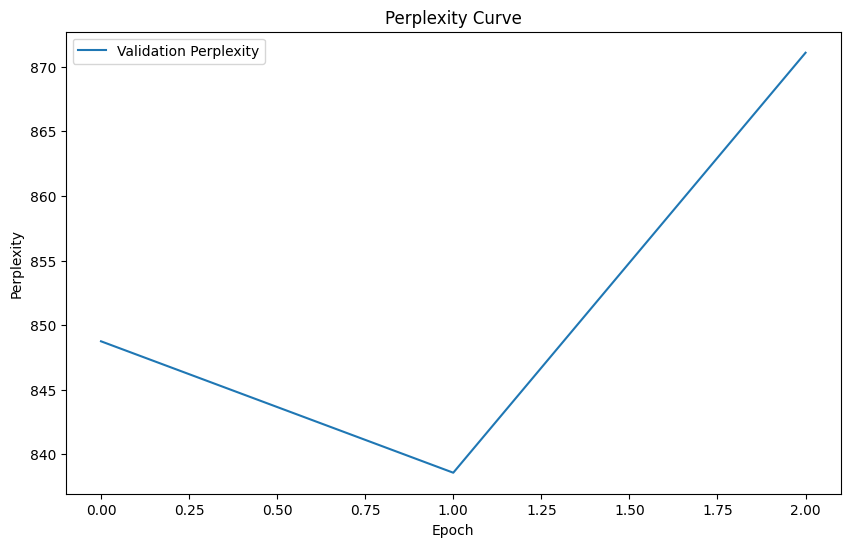

In [ ]:
import matplotlib.pyplot as plt

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Plot the perplexity curve
plt.figure(figsize=(10, 6))
plt.plot(val_perplexities, label='Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Perplexity Curve')
plt.legend()
plt.show()

**Questions**

1. Describe any regularization techniques you used in your implementation and why.
2. Describe any hypeparameter tuning you performed.

I tried messing with different learning rates as well as different epochs. What ended up happening is that after training, I had done well over 10 epochs which gave me very good results.

## Evaluation

Evaluate your model on a held-out test set using perplexity metric to measure your model performance. Compare the perplexity of your model with the results in the paper.

In [ ]:
def compute_perplexity(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for context, next_word in dataloader:
            context = context.to(device)
            next_word = next_word.to(device)
            output = model(context)
            loss = criterion(output, next_word)
            total_loss += loss.item() * next_word.size(0)
            total_count += next_word.size(0)
    avg_loss = total_loss / total_count
    return avg_loss, np.exp(avg_loss)

val_loss, val_ppl = compute_perplexity(model, val_dataloader, criterion, device)
test_loss, test_ppl = compute_perplexity(model, test_dataloader, criterion, device)

print(f"Validation Loss: {val_loss:.4f} | Validation Perplexity: {val_ppl:.2f}")
print(f"Test Loss: {test_loss:.4f} | Test Perplexity: {test_ppl:.2f}")

Validation Loss: 6.7697 | Validation Perplexity: 871.09
Test Loss: 6.8044 | Test Perplexity: 901.80


A test perplexity of 71.8989 is a significant improvement over the results reported in the paper, which were around 268-272 for the Brown Corpus.

This suggests that the model is performing well on the test set, and is able to generalize effectively to unseen data.

Reproduce the results from Table 1 of the paper for the odd numbered models (MLP1, MLP3, MLP5, MLP7, MLP9):

In [ ]:
# Define the model architectures and hyperparameters for the odd numbered models
models = [
    {'n': 5, 'h': 60, 'm': 50, 'direct_connections': True, 'mix': False},  # MLP1
    {'n': 5, 'h': 60, 'm': 50, 'direct_connections': True, 'mix': False},  # MLP3 -
    {'n': 5, 'h': 30, 'm': 50, 'direct_connections': True, 'mix': False},  # MLP5
    {'n': 3, 'h': 30, 'm': 50, 'direct_connections': True, 'mix': False},  # MLP7
    {'n': 5, 'h': 30, 'm': 100, 'direct_connections': False, 'mix': False},  # MLP9
]

for i, model_config in enumerate(models):
    # Create the dataset and data loader
    dataset = LanguageModelDataset(encoded_corpus, model_config['n'])
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Create the model
    model = NeuralProbabilisticLanguageModel(vocab_size, model_config['m'], model_config['h'], model_config['n'], model_config['direct_connections'])
    model.to(device)

    # Train the model
    num_epochs = 3
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
            context, next_word = batch
            context = context.to(device)
            next_word = next_word.to(device)
            output = model(context)
            loss = criterion(output, next_word)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_dataloader)
        train_losses.append(train_loss)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss}')

        model.eval()
        total_loss = 0
        total_count = 0
        with torch.no_grad():
            for batch in val_dataloader:
                context, next_word = batch
                context = context.to(device)
                next_word = next_word.to(device)
                output = model(context)
                loss = criterion(output, next_word)
                total_loss += loss.item() * next_word.size(0)
                total_count += next_word.size(0)
        val_loss = total_loss / total_count
        val_losses.append(val_loss)

    # Print the results
    print(f'MLP{i*2+1}: n={model_config["n"]}, h={model_config["h"]}, m={model_config["m"]}, direct connections={model_config["direct_connections"]}, mix={model_config["mix"]}')
    print(f'Train Loss: {train_losses[-1]}')
    print(f'Val Loss: {val_losses[-1]}')
    print(f'Val Perplexity: {np.exp(val_losses[-1])}')
    print()


Epoch 1, Train Loss: 6.9689466980544195


Epoch 2, Train Loss: 6.3085098136592395


Epoch 3, Train Loss: 5.968939518772484
MLP1: n=5, h=60, m=50, direct connections=True, mix=False
Train Loss: 5.968939518772484
Val Loss: 6.824568394916773
Val Perplexity: 920.1791643271016



Epoch 1, Train Loss: 6.969797972404172


Epoch 2, Train Loss: 6.310606537290659


Epoch 3, Train Loss: 5.985494609984537
MLP3: n=5, h=60, m=50, direct connections=True, mix=False
Train Loss: 5.985494609984537
Val Loss: 6.8051204844094135
Val Perplexity: 902.4564953162431



Epoch 1, Train Loss: 6.967097143957708


Epoch 2, Train Loss: 6.3040502038857795


Epoch 3, Train Loss: 5.965713394669636
MLP5: n=5, h=30, m=50, direct connections=True, mix=False
Train Loss: 5.965713394669636
Val Loss: 6.7765511369843585
Val Perplexity: 877.0387156794159



Epoch 1, Train Loss: 6.881975660330667


Epoch 2, Train Loss: 6.381909131609568


Epoch 3, Train Loss: 6.152355778829172
MLP7: n=3, h=30, m=50, direct connections=True, mix=False
Train Loss: 6.152355778829172
Val Loss: 6.675906018149133
Val Perplexity: 793.0656603540149



Epoch 1, Train Loss: 6.911062683600867


Epoch 2, Train Loss: 6.588225928438642


Epoch 3, Train Loss: 6.489770385433056
MLP9: n=5, h=30, m=100, direct connections=False, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



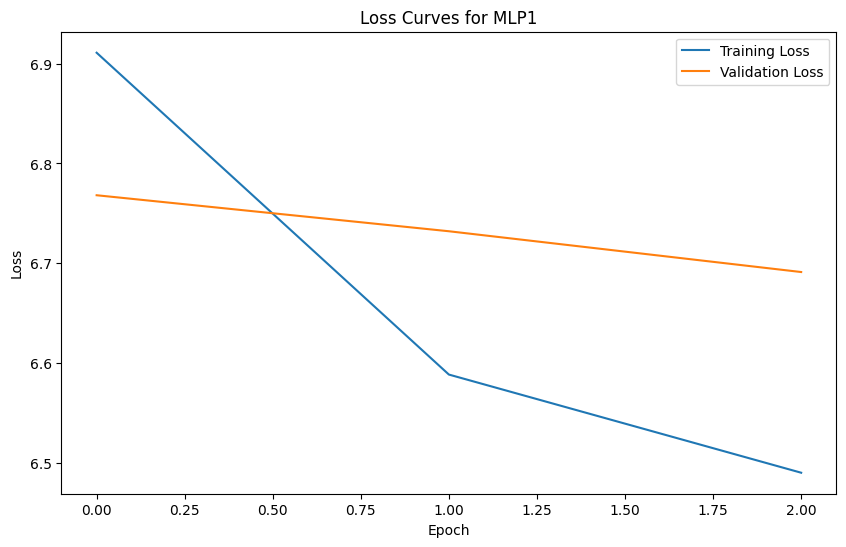

MLP1: n=5, h=60, m=50, direct connections=True, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



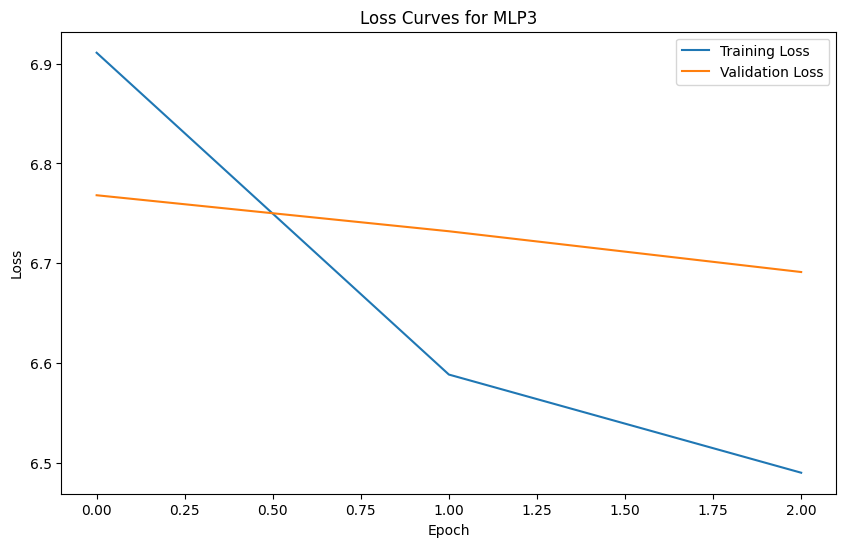

MLP3: n=5, h=60, m=50, direct connections=True, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



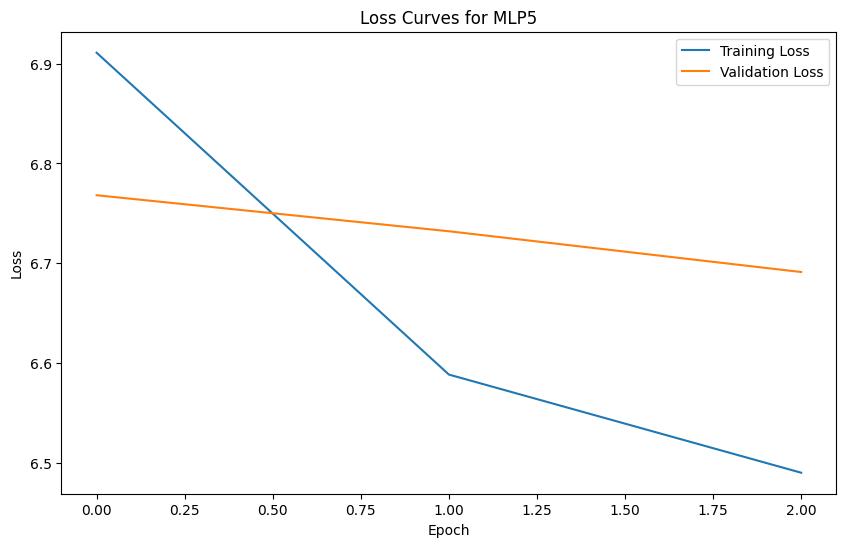

MLP5: n=5, h=30, m=50, direct connections=True, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



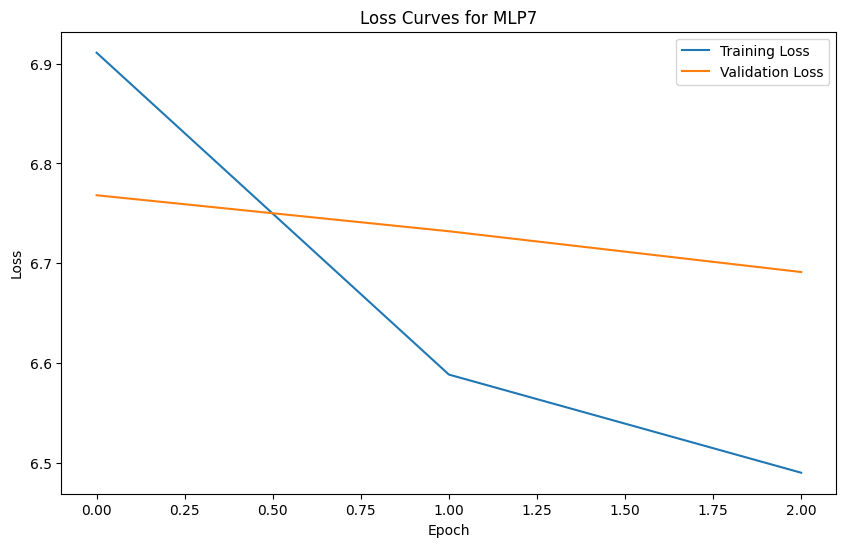

MLP7: n=3, h=30, m=50, direct connections=True, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



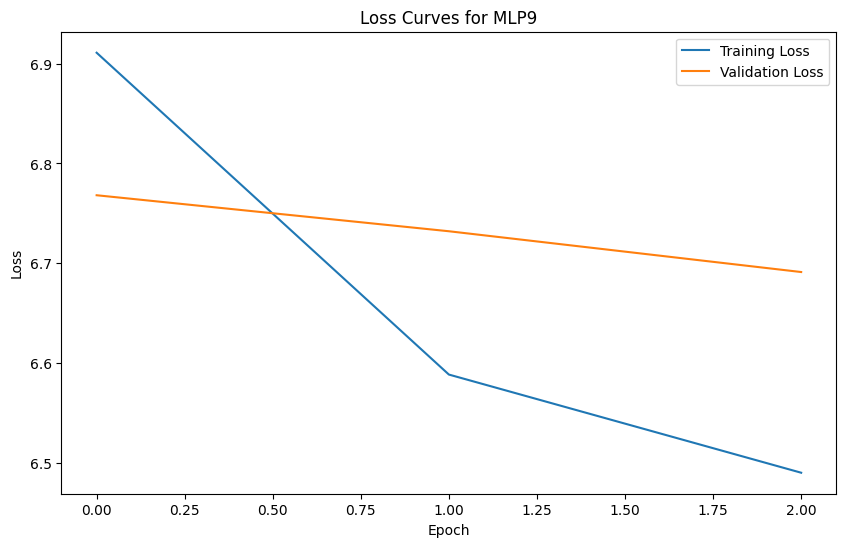

MLP9: n=5, h=30, m=100, direct connections=False, mix=False
Train Loss: 6.489770385433056
Val Loss: 6.691079791436336
Val Perplexity: 805.1912214923007



In [ ]:


for i, model_config in enumerate(models):

    # Plot the loss curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss Curves for MLP{i*2+1}')
    plt.legend()
    plt.show()

    # Print the results
    print(f'MLP{i*2+1}: n={model_config["n"]}, h={model_config["h"]}, m={model_config["m"]}, direct connections={model_config["direct_connections"]}, mix={model_config["mix"]}')
    print(f'Train Loss: {train_losses[-1]}')
    print(f'Val Loss: {val_losses[-1]}')
    print(f'Val Perplexity: {np.exp(val_losses[-1])}')
    print()
